# Load Library

In [ ]:
# !pip install xgboost
# !pip install lightgbm
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


In [ ]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import re

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set style untuk visualisasi agar rapi saat dimasukkan ke PPT
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

# 1. Persiapan dan Penentuan Objek Data

- Identifikasi Tujuan: Tujuan utama analisis adalah menurunkan insiden LTI (Lost Time Injury) melalui pemodelan prediksi yang dibangun dari data historis kecelakaan kerja.

- Sumber Data: Data yang digunakan berasal dari file Dataset_SHE_PTBananaCoal pada sheet Log_Insiden_SHE, yang memiliki dimensi 2.699 baris dan 26 kolom.

- Identifikasi Variabel: Memetakan variabel-variabel yang relevan dan memiliki potensi untuk memprediksi kejadian LTI.

- Kamus Data (Data Dictionary): Dokumentasi wajib yang berisi rincian nama kolom, tipe data, rentang nilai yang diizinkan, serta makna dari setiap variabel operasional.

- Definisi Unit Analisis: Menetapkan bahwa satu baris data merepresentasikan satu kejadian insiden yang terjadi dalam periode Januari 2022 hingga Desember 2024.

In [ ]:
# Modul 1: Load Dataset
# Ubah nama file sesuai dengan nama file Excel yang kamu upload
file_path = '/content/Dataset_SHE_PTBananaCoal (mini Project).xlsx'
df = pd.read_excel(file_path, sheet_name='Log_Insiden_SHE')

print("Dimensi Data Awal:", df.shape)
display(df)

Dimensi Data Awal: (2699, 26)


,No,Tanggal,Hari,Bulan,Kuartal,Tahun,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,...,Hari_Hilang_Kerja,Property_Damage,Jumlah_Tenaga_Kerja,Jam_Kerja,Kondisi_Cuaca,Penyebab_Utama,Tindakan_Korektif,Status_Tindakan,Lokasi_Spesifik,Catatan
0,1,2023-06-26,Monday,6,Q2,2023,Shift 1 (07:00-19:00),Drainase,SPV-009,Grading,...,0,0,29,298.2,Cerah,Komunikasi Buruk,Revisi Prosedur,Belum Dimulai,Draina-Blok02,NaN
1,2,2023-05-10,Wednesday,5,Q2,2023,Shift 2 (19:00-07:00),Drainase,SPV-010,Dozing,...,0,0,10,105.4,Cerah,Alat Pelindung Diri Tidak Sesuai,Pelatihan Ulang,Dalam Proses,Draina-Blok05,NaN
2,3,2023-03-27,Monday,3,Q1,2023,Shift 2 (19:00-07:00),ROM (Run of Mine),SPV-011,Administrasi,...,0,0,35,393.7,Cerah,Desain/Engineering,Investigasi Lanjut,Selesai,ROM (R-Blok02,NaN
3,4,2022-11-29,Tuesday,11,Q4,2022,Shift 2 (19:00-07:00),Pit-C (Hauling),SPV-020,Loading,...,0,0,22,258.0,Cerah,Human Error,Revisi Prosedur,Selesai,Pit-C-Blok02,NaN
4,5,2023-05-13,Saturday,5,Q2,2023,Shift 2 (19:00-07:00),Pit-B (Coal Getting),SPV-018,Survei,...,0,0,40,459.6,Berkabut,Komunikasi Buruk,Investigasi Lanjut,Selesai,Pit-B-Blok04,Menunggu spare part
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2694,2695,2023-10-30,Monday,10,Q4,2023,Shift 1 (07:00-19:00),Pit-A (Overburden),SPV-005,Survei,...,0,0,10,103.5,Hujan Ringan,Alat Pelindung Diri Tidak Sesuai,Briefing Safety,Dalam Proses,Pit-A-Blok04,Menunggu spare part
2695,2696,2023-03-21,Tuesday,3,Q1,2023,Shift 1 (07:00-19:00),Pit-A (Overburden),SPV-008,Pumping,...,0,0,43,432.1,Cerah,Prosedur Tidak Diikuti,Penggantian APD,Dalam Proses,Pit-A-Blok05,NaN
2696,2697,2023-04-04,Tuesday,4,Q2,2023,Shift 1 (07:00-19:00),Pit-B (Coal Getting),SPV-004,Pumping,...,0,0,27,324.5,Hujan Ringan,Desain/Engineering,Investigasi Lanjut,Belum Dimulai,Pit-B-Blok01,NaN
2697,2698,2023-06-04,Sunday,6,Q2,2023,Shift 1 (07:00-19:00),Workshop,SPV-001,Pengawasan,...,0,0,26,257.1,Hujan Ringan,Human Error,Pelatihan Ulang,Selesai,Worksh-Blok03,Sudah dilaporkan ke HSE Manager


# 2. Telaah Data (Exploratory Data Analysis)

- Statistik Deskriptif: Menghitung ukuran pemusatan dan penyebaran untuk variabel numerik, yaitu Jam_Kerja, Jumlah_Tenaga_Kerja, dan Hari_Hilang_Kerja.

- Distribusi Kategorik: Menganalisis frekuensi dari variabel non-numerik seperti Shift, Area_Kerja, Jenis_Insiden, dan Penyebab_Utama.

- Visualisasi Data: Membuat grafik untuk melihat tren insiden per tahun dan kuartal, komposisi insiden di tiap area kerja, heatmap sebaran insiden per hari atau shift, serta grafik distribusi penyebab utamanya.

- Kalkulasi Kinerja SHE: Menghitung indikator performa keselamatan (TRIR, LTIR, dan Severity Rate) dengan mengelompokkannya per tahun atau per area.

- Deteksi Pola/Anomali: Mengidentifikasi kombinasi spesifik (misalnya area, shift, atau supervisor tertentu) yang memiliki frekuensi insiden yang sangat tinggi.

In [ ]:
# Modul 2: Exploratory Data Analysis (EDA)

# 1. Statistik Deskriptif
print("\n--- Statistik Deskriptif ---")
display(df[['Jam_Kerja', 'Jumlah_Tenaga_Kerja', 'Hari_Hilang_Kerja']].describe())


--- Statistik Deskriptif ---


,Jam_Kerja,Jumlah_Tenaga_Kerja,Hari_Hilang_Kerja
count,2699.000000,2699.00000,2699.000000
mean,321.351167,26.70063,0.592812
std,310.579721,11.04204,2.350142
min,-100.000000,0.00000,0.000000
25%,192.500000,17.00000,0.000000
50%,307.100000,27.00000,0.000000
75%,413.800000,36.00000,0.000000
max,9999.000000,45.00000,14.000000


In [ ]:
# ==========================================
# INSPEKSI DATA TANGGAL YANG RUSAK
# ==========================================

# 1. Kita buat copy data mentah dulu untuk perbandingan
df_raw = pd.read_excel('/content/Dataset_SHE_PTBananaCoal (mini Project).xlsx', sheet_name='Log_Insiden_SHE')

# 2. Coba konversi ke datetime dengan errors='coerce'
tanggal_converted = pd.to_datetime(df_raw['Tanggal'], format='mixed', errors='coerce')

# 3. Filter baris di mana hasil konversinya adalah NaT (gagal terdeteksi formatnya)
baris_error = df_raw[tanggal_converted.isnull()]

print(f"Ditemukan {len(baris_error)} baris dengan format tanggal yang tidak lazim.")
print("Berikut adalah detail baris-baris tersebut:")

# Menampilkan kolom Tanggal asli beserta beberapa konteks insidennya
display(baris_error[['Tanggal', 'Area_Kerja', 'LTI', 'Penyebab_Utama', 'Catatan']])

Ditemukan 5 baris dengan format tanggal yang tidak lazim.
Berikut adalah detail baris-baris tersebut:


,Tanggal,Area_Kerja,LTI,Penyebab_Utama,Catatan
102,2024-13-01,Pit-A (Overburden),0,Desain/Engineering,Sudah dilaporkan ke HSE Manager
146,NaN,Pit-B (Coal Getting),0,Desain/Engineering,NaN
1488,32/01/2023,Pit-A (Overburden),0,Prosedur Tidak Diikuti,Investigasi selesai
2142,2024-13-01,Workshop,0,Desain/Engineering,Sudah dilaporkan ke HSE Manager
2586,NaN,Pit-A (Overburden),0,Desain/Engineering,Investigasi selesai


In [ ]:
# ==========================================
# PENANGANAN KHUSUS ANOMALI TANGGAL
# ==========================================

print("Dimensi data sebelum perbaikan tanggal:", df.shape)

# 1. Ubah sementara menjadi string agar bisa di-replace teksnya
df['Tanggal'] = df['Tanggal'].astype(str)

# 2. Lakukan perbaikan (replacement) manual pada teks yang salah
perbaikan_tanggal = {
    '2024-13-01': '2024-01-13', # Memperbaiki bulan dan tanggal yang tertukar
    '32/01/2023': '31/01/2023'  # Mengasumsikan typo 32 menjadi tanggal 31
}
df['Tanggal'] = df['Tanggal'].replace(perbaikan_tanggal)

# Kembalikan string 'nan' (akibat konversi astype) menjadi tipe NaN asli (numpy)
df['Tanggal'] = df['Tanggal'].replace('nan', np.nan)

# 3. Eksekusi konversi ke datetime (sekarang yang teksnya salah sudah aman)
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='mixed', errors='coerce')

# 4. Menangani NaN (Data Kosong)
# Karena log insiden biasanya dicatat berurutan secara kronologis,
# metode Forward Fill (ffill) sangat ideal untuk mengisi tanggal yang kosong
# dengan tanggal dari baris persis di atasnya.
df['Tanggal'] = df['Tanggal'].ffill()

# 5. Ekstrak Tahun dan Bulan untuk Visualisasi
df['Tahun'] = df['Tanggal'].dt.year
df['Bulan'] = df['Tanggal'].dt.month

print("\nPerbaikan Tanggal Berhasil!")
print("Jumlah missing value di kolom Tanggal sekarang:", df['Tanggal'].isnull().sum())
display(df[['Tanggal', 'Tahun', 'Bulan']].head(10))

Dimensi data sebelum perbaikan tanggal: (2699, 26)

Perbaikan Tanggal Berhasil!
Jumlah missing value di kolom Tanggal sekarang: 0


,Tanggal,Tahun,Bulan
0,2023-06-26,2023,6
1,2023-05-10,2023,5
2,2023-03-27,2023,3
3,2022-11-29,2022,11
4,2023-05-13,2023,5
5,2022-08-20,2022,8
6,2022-12-14,2022,12
7,2023-02-18,2023,2
8,2024-07-28,2024,7
9,2022-10-13,2022,10


Jumlah baris dengan format tanggal gagal dikonversi (NaT): 0


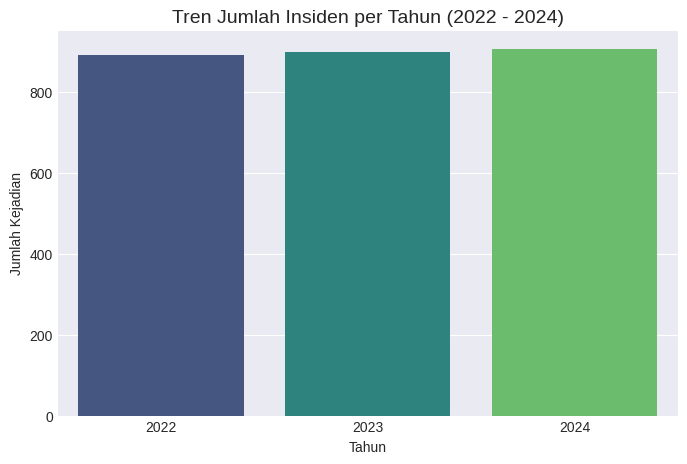

In [ ]:
# 2. Visualisasi Tren Insiden per Tahun (Untuk PPT)
# 2.1. Konversi dengan format='mixed' untuk menangani format tanggal yang tidak konsisten
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='mixed', errors='coerce')

# 2.2. Cek apakah ada data tanggal yang rusak parah dan berubah menjadi NaT (Not a Time)
jumlah_nat = df['Tanggal'].isnull().sum()
print(f"Jumlah baris dengan format tanggal gagal dikonversi (NaT): {jumlah_nat}")

# (Opsional) Jika ada NaT, kita bisa membuang baris tersebut (drop) atau mengisinya (imputasi).
# Karena tanggal insiden sangat krusial, biasanya baris yang rusak ini kita drop.
if jumlah_nat > 0:
    df = df.dropna(subset=['Tanggal'])
    print("Baris dengan tanggal rusak telah dihapus.")


# 2.3. Ekstrak Tahun (Kode yang sebelumnya error sekarang akan berhasil)
df['Tahun'] = df['Tanggal'].dt.year
df['Bulan'] = df['Tanggal'].dt.month

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Tahun', palette='viridis')
plt.title('Tren Jumlah Insiden per Tahun (2022 - 2024)', fontsize=14)
plt.ylabel('Jumlah Kejadian')
plt.show()

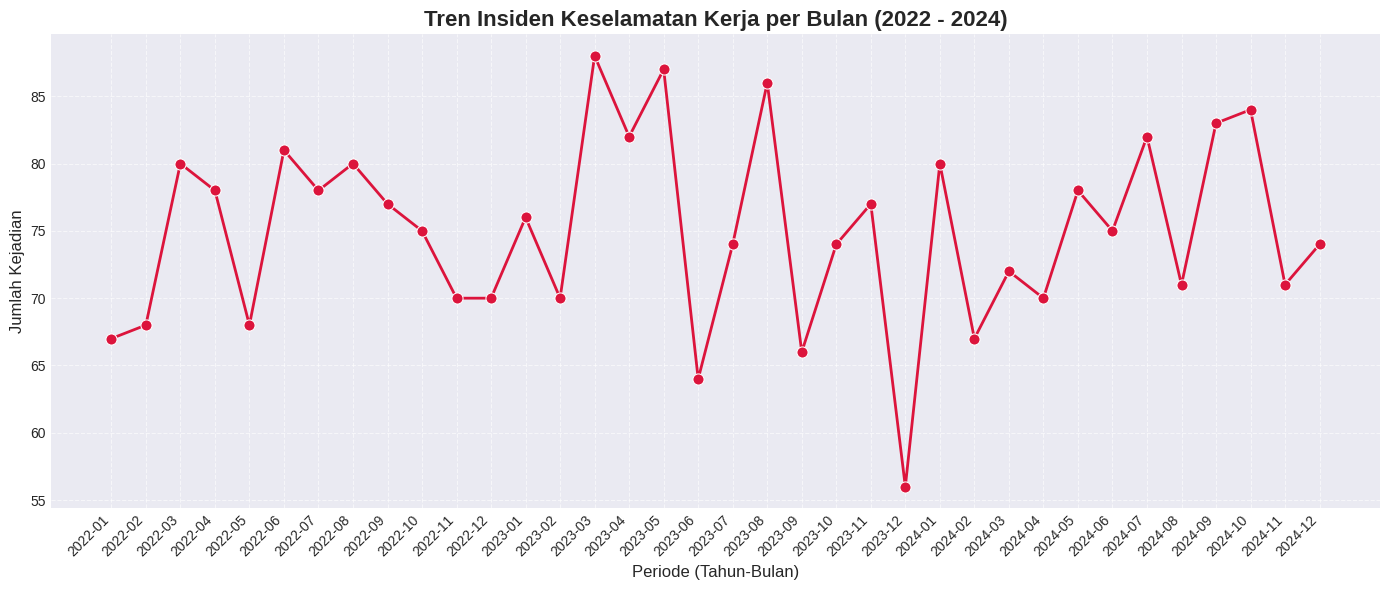

In [ ]:
# Membuat kolom khusus periode Tahun-Bulan (Contoh: '2022-01')
df['Periode_Bulan'] = df['Tanggal'].dt.to_period('M')

# Menghitung agregat jumlah insiden per bulan
tren_bulanan = df.groupby('Periode_Bulan').size().reset_index(name='Jumlah_Insiden')

# Mengubah tipe periode kembali ke string (teks) agar mudah di-plot di sumbu X
tren_bulanan['Periode_Bulan'] = tren_bulanan['Periode_Bulan'].astype(str)

# Visualisasi Tren Insiden (Menggunakan Line Chart)
plt.figure(figsize=(14, 6)) # Memanjangkan kanvas agar 36 bulan terlihat jelas
sns.lineplot(data=tren_bulanan, x='Periode_Bulan', y='Jumlah_Insiden',
             marker='o', color='crimson', linewidth=2, markersize=8)

plt.title('Tren Insiden Keselamatan Kerja per Bulan (2022 - 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Periode (Tahun-Bulan)', fontsize=12)
plt.ylabel('Jumlah Kejadian', fontsize=12)

# Memutar label sumbu X 45 derajat agar teks bulannya tidak saling bertumpuk
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6) # Menambahkan garis bantu (grid)
plt.tight_layout() # Memastikan layout rapi dan label tidak terpotong
plt.show()

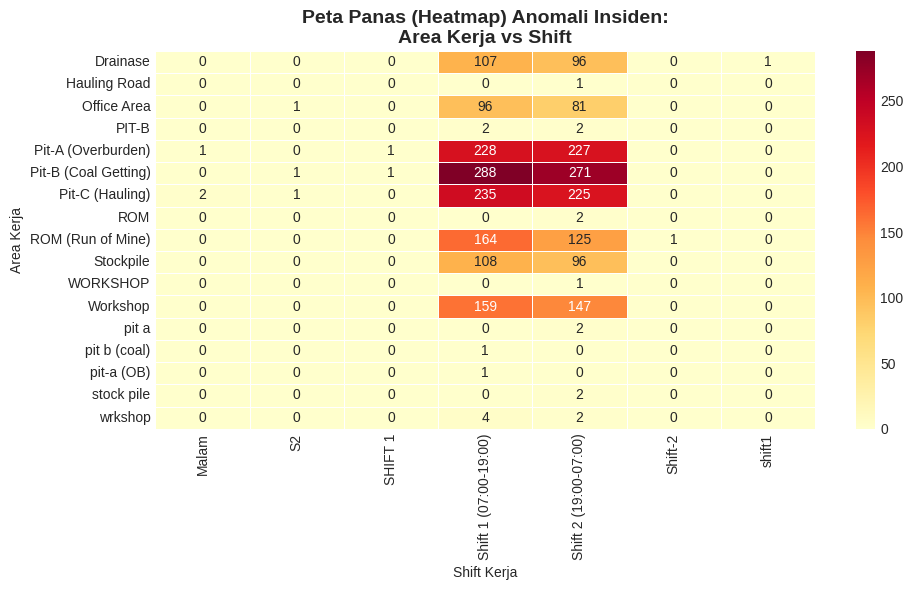

In [ ]:
# 1. Visualisasi Insiden Berdasarkan Shift & Area Kerja (Heatmap)
plt.figure(figsize=(10, 6))
shift_area = pd.crosstab(df['Area_Kerja'], df['Shift'])
sns.heatmap(shift_area, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Peta Panas (Heatmap) Anomali Insiden:\nArea Kerja vs Shift', fontsize=14, fontweight='bold')
plt.xlabel('Shift Kerja')
plt.ylabel('Area Kerja')
plt.tight_layout()
plt.show()

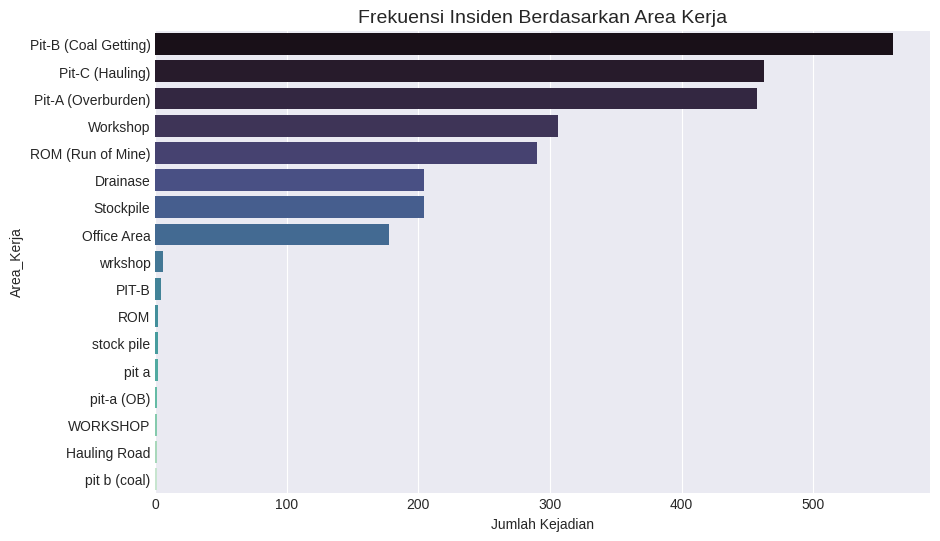

In [ ]:
# 3. Komposisi Insiden per Area Kerja (Untuk PPT)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Area_Kerja', order=df['Area_Kerja'].value_counts().index, palette='mako')
plt.title('Frekuensi Insiden Berdasarkan Area Kerja', fontsize=14)
plt.xlabel('Jumlah Kejadian')
plt.show()

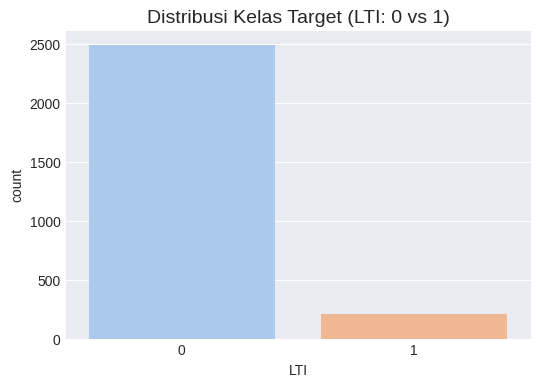

In [ ]:
# 4. Distribusi Kelas Target (Cek Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='LTI', palette='pastel')
plt.title('Distribusi Kelas Target (LTI: 0 vs 1)', fontsize=14)
plt.show()

,Tahun,TRIR,LTIR,Severity_Rate
0,2022,1590.48,218.78,1625.20
1,2023,1633.10,249.93,1958.35
2,2024,1608.19,261.07,1949.32


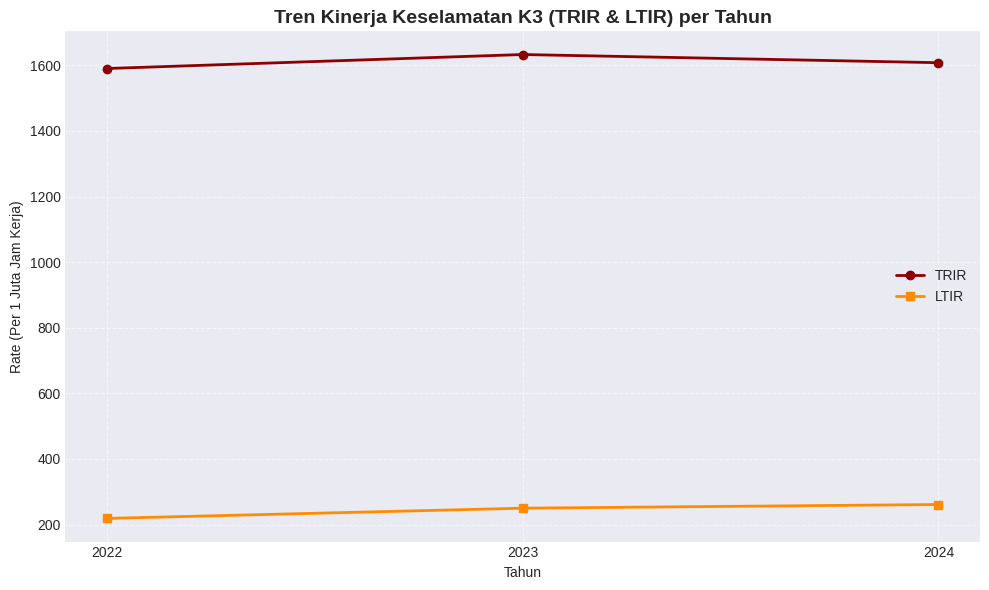

In [ ]:
# 2. Kalkulasi Metrik K3 secara Agregat per Tahun
# Asumsi: Kolom LTI, First_Aid, Medical_Treatment, Fatality sudah bernilai numerik (1/0)
# Jika Fatality tidak ada di data, kita asumsikan 0 untuk perhitungan
if 'Fatality' not in df.columns:
    df['Fatality'] = 0

# Kelompokkan data berdasarkan Tahun
kpi_tahunan = df.groupby('Tahun').agg(
    Total_Insiden = ('No', 'count'),
    Total_LTI = ('LTI', 'sum'),
    Total_Hari_Hilang = ('Hari_Hilang_Kerja', 'sum'),
    Total_Jam_Kerja = ('Jam_Kerja', 'sum'),
    Total_First_Aid = ('First_Aid', 'sum'),
    Total_Medical = ('Medical_Treatment', 'sum'),
    Total_Fatality = ('Fatality', 'sum')
).reset_index()

# Hitung Insiden Tercatat (Recordable Incidents)
kpi_tahunan['Insiden_Tercatat'] = (kpi_tahunan['Total_First_Aid'] +
                                   kpi_tahunan['Total_Medical'] +
                                   kpi_tahunan['Total_LTI'] +
                                   kpi_tahunan['Total_Fatality'])

# Rumus Kalkulasi Rate (per 1.000.000 Jam Kerja)
faktor_pengali = 1_000_000

kpi_tahunan['TRIR'] = (kpi_tahunan['Insiden_Tercatat'] * faktor_pengali) / kpi_tahunan['Total_Jam_Kerja']
kpi_tahunan['LTIR'] = (kpi_tahunan['Total_LTI'] * faktor_pengali) / kpi_tahunan['Total_Jam_Kerja']
kpi_tahunan['Severity_Rate'] = (kpi_tahunan['Total_Hari_Hilang'] * faktor_pengali) / kpi_tahunan['Total_Jam_Kerja']

# Membulatkan hasil ke 2 angka di belakang koma
kpi_tahunan = kpi_tahunan.round(2)

display(kpi_tahunan[['Tahun', 'TRIR', 'LTIR', 'Severity_Rate']])

# 3. Visualisasi Tren Metrik K3
plt.figure(figsize=(10, 6))
plt.plot(kpi_tahunan['Tahun'].astype(str), kpi_tahunan['TRIR'], marker='o', label='TRIR', linewidth=2, color='darkred')
plt.plot(kpi_tahunan['Tahun'].astype(str), kpi_tahunan['LTIR'], marker='s', label='LTIR', linewidth=2, color='darkorange')
plt.title('Tren Kinerja Keselamatan K3 (TRIR & LTIR) per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Rate (Per 1 Juta Jam Kerja)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== ANALISIS DISTRIBUSI JUMLAH TENAGA KERJA ===


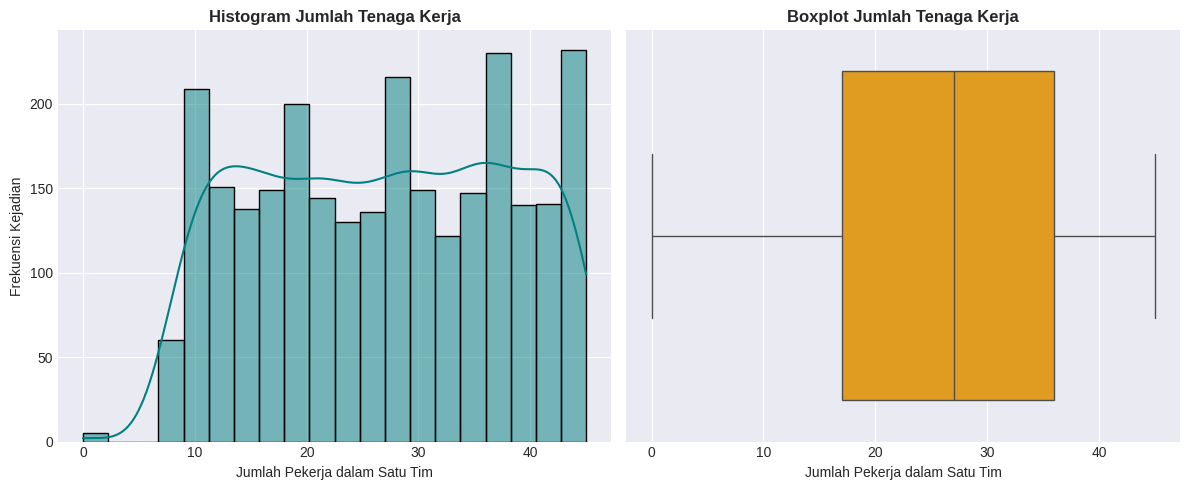

,count,mean,std,min,25%,50%,75%,max
Jumlah_Tenaga_Kerja,2699.0,26.70063,11.04204,0.0,17.0,27.0,36.0,45.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== ANALISIS DISTRIBUSI JUMLAH TENAGA KERJA ===")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafik 1: Histogram (Melihat bentuk distribusi)
sns.histplot(df['Jumlah_Tenaga_Kerja'], bins=20, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Histogram Jumlah Tenaga Kerja', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Pekerja dalam Satu Tim')
axes[0].set_ylabel('Frekuensi Kejadian')

# Grafik 2: Boxplot (Mendeksi Outlier / Nilai Ekstrem)
sns.boxplot(x=df['Jumlah_Tenaga_Kerja'], color='Orange', ax=axes[1])
axes[1].set_title('Boxplot Jumlah Tenaga Kerja', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Pekerja dalam Satu Tim')

plt.tight_layout()
plt.show()

# Menampilkan ringkasan statistik deskriptif
display(df['Jumlah_Tenaga_Kerja'].describe().to_frame().T)

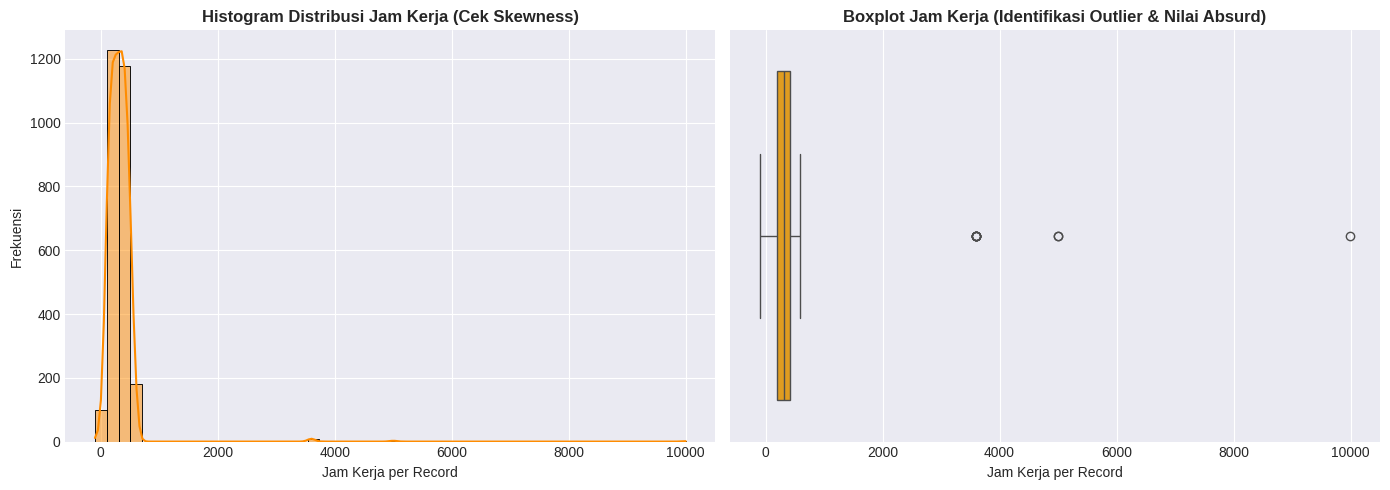

=== RINGKASAN DETEKSI ANOMALI JAM KERJA ===
Nilai Minimum Terdeteksi : -100.0 (Anomali jika Negatif!)
Nilai Maksimum Terdeteksi : 9999.0 (Anomali jika Tidak Rasional/9999!)


In [ ]:
# 4. Inspeksi Distribusi & Anomali Jam Kerja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik A: Histogram untuk melihat bentuk distribusi dan nilai ekstrem jarak jauh
sns.histplot(df['Jam_Kerja'], bins=50, kde=True, color='darkorange', ax=axes[0])
axes[0].set_title('Histogram Distribusi Jam Kerja (Cek Skewness)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jam Kerja per Record')
axes[0].set_ylabel('Frekuensi')

# Grafik B: Boxplot untuk mendeteksi outlier/anomali secara matematis
sns.boxplot(x=df['Jam_Kerja'], color='orange', ax=axes[1])
axes[1].set_title('Boxplot Jam Kerja (Identifikasi Outlier & Nilai Absurd)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jam Kerja per Record')

plt.tight_layout()
plt.show()

# Mengeluarkan angka statistik deskriptif untuk memperkuat bukti anomali teks
print("=== RINGKASAN DETEKSI ANOMALI JAM KERJA ===")
print(f"Nilai Minimum Terdeteksi : {df['Jam_Kerja'].min()} (Anomali jika Negatif!)")
print(f"Nilai Maksimum Terdeteksi : {df['Jam_Kerja'].max()} (Anomali jika Tidak Rasional/9999!)")

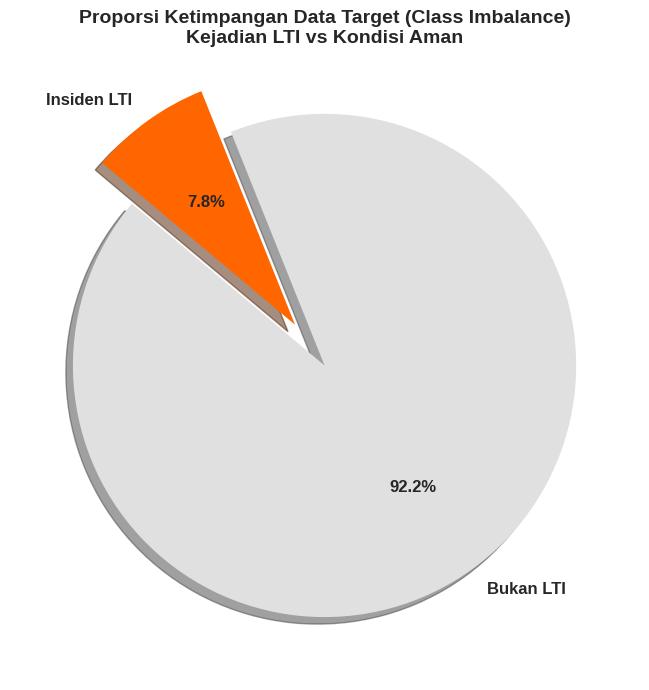

=== RINCIAN JUMLAH DATA ===
Hari Aman (0) : 2488 kejadian
Insiden LTI (1): 211 kejadian


In [ ]:
import matplotlib.pyplot as plt

# 1. Menghitung jumlah distribusi kelas LTI (0 vs 1)
lti_counts = df['LTI'].value_counts()

# 2. Pengaturan Estetika Visual (Tema Safety: Oranye & Abu-abu)
labels = ['Bukan LTI', 'Insiden LTI']
colors = ['#e0e0e0', '#ff6600']  # Abu-abu untuk Aman, Oranye Terang untuk LTI
explode = (0, 0.2)               # Menarik potongan 'LTI' keluar sebesar 0.2 agar mencolok

# 3. Membuat Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(lti_counts,
        labels=labels,
        autopct='%1.1f%%',       # Menampilkan persentase dengan 1 angka desimal
        startangle=140,          # Memutar posisi awal agar estetis
        colors=colors,
        explode=explode,         # Efek potongan ditarik
        shadow=True,             # Menambahkan bayangan 3D
        textprops={'fontsize': 12, 'fontweight': 'bold'}) # Mempertebal teks

plt.title('Proporsi Ketimpangan Data Target (Class Imbalance)\nKejadian LTI vs Kondisi Aman',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mencetak angka aslinya di bawah grafik
print("=== RINCIAN JUMLAH DATA ===")
print(f"Hari Aman (0) : {lti_counts[0]} kejadian")
print(f"Insiden LTI (1): {lti_counts[1]} kejadian")

# 3. Validasi Data

- Pemeriksaan Kelengkapan: Menghitung dan mendokumentasikan persentase data yang kosong (missing values) pada setiap kolom.

- Pemeriksaan Duplikasi: Mengecek apakah terdapat baris data kejadian yang tercatat lebih dari satu kali.

- Validasi Konsistensi Logis: Memeriksa kesesuaian logika pelaporan, contohnya jika LTI=1 maka nilai Hari_Hilang_Kerja harus lebih dari 0, dan jika Fatality=1 maka LTI wajib bernilai 1.

- Evaluasi Kecukupan Data: Menilai apakah jumlah sampel yang ada sudah cukup merepresentasikan kondisi aktual untuk membangun model klasifikasi LTI.

- Rekomendasi Validasi: Menyusun daftar variabel yang bermasalah beserta usulan strategi penanganannya.

In [ ]:
# Modul 3 & 4: Data Validation & Cleaning

# 1. Cek Missing Values
print("\nMissing Values sebelum cleaning:\n", df.isnull().sum())

# Mengisi missing values pada kolom opsional 'Catatan'
df['Catatan'] = df['Catatan'].fillna('Tidak ada catatan')


Missing Values sebelum cleaning:
 No                        0
Tanggal                   0
Hari                      0
Bulan                     0
Kuartal                   0
Tahun                     0
Shift                     0
Area_Kerja               16
Supervisor_ID            11
Jenis_Pekerjaan           7
Jenis_Insiden             1
Near_Miss                 0
First_Aid                 0
Medical_Treatment         0
LTI                       0
Fatality                  0
Hari_Hilang_Kerja         0
Property_Damage           0
Jumlah_Tenaga_Kerja       0
Jam_Kerja                 0
Kondisi_Cuaca            11
Penyebab_Utama            8
Tindakan_Korektif         0
Status_Tindakan           0
Lokasi_Spesifik           0
Catatan                1335
Periode_Bulan             0
dtype: int64


# 4. Pembersihan Data

- Standarisasi Kategori Shift: Menyatukan variasi penulisan yang bermakna sama (contoh: "S2", "Shift-2", "Malam" diubah secara seragam menjadi "Shift 2", serta "SHIFT 1", "shift1" menjadi "Shift 1").

- Standarisasi Area Kerja: Memperbaiki salah ketik pada area, seperti mengubah "wrkshop" menjadi "Workshop", "pit a" menjadi "Pit-A", dan "stock pile" menjadi "Stockpile".

- Penanganan Outlier: Mengatasi nilai ekstrem pada Jam_Kerja, seperti menghapus atau mengimputasi nilai negatif (misal -100) dan nilai yang tidak wajar (misal 9999) dengan strategi yang tepat.

- Penanganan Missing Values: Menyelesaikan kekosongan data, khususnya pada kolom Catatan yang bersifat opsional.

- Koreksi Tipe Data: Memastikan kolom Tanggal terbaca sebagai format datetime, serta mengubah variabel biner (seperti 0/1) menjadi tipe integer.

In [ ]:
# ==========================================
# PENANGANAN MISSING VALUES
# ==========================================

# Menangani NaN tanggal dengan metode Forward Fill
df['Tanggal'] = df['Tanggal'].ffill()

# Penanganan kolom 'Catatan' (Sesuai instruksi: opsional)
df['Catatan'] = df['Catatan'].fillna('Tidak ada catatan')

# Penanganan 'Supervisor_ID' (ID tidak boleh diisi dengan Modus)
df['Supervisor_ID'] = df['Supervisor_ID'].fillna('Tidak Diketahui')

# 2. Penanganan 'Kondisi_Cuaca' (Menggunakan Time-Series Logics / ffill)
# Karena cuaca adalah fenomena berkelanjutan dalam satu rentang waktu
jumlah_kosong_cuaca = df['Kondisi_Cuaca'].isnull().sum()
df['Kondisi_Cuaca'] = df['Kondisi_Cuaca'].ffill().bfill()
print(f"Kolom 'Kondisi_Cuaca' (Kosong: {jumlah_kosong_cuaca}) diisi dengan pendekatan Forward Fill.")

# Penanganan Kolom Kategorikal (Menggunakan Probabilitas Distribusi)
kolom_kategorikal = [
    'Area_Kerja',
    'Jenis_Pekerjaan',
    'Jenis_Insiden',
    'Penyebab_Utama'
]

# Set seed agar hasil randomisasi probabilitas tetap konsisten saat di-run ulang
np.random.seed(42)

for kolom in kolom_kategorikal:
    jumlah_kosong = df[kolom].isnull().sum()

    if jumlah_kosong > 0:
        # Menghitung bobot probabilitas tiap kelas di kolom tersebut
        probabilitas = df[kolom].value_counts(normalize=True)

        # Mengisi nilai kosong berdasarkan undian dengan probabilitas aslinya
        nilai_pengganti = np.random.choice(
            probabilitas.index,
            size=jumlah_kosong,
            p=probabilitas.values
        )

        # Menerapkan nilai pengganti ke baris yang NaN
        df.loc[df[kolom].isnull(), kolom] = nilai_pengganti

        print(f"Kolom '{kolom}' (Kosong: {jumlah_kosong}) diisi menggunakan Probabilitas Distribusi Kelas.")

# Cek kembali untuk memastikan semua sudah bersih
print("\nJumlah Missing Values setelah cleaning:")
display(df.isnull().sum())

Kolom 'Kondisi_Cuaca' (Kosong: 11) diisi dengan pendekatan Forward Fill.
Kolom 'Area_Kerja' (Kosong: 16) diisi menggunakan Probabilitas Distribusi Kelas.
Kolom 'Jenis_Pekerjaan' (Kosong: 7) diisi menggunakan Probabilitas Distribusi Kelas.
Kolom 'Jenis_Insiden' (Kosong: 1) diisi menggunakan Probabilitas Distribusi Kelas.
Kolom 'Penyebab_Utama' (Kosong: 8) diisi menggunakan Probabilitas Distribusi Kelas.

Jumlah Missing Values setelah cleaning:


,0
No,0
Tanggal,0
Hari,0
Bulan,0
Kuartal,0
Tahun,0
Shift,0
Area_Kerja,0
Supervisor_ID,0
Jenis_Pekerjaan,0


In [ ]:
print("=== Membersihkan Kolom Shift (Penanganan Anomali) ===")

# 1. Ambil data aslinya dan ubah ke huruf kecil semua sebagai 'kertas buram' pencarian
shift_mentah = df['Shift'].astype(str).str.lower()

# 2. Sapu bersih menggunakan Regex (Pencarian Pola Teks)
# JIKA mengandung angka '1' ATAU kata 'pagi' ATAU kata 'siang' -> Jadikan 'Shift_1'
df.loc[shift_mentah.str.contains('1|pagi|siang', na=False, regex=True), 'Shift'] = 'Shift_1'

# JIKA mengandung angka '2' ATAU kata 'malam' -> Jadikan 'Shift_2'
df.loc[shift_mentah.str.contains('2|malam', na=False, regex=True), 'Shift'] = 'Shift_2'

# 3. Verifikasi hasil akhir
print("Distribusi Shift setelah dibersihkan:")
print(df['Shift'].value_counts(dropna=False))

=== Membersihkan Kolom Shift (Penanganan Anomali) ===
Distribusi Shift setelah dibersihkan:
Shift
Shift_1    1405
Shift_2    1294
Name: count, dtype: int64


In [ ]:
print("=== Merapikan Variasi Teks Area Kerja ===")

# 1. Ubah ke huruf kecil semua dulu agar deteksi kata kunci lebih mudah
df['Area_Kerja'] = df['Area_Kerja'].astype(str).str.lower().str.strip()

# 2. Buat fungsi pembersih berbasis kata kunci
def bersihkan_area(teks):
    if 'pit a' in teks or 'pit-a' in teks:
        return 'Pit-A'
    elif 'pit b' in teks or 'pit-b' in teks:
        return 'Pit-B'
    elif 'pit c' in teks or 'pit-c' in teks:
        return 'Pit-C'
    elif 'workshop' in teks or 'wrkshop' in teks:
        return 'Workshop'
    elif 'stock' in teks or 'stok' in teks:
        return 'Stockpile'
    else:
        # Jika ada nama area lain, rapikan formatnya (Huruf Kapital di awal kata)
        return teks.title()

# 3. Terapkan fungsi ke dalam kolom Area_Kerja
df['Area_Kerja'] = df['Area_Kerja'].apply(bersihkan_area)

# Verifikasi hasil pembersihan
print("Variasi Area Kerja setelah dibersihkan secara otomatis:")
display(df['Area_Kerja'].value_counts())

=== Merapikan Variasi Teks Area Kerja ===
Variasi Area Kerja setelah dibersihkan secara otomatis:


,count
Area_Kerja,
Pit-B,572
Pit-C,465
Pit-A,460
Workshop,315
Rom (Run Of Mine),292
Stockpile,207
Drainase,205
Office Area,180
Rom,2


In [ ]:
# 3. Handling Outlier (Jam_Kerja negatif atau nilai absurd 9999)
# Kita ganti nilai < 0 dan nilai > 1000 (asumsi jam kerja/shift tidak rasional jika > 1000) dengan nilai Median
median_jam = df.loc[(df['Jam_Kerja'] >= 0) & (df['Jam_Kerja'] <= 1000), 'Jam_Kerja'].median()
df['Jam_Kerja'] = np.where((df['Jam_Kerja'] < 0) | (df['Jam_Kerja'] > 1000), median_jam, df['Jam_Kerja'])

# 4. Validasi Konsistensi Logis
# Jika LTI = 1, Hari Hilang Kerja harus > 0. Jika 0, kita imputasi median hari hilang LTI
median_hari_hilang = df.loc[df['LTI'] == 1, 'Hari_Hilang_Kerja'].median()
df.loc[(df['LTI'] == 1) & (df['Hari_Hilang_Kerja'] == 0), 'Hari_Hilang_Kerja'] = median_hari_hilang

print("\nCleaning Selesai. Dimensi Data:", df.shape)


Cleaning Selesai. Dimensi Data: (2699, 27)


In [ ]:
df.head()

,No,Tanggal,Hari,Bulan,Kuartal,Tahun,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,...,Property_Damage,Jumlah_Tenaga_Kerja,Jam_Kerja,Kondisi_Cuaca,Penyebab_Utama,Tindakan_Korektif,Status_Tindakan,Lokasi_Spesifik,Catatan,Periode_Bulan
0,1,2023-06-26,Monday,6,Q2,2023,Shift_1,Drainase,SPV-009,Grading,...,0,29,298.2,Cerah,Komunikasi Buruk,Revisi Prosedur,Belum Dimulai,Draina-Blok02,Tidak ada catatan,2023-06
1,2,2023-05-10,Wednesday,5,Q2,2023,Shift_2,Drainase,SPV-010,Dozing,...,0,10,105.4,Cerah,Alat Pelindung Diri Tidak Sesuai,Pelatihan Ulang,Dalam Proses,Draina-Blok05,Tidak ada catatan,2023-05
2,3,2023-03-27,Monday,3,Q1,2023,Shift_2,Rom (Run Of Mine),SPV-011,Administrasi,...,0,35,393.7,Cerah,Desain/Engineering,Investigasi Lanjut,Selesai,ROM (R-Blok02,Tidak ada catatan,2023-03
3,4,2022-11-29,Tuesday,11,Q4,2022,Shift_2,Pit-C,SPV-020,Loading,...,0,22,258.0,Cerah,Human Error,Revisi Prosedur,Selesai,Pit-C-Blok02,Tidak ada catatan,2022-11
4,5,2023-05-13,Saturday,5,Q2,2023,Shift_2,Pit-B,SPV-018,Survei,...,0,40,459.6,Berkabut,Komunikasi Buruk,Investigasi Lanjut,Selesai,Pit-B-Blok04,Menunggu spare part,2023-05


# 5. Konstruksi Data (Feature Engineering)

Tahap menciptakan variabel baru (fitur) yang bisa memperkuat daya prediksi model machine learning.

- Indikator Turunan: Menghitung metrik khusus seperti TRIR, LTIR, dan Severity Rate berdasarkan formula yang telah disepakati.

- Ekstraksi Fitur Temporal: Mengekstrak informasi spesifik dari kolom Tanggal untuk menghasilkan variabel baru berupa Hari_dalam_Minggu, Bulan, dan Kuartal.

- Transformasi Data Kategorik (Encoding): Mengubah data teks menjadi angka menggunakan One-Hot Encoding atau Label Encoding untuk variabel Shift, Area_Kerja, Kondisi_Cuaca, Penyebab_Utama, dan Jenis_Pekerjaan.

- Normalisasi/Standarisasi: Menyesuaikan skala pada variabel numerik apabila algoritma klasifikasi yang akan digunakan membutuhkannya.

- Analisis Korelasi: Mengevaluasi hubungan antar fitur untuk menghindari masalah multikolinearitas di dalam model.

In [ ]:
# ==========================================
# Modul 5: Feature Engineering
# ==========================================
import pandas as pd
import numpy as np

# 1. Fitur Temporal
df['Bulan'] = df['Tanggal'].dt.month
df['Kuartal'] = df['Tanggal'].dt.quarter
df['Hari_dalam_Minggu'] = df['Tanggal'].dt.day_name()

# 2. Fitur Indikator SHE (Per Record)
# Karena rumusnya per 1.000.000 jam kerja, kita kalkulasi per record dengan asumsi variabel 'Jam_Kerja' per baris
df['Total_Insiden_Tercatat'] = df['First_Aid'] + df['Medical_Treatment'] + df['LTI'] + df['Fatality']

# Menghindari division by zero dengan np.where
df['TRIR'] = np.where(df['Jam_Kerja'] > 0, (df['Total_Insiden_Tercatat'] * 1000000) / df['Jam_Kerja'], 0)
df['LTIR'] = np.where(df['Jam_Kerja'] > 0, (df['LTI'] * 1000000) / df['Jam_Kerja'], 0)
df['Severity_Rate'] = np.where(df['Jam_Kerja'] > 0, (df['Hari_Hilang_Kerja'] * 1000000) / df['Jam_Kerja'], 0)

# 3. Fitur Beban Kerja Individu
# Semakin tinggi angkanya, semakin tinggi potensi kelelahan (fatigue)
df['Rasio_Beban_Kerja'] = df['Jam_Kerja'] / df['Jumlah_Tenaga_Kerja']

# Mengatasi kemungkinan nilai infinity jika Jumlah_Tenaga_Kerja = 0 (data kotor)
df['Rasio_Beban_Kerja'] = df['Rasio_Beban_Kerja'].replace([np.inf, -np.inf], 0)
# ==========================================

# 5. Fitur Interaksi Risiko Tinggi
# Membuat kombinasi teks antara Jenis Pekerjaan dan Cuaca sebelum di One-Hot Encoding
df['Risiko_Aktivitas_Cuaca'] = df['Jenis_Pekerjaan'] + "_" + df['Kondisi_Cuaca']


In [ ]:
# 6. Fitur Kategori Ukuran Tim
print("=== Feature Engineering: Rasio Kepadatan per Area ===")

# 1. Hitung rata-rata jumlah pekerja normal (baseline) untuk MASING-MASING Area Kerja
df['Rata2_Pekerja_Area'] = df.groupby('Area_Kerja')['Jumlah_Tenaga_Kerja'].transform('mean')

# 2. Buat Rasio Kepadatan (Jumlah pekerja saat insiden dibagi rata-rata normal areanya)
df['Rasio_Kepadatan_Area'] = df['Jumlah_Tenaga_Kerja'] / df['Rata2_Pekerja_Area']

# Mengatasi kemungkinan nilai NaN/Infinity jika ada area yang rata-ratanya 0
df['Rasio_Kepadatan_Area'] = df['Rasio_Kepadatan_Area'].replace([np.inf, -np.inf], 0).fillna(0)

# Mari kita intip hasilnya untuk melihat perbandingannya
display(df[['Area_Kerja', 'Jumlah_Tenaga_Kerja', 'Rata2_Pekerja_Area', 'Rasio_Kepadatan_Area']].head())

=== Feature Engineering: Rasio Kepadatan per Area ===


,Area_Kerja,Jumlah_Tenaga_Kerja,Rata2_Pekerja_Area,Rasio_Kepadatan_Area
0,Drainase,29,26.512195,1.093836
1,Drainase,10,26.512195,0.377185
2,Rom (Run Of Mine),35,26.568493,1.317350
3,Pit-C,22,26.537634,0.829011
4,Pit-B,40,26.610140,1.503186


In [ ]:
# Bulan 10 (Okt) sampai 4 (Apr) biasanya musim hujan di Indonesia
df['Musim_Hujan'] = df['Bulan'].apply(lambda x: 1 if x in [10, 11, 12, 1, 2, 3, 4] else 0)

# Asumsi: Jika teks 'Shift' mengandung angka '2', maka nilainya 1, selain itu 0
df['Is_Shift_Malam'] = df['Shift'].astype(str).str.contains('2').astype(int)

# Mengalikan beban kerja dengan shift malam untuk mendapatkan efek ganda
df['Indeks_Kelelahan_Malam'] = df['Rasio_Beban_Kerja'] * df['Is_Shift_Malam']

In [ ]:
# 1. Fitur Akhir Pekan (Sabtu & Minggu)
# Asumsi kolom Hari_dalam_Minggu menggunakan bahasa Inggris dari .dt.day_name()
df['Is_Weekend'] = df['Hari_dalam_Minggu'].isin(['Saturday', 'Sunday']).astype(int)

# 2. Fitur Kejar Target Produksi (Kuartal 4: Oktober - Desember)
df['Kejar_Target_Q4'] = (df['Kuartal'] == 4).astype(int)

In [ ]:
# ==========================================
# TAMBAHAN FEATURE ENGINEERING TINGKAT LANJUT
# ==========================================
print(">>> Mengekstrak Fitur Interaksi Lanjutan <<<")

# 1. Fitur Interaksi Non-Linear (Kelelahan Ekstrem)
# Mengalikan beban kerja dengan total jam kerja
df['Beban_x_JamKerja'] = df['Rasio_Beban_Kerja'] * df['Jam_Kerja']

# 2. Fitur Interaksi Kepadatan Spasial
# Mengalikan Rasio Kepadatan dengan Jumlah Tenaga Kerja
df['Kepadatan_x_TenagaKerja'] = df['Rasio_Kepadatan_Area'] * df['Jumlah_Tenaga_Kerja']

print("Fitur 'Beban_x_JamKerja' dan 'Kepadatan_x_TenagaKerja' berhasil ditambahkan ke dataset utama!")

>>> Mengekstrak Fitur Interaksi Lanjutan <<<
Fitur 'Beban_x_JamKerja' dan 'Kepadatan_x_TenagaKerja' berhasil ditambahkan ke dataset utama!


In [ ]:
# Export Data Bersih (Syarat Output Sertifikasi)
df.to_excel('Data_Bersih_PTBananaCoal.xlsx', index=False)
print("Data bersih berhasil disimpan sebagai 'Data_Bersih_PTBananaCoal.xlsx'")

Data bersih berhasil disimpan sebagai 'Data_Bersih_PTBananaCoal.xlsx'


In [ ]:
df.head()

,No,Tanggal,Hari,Bulan,Kuartal,Tahun,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,...,Risiko_Aktivitas_Cuaca,Rata2_Pekerja_Area,Rasio_Kepadatan_Area,Musim_Hujan,Is_Shift_Malam,Indeks_Kelelahan_Malam,Is_Weekend,Kejar_Target_Q4,Beban_x_JamKerja,Kepadatan_x_TenagaKerja
0,1,2023-06-26,Monday,6,2,2023,Shift_1,Drainase,SPV-009,Grading,...,Grading_Cerah,26.512195,1.093836,0,0,0.000000,0,0,3066.318621,31.721251
1,2,2023-05-10,Wednesday,5,2,2023,Shift_2,Drainase,SPV-010,Dozing,...,Dozing_Cerah,26.512195,0.377185,0,1,10.540000,0,0,1110.916000,3.771849
2,3,2023-03-27,Monday,3,1,2023,Shift_2,Rom (Run Of Mine),SPV-011,Administrasi,...,Administrasi_Cerah,26.568493,1.317350,1,1,11.248571,0,0,4428.562571,46.107244
3,4,2022-11-29,Tuesday,11,4,2022,Shift_2,Pit-C,SPV-020,Loading,...,Loading_Cerah,26.537634,0.829011,1,1,11.727273,0,1,3025.636364,18.238250
4,5,2023-05-13,Saturday,5,2,2023,Shift_2,Pit-B,SPV-018,Survei,...,Survei_Berkabut,26.610140,1.503186,0,1,11.490000,1,0,5280.804000,60.127455


## Eksplorasi Data Bersih

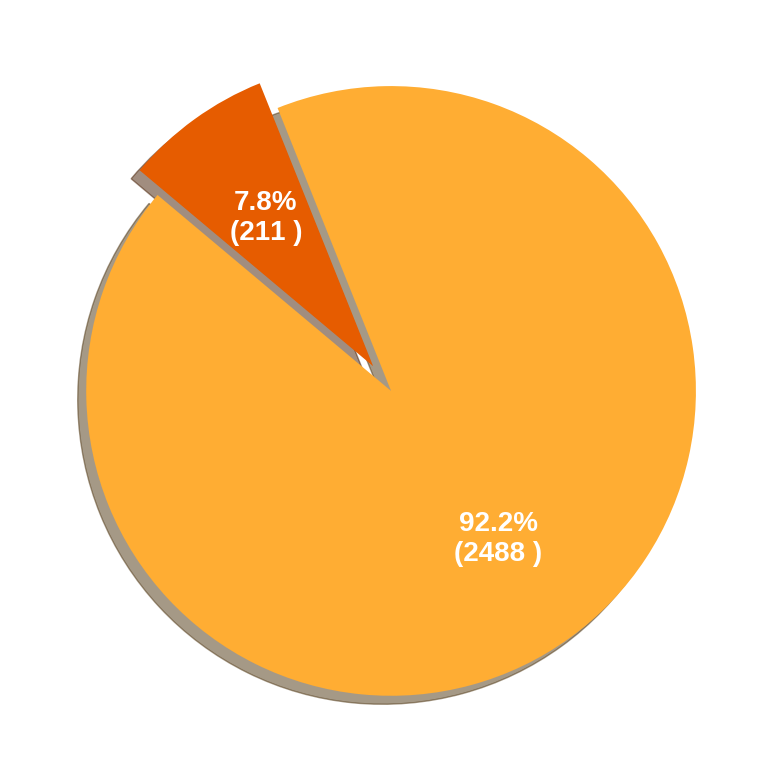

=== RINCIAN JUMLAH DATA ===
Hari Aman (Bukan LTI) : 2488 kejadian
Insiden LTI (Risiko)  : 211 kejadian


In [ ]:
import matplotlib.pyplot as plt

# 1. Menghitung jumlah distribusi kelas LTI (0 vs 1)
lti_counts = df['LTI'].value_counts()

# Fungsi cerdas untuk menampilkan Persentase DAN Jumlah Asli di dalam Pie
def format_label(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute} )"

# 2. Pengaturan Estetika Visual (Tema PPT: Gradasi Oranye)
labels = ['Bukan LTI', 'Insiden LTI']
colors = ['#ffad33', '#e65c00']  # Oren Muda (Bukan LTI) dan Oren Tua/Gelap (Insiden LTI)
explode = (0, 0.1)               # Menarik potongan 'LTI' keluar sebesar 0.2 agar mencolok

# 3. Membuat Figure dengan Latar Belakang Transparan
fig = plt.figure(figsize=(8, 8), facecolor='none')

# 4. Membuat Pie Chart
patches, texts, autotexts = plt.pie(
    lti_counts,
    labels=labels,
    autopct=lambda pct: format_label(pct, lti_counts), # Memanggil fungsi khusus
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True
)

# 5. Kustomisasi Teks Luar (Label "Bukan LTI" & "Insiden LTI")
for text in texts:
    text.set_color('white')
    text.set_fontsize(20)        # Ukuran huruf diperbesar
    text.set_fontweight('bold')  # Huruf ditebalkan

# 6. Kustomisasi Teks Dalam (Persentase & Angka)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(20)        # Ukuran huruf persentase diperbesar
    autotext.set_fontweight('bold')  # Huruf ditebalkan

plt.tight_layout()

plt.show()

# Mencetak angka di terminal sebagai verifikasi
print("=== RINCIAN JUMLAH DATA ===")
print(f"Hari Aman (Bukan LTI) : {lti_counts[0]} kejadian")
print(f"Insiden LTI (Risiko)  : {lti_counts[1]} kejadian")

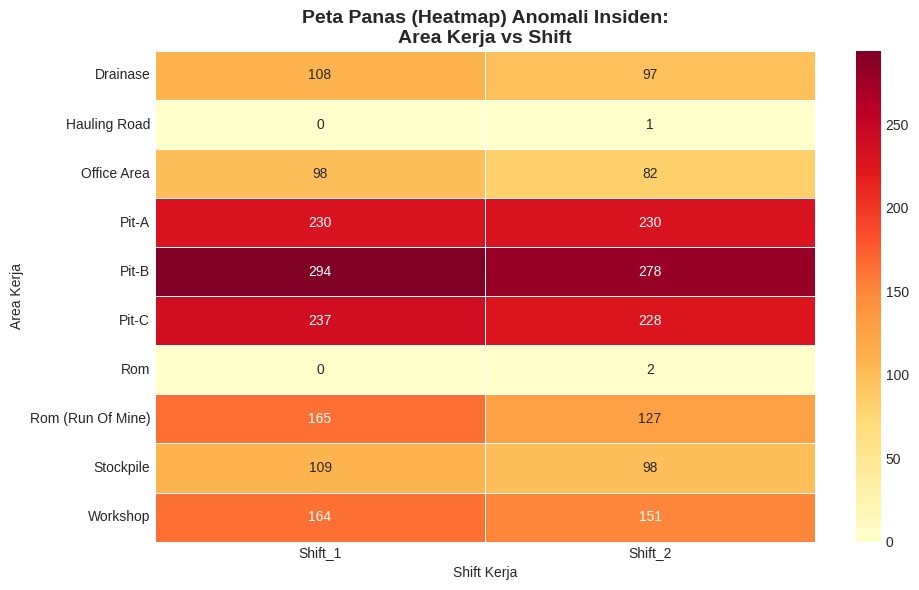

In [ ]:
plt.figure(figsize=(10, 6))
shift_area = pd.crosstab(df['Area_Kerja'], df['Shift'])
sns.heatmap(shift_area, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Peta Panas (Heatmap) Anomali Insiden:\nArea Kerja vs Shift', fontsize=14, fontweight='bold')
plt.xlabel('Shift Kerja')
plt.ylabel('Area Kerja')
plt.tight_layout()
plt.show()

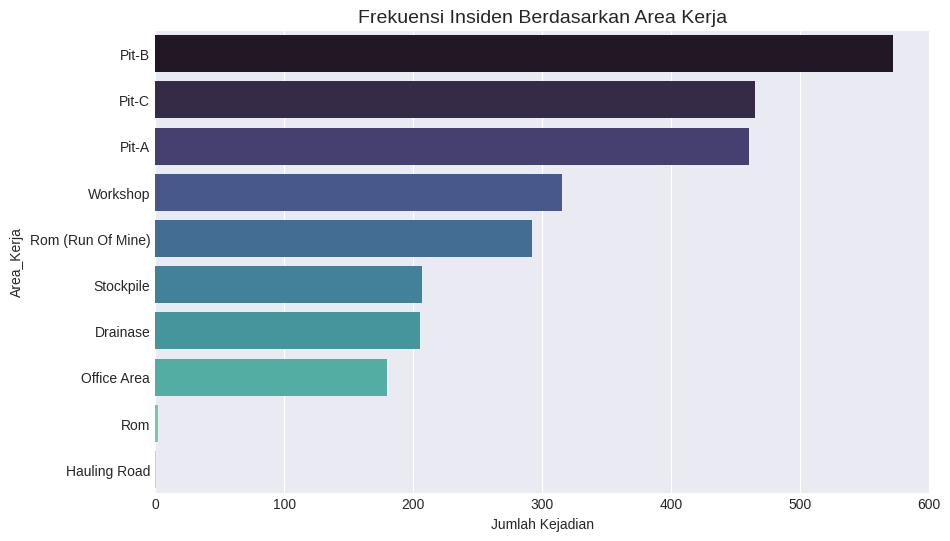

In [ ]:
# 3. Komposisi Insiden per Area Kerja (Untuk PPT)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Area_Kerja', order=df['Area_Kerja'].value_counts().index, palette='mako')
plt.title('Frekuensi Insiden Berdasarkan Area Kerja', fontsize=14)
plt.xlabel('Jumlah Kejadian')
plt.show()

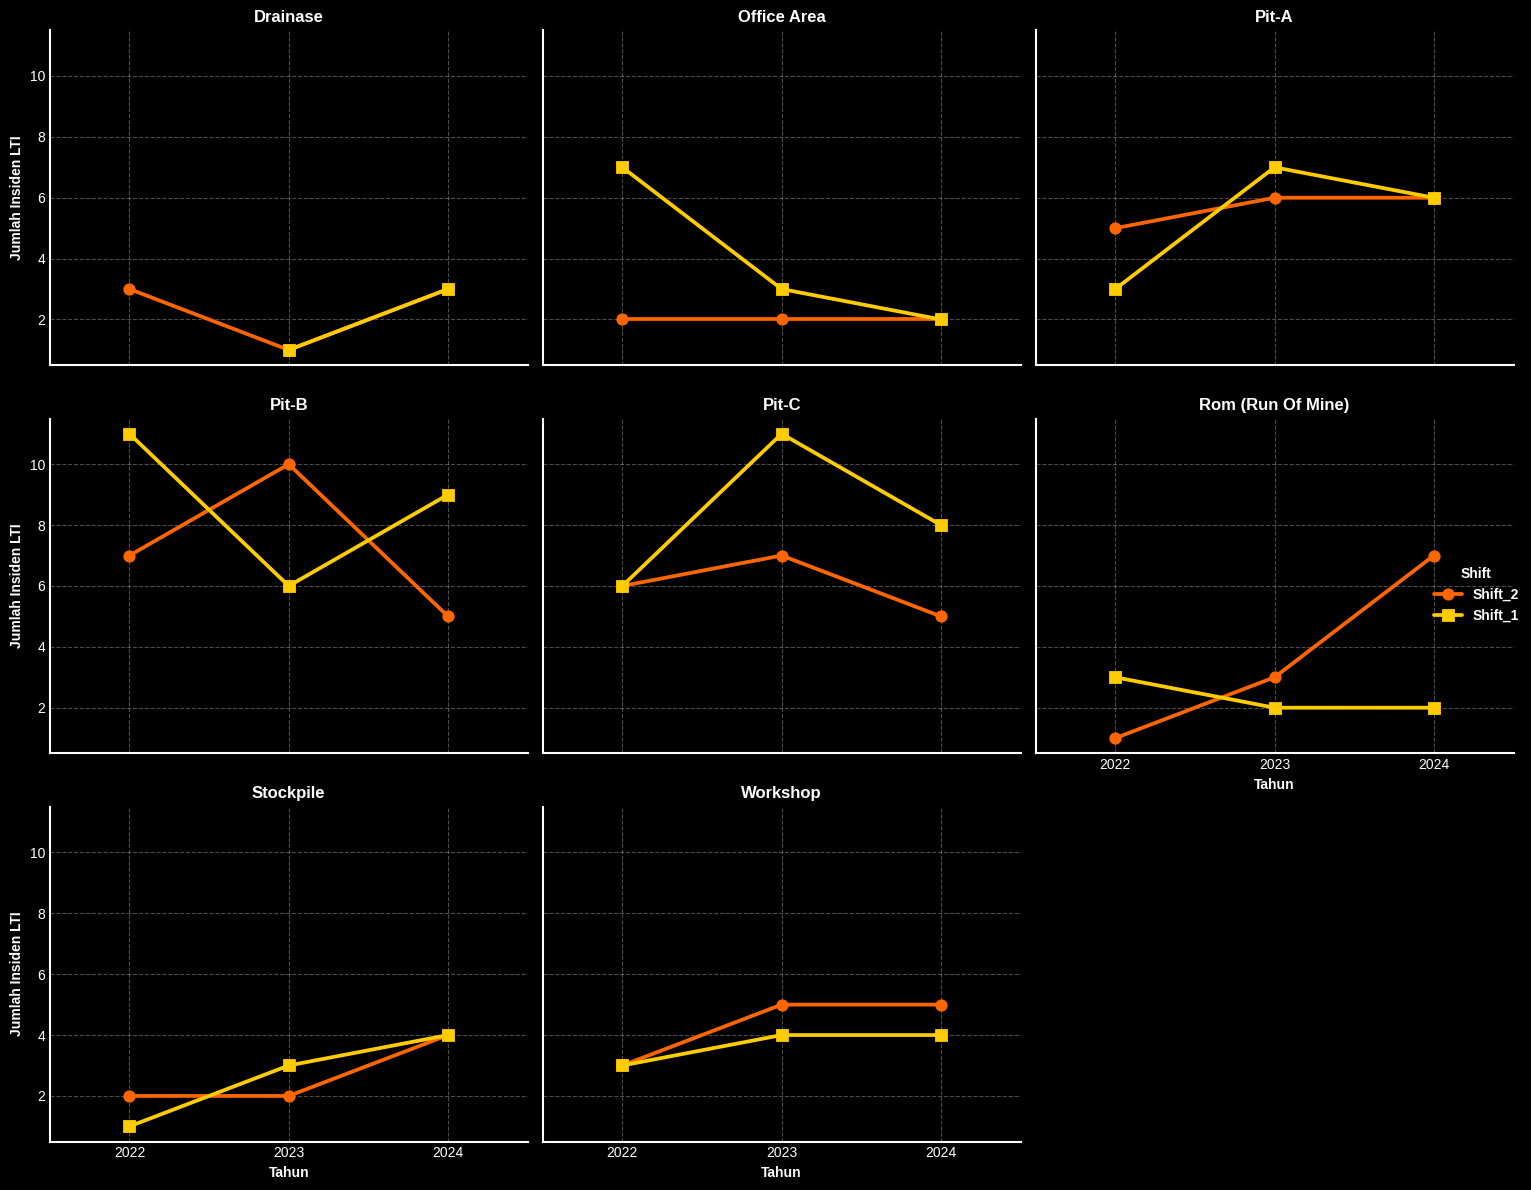

In [ ]:
# WAJIB: Filter murni hanya data insiden (LTI == 1)
df_insiden = df[df['LTI'] == 1].copy()
df_insiden['Periode_Bulan'] = df_insiden['Tanggal'].dt.to_period('M').astype(str)

# 1. Agregasi Tren Tahunan dipecah Area dan Shift
tren_area_shift = df_insiden.groupby(['Tahun', 'Area_Kerja', 'Shift']).size().reset_index(name='Jumlah_Insiden')

# 2. Membuat FacetGrid (Multi-Panel Plot)
g = sns.catplot(
    data=tren_area_shift, x='Tahun', y='Jumlah_Insiden', hue='Shift',
    col='Area_Kerja', col_wrap=3, kind='point',
    palette=['#ff6600', '#ffcc00'], # Warna Oranye dan Kuning
    height=4, aspect=1.2, markers=['o', 's']
)

# 3. Eksekusi Estetika Transparan pada seluruh kotak
g.fig.patch.set_facecolor('black')

for ax in g.axes.flat:
    ax.set_facecolor('black')
    ax.grid(True, linestyle='--', alpha=0.3, color='white')

    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_linewidth(1.5)

    ax.tick_params(colors='white', labelsize=10)
    ax.set_xlabel('Tahun', color='white', fontweight='bold')
    ax.set_ylabel('Jumlah Insiden LTI', color='white', fontweight='bold')

    # Judul area kerja warna putih
    title = ax.get_title().replace('Area_Kerja = ', '')
    ax.set_title(title, color='white', fontweight='bold', fontsize=12)

# 4. Kustomisasi Legenda di samping
plt.setp(g.legend.get_texts(), color='white', fontweight='bold')
plt.setp(g.legend.get_title(), color='white', fontweight='bold')
g.legend.get_frame().set_facecolor('black')
g.legend.get_frame().set_edgecolor('white')

plt.tight_layout()
plt.savefig('3_tren_tahun_area_shift_LTI_transparent.png', transparent=True, dpi=300)
plt.show()

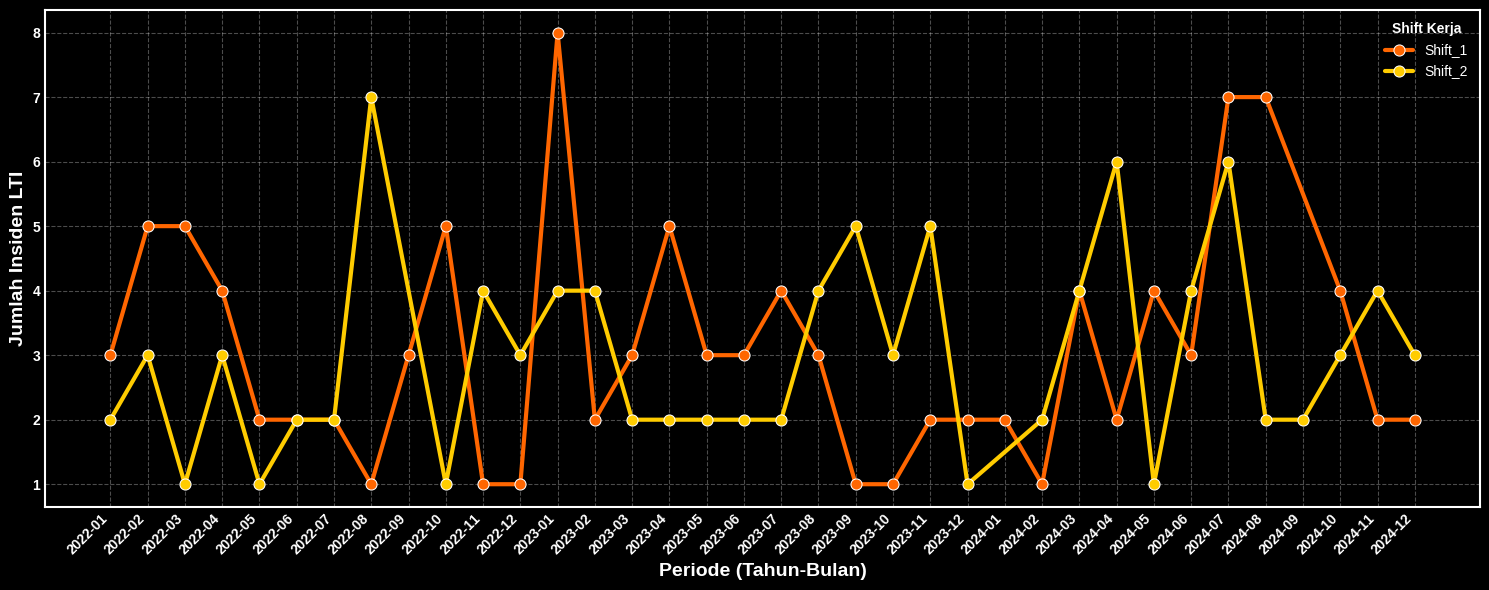

In [ ]:
# 1. Agregasi Tren Bulanan dipecah berdasarkan Shift
tren_shift_bulan = df_insiden.groupby(['Periode_Bulan', 'Shift']).size().reset_index(name='Jumlah_Insiden')

# 2. Setup Kanvas Transparan
fig = plt.figure(figsize=(15, 6), facecolor='black')
ax = fig.add_subplot(111)
ax.set_facecolor('black')

# 3. Plotting Multi-Garis (Oranye & Kuning Emas)
sns.lineplot(data=tren_shift_bulan, x='Periode_Bulan', y='Jumlah_Insiden', hue='Shift',
             marker='o', linewidth=3, markersize=8,
             palette=['#ff6600', '#ffcc00'], ax=ax) # Warna disesuaikan jumlah shift

# 4. Estetika Teks, Grid, dan Bingkai
plt.xlabel('Periode (Tahun-Bulan)', color='white', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Insiden LTI', color='white', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10, color='white', fontweight='bold')
plt.yticks(fontsize=10, color='white', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3, color='white')

for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(1.5)

# 5. Kustomisasi Legenda (Agar Kotak & Teksnya Transparan + Putih)
legend = ax.legend(title='Shift Kerja', facecolor='black', edgecolor='white', labelcolor='white')
legend.get_title().set_color('white')
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.savefig('2_tren_shift_bulanan_LTI_transparent.png', transparent=True, dpi=300)
plt.show()

# 6. Penentuan Label Data

Menentukan target utama yang ingin diprediksi beserta strategi pembagian datanya.

- Definisi Target: Menetapkan LTI sebagai label yang akan diprediksi (0 mewakili tidak terjadi LTI, 1 mewakili terjadi LTI).

- Analisis Distribusi Kelas: Memeriksa perbandingan proporsi antara kejadian LTI=1 dan LTI=0 untuk mengidentifikasi keberadaan class imbalance (ketidakseimbangan kelas).

- Strategi Penanganan Imbalance: Memilih teknik yang tepat (SMOTE, pembobotan kelas, undersampling) untuk memastikan model tidak bias ke mayoritas kelas yang aman.

- Pemilihan Prediktor: Menyeleksi variabel input yang paling kuat berdasarkan korelasi statistika dan relevansi di bidang SHE (Safety, Health, and Environment).

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Update kolom_drop: Membuang SEMUA kolom ID, teks, EDA, Data Leakage, dan Multikol
kolom_drop = [
    'No', 'Tanggal', 'Catatan', 'Supervisor_ID', 'Tindakan_Korektif',
    'Status_Tindakan', 'Lokasi_Spesifik', 'Periode_Bulan',
    'Hari_Hilang_Kerja', 'LTIR', 'Total_Insiden_Tercatat', 'TRIR', 'Severity_Rate',
    'Property_Damage', 'Fatality', 'Jenis_Insiden', 'Near_Miss', 'First_Aid', 'Medical_Treatment', 'Penyebab_Utama', 'Shift'
]

# Gunakan errors='ignore' agar kalau ada kolom yang sudah terlanjur hilang, kode tidak error
df_model = df.drop(columns=kolom_drop, errors='ignore')

# Membuang duplikasi fitur hari (jika ada kolom 'Hari' bawaan dari Excel asli)
if 'Hari' in df_model.columns:
    df_model = df_model.drop(columns=['Hari'])

# 2. One-Hot Encoding Otomatis
# Mengubah sisa kolom teks menjadi dummy variables (0/1)
df_model = pd.get_dummies(df_model, drop_first=True, dtype=int)

# 3. Definisikan X (Fitur/Prediktor murni operasional) dan y (Label/Target LTI)
X = df_model.drop('LTI', axis=1)
y = df_model['LTI']

# 4. Split Data (80:20) dengan Stratify (Menjaga proporsi kelas minoritas LTI)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Eksekusi SMOTE untuk menangani Class Imbalance pada data latih
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== Hasil Eksekusi SMOTE ===")
print(f"Distribusi kelas SEBELUM SMOTE:\n{y_train.value_counts()}\n")
print(f"Distribusi kelas SETELAH SMOTE:\n{y_train_smote.value_counts()}\n")
print("Format Data X_train_smote sudah murni numerik dan BEBAS LEAKAGE (Siap untuk Machine Learning):")
display(X_train_smote.head(3))

=== Hasil Eksekusi SMOTE ===
Distribusi kelas SEBELUM SMOTE:
LTI
0    1990
1     169
Name: count, dtype: int64

Distribusi kelas SETELAH SMOTE:
LTI
0    1990
1    1990
Name: count, dtype: int64

Format Data X_train_smote sudah murni numerik dan BEBAS LEAKAGE (Siap untuk Machine Learning):


,Bulan,Kuartal,Tahun,Jumlah_Tenaga_Kerja,Jam_Kerja,Rasio_Beban_Kerja,Rata2_Pekerja_Area,Rasio_Kepadatan_Area,Musim_Hujan,Is_Shift_Malam,...,Risiko_Aktivitas_Cuaca_Pumping_Berawan,Risiko_Aktivitas_Cuaca_Pumping_Berkabut,Risiko_Aktivitas_Cuaca_Pumping_Cerah,Risiko_Aktivitas_Cuaca_Pumping_Hujan Lebat,Risiko_Aktivitas_Cuaca_Pumping_Hujan Ringan,Risiko_Aktivitas_Cuaca_Survei_Berawan,Risiko_Aktivitas_Cuaca_Survei_Berkabut,Risiko_Aktivitas_Cuaca_Survei_Cerah,Risiko_Aktivitas_Cuaca_Survei_Hujan Lebat,Risiko_Aktivitas_Cuaca_Survei_Hujan Ringan
0,3,1,2024,37,475.0,12.837838,26.622222,1.389816,1,1,...,0,0,0,0,1,0,0,0,0,0
1,12,4,2024,41,508.3,12.397561,26.537634,1.544976,1,1,...,0,0,0,0,0,0,0,0,0,0
2,5,2,2022,15,178.3,11.886667,26.568493,0.564578,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
df_model.head()

,Bulan,Kuartal,Tahun,LTI,Jumlah_Tenaga_Kerja,Jam_Kerja,Rasio_Beban_Kerja,Rata2_Pekerja_Area,Rasio_Kepadatan_Area,Musim_Hujan,...,Risiko_Aktivitas_Cuaca_Pumping_Berawan,Risiko_Aktivitas_Cuaca_Pumping_Berkabut,Risiko_Aktivitas_Cuaca_Pumping_Cerah,Risiko_Aktivitas_Cuaca_Pumping_Hujan Lebat,Risiko_Aktivitas_Cuaca_Pumping_Hujan Ringan,Risiko_Aktivitas_Cuaca_Survei_Berawan,Risiko_Aktivitas_Cuaca_Survei_Berkabut,Risiko_Aktivitas_Cuaca_Survei_Cerah,Risiko_Aktivitas_Cuaca_Survei_Hujan Lebat,Risiko_Aktivitas_Cuaca_Survei_Hujan Ringan
0,6,2,2023,0,29,298.2,10.282759,26.512195,1.093836,0,...,0,0,0,0,0,0,0,0,0,0
1,5,2,2023,0,10,105.4,10.540000,26.512195,0.377185,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,2023,0,35,393.7,11.248571,26.568493,1.317350,1,...,0,0,0,0,0,0,0,0,0,0
3,11,4,2022,0,22,258.0,11.727273,26.537634,0.829011,1,...,0,0,0,0,0,0,0,0,0,0
4,5,2,2023,0,40,459.6,11.490000,26.610140,1.503186,0,...,0,0,0,0,0,0,1,0,0,0


# 7. Pembangunan Model Prediksi LTI

- Pemisahan Dataset: Membagi data menjadi kelompok training (80%) dan testing (20%) secara acak, namun tetap terstratum (stratified) berdasarkan label LTI agar distribusinya rata.
- Pemilihan Algoritma: Menentukan minimal 2 metode klasifikasi (contoh: Logistic Regression, Decision Tree, Random Forest, XGBoost, Lightgbm, Catboost) dan menyertakan alasan logis pemilihannya.
- Pelatihan Model: Melatih algoritma pada data training yang dikombinasikan dengan teknik hyperparameter tuning sederhana untuk mengoptimalkan kinerjanya.
- Prediksi Data Uji: Melakukan simulasi prediksi menggunakan data testing dan mencatat hasilnya dengan baik.
- Validasi Silang (Cross-Validation): Menerapkan teknik k-fold cross-validation (dengan nilai minimal k=5) guna memastikan model stabil dan tidak overfitting.

In [ ]:
# List untuk menyimpan semua hasil evaluasi
evaluation_results = []

# Fungsi bantuan untuk menghitung dan menyimpan metrik
def evaluasi_model(nama_model, model, X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')

    evaluation_results.append({
        'Model': nama_model,
        'Akurasi': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'CV_Recall_Mean': cv_scores.mean()
    })

    print(f"--- Metrik {nama_model} ---")
    print(f"Akurasi   : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f} (Fokus Utama)")
    print(f"F1-Score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc:.4f}")
    print(f"CV Recall : {cv_scores.mean():.4f}\n")

# Fungsi bantuan untuk plot Feature Importance
def plot_feature_importance(nama_model, importances, fitur_names):
    feat_imp = pd.Series(importances, index=fitur_names).sort_values(ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title(f'Top 10 Feature Importance - {nama_model}', fontsize=12)
    plt.xlabel('Importance Score')
    plt.ylabel('Fitur')
    plt.tight_layout()
    plt.show()

## Decission Tree

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

### SMOTE

In [ ]:
# ==============================================================================
# 2. DECISION TREE + SMOTE BIASA (Threshold Bawaan 0.5)
# Menggunakan X_train_smote (Data Oversampling) tanpa mengubah threshold
# ==============================================================================
print("\n>>> 2. Rapor DT + SMOTE Biasa (Threshold 0.5) <<<")
dt_smote_biasa = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_smote_biasa.fit(X_train_smote, y_train_smote)
y_pred_smote_biasa = dt_smote_biasa.predict(X_test)

sns.heatmap(confusion_matrix(y_test, y_pred_smote_biasa), annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('DT + SMOTE Biasa', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')

print(classification_report(y_test, y_pred_smote_biasa))

y_pred_prob_train = dt_smote_biasa.predict_proba(X_train_smote)[:, 1]
y_pred_prob_test = dt_smote_biasa.predict_proba(X_test)[:, 1]

# 1. Menghitung Metrik Evaluasi
akurasi = accuracy_score(y_test, y_pred_smote_biasa)
precision = precision_score(y_test, y_pred_smote_biasa)
recall = recall_score(y_test, y_pred_smote_biasa)
f1 = f1_score(y_test, y_pred_smote_biasa)

# AUC-ROC dihitung menggunakan probabilitas (bukan hasil custom 0/1) agar lebih akurat
auc_roc = roc_auc_score(y_test, y_pred_prob_test)

# (Opsional) Menghitung CV Recall menggunakan probabilitas dan threshold manual
# Karena pakai custom threshold, untuk simplifikasi kita hitung CV bawaan dulu,
# atau kamu bisa lewati baris CV ini jika proses runningnya terlalu lama.
cv_recall = cross_val_score(dt_smote_biasa, X_train, y_train, cv=5, scoring='recall').mean()

# 2. Mencetak Output Rapi Sejajar
print("\n--- Metrik Decision Tree (Thresh 0.1) ---")
print(f"{'Akurasi':<10}: {akurasi:.4f}")
print(f"{'Precision':<10}: {precision:.4f}")
print(f"{'Recall':<10}: {recall:.4f}")
print(f"{'F1-Score':<10}: {f1:.4f}")
print(f"{'AUC-ROC':<10}: {auc_roc:.4f}")
print(f"{'CV Recall':<10}: {cv_recall:.4f}")


>>> 2. Rapor DT + SMOTE Biasa (Threshold 0.5) <<<
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       498
           1       0.10      0.31      0.15        42

    accuracy                           0.73       540
   macro avg       0.51      0.54      0.50       540
weighted avg       0.86      0.73      0.79       540


--- Metrik Decision Tree (Thresh 0.1) ---
Akurasi   : 0.7296
Precision : 0.1000
Recall    : 0.3095
F1-Score  : 0.1512
AUC-ROC   : 0.5432
CV Recall : 0.0296


### Class Weight

>>> 1. Rapor DT + Class Weight <<<
              precision    recall  f1-score   support

           0       0.93      0.67      0.78       498
           1       0.09      0.38      0.15        42

    accuracy                           0.65       540
   macro avg       0.51      0.53      0.46       540
weighted avg       0.86      0.65      0.73       540


--- Metrik Decision Tree (Thresh 0.1) ---
Akurasi   : 0.6519
Precision : 0.0899
Recall    : 0.3810
F1-Score  : 0.1455
AUC-ROC   : 0.5432
CV Recall : 0.2360


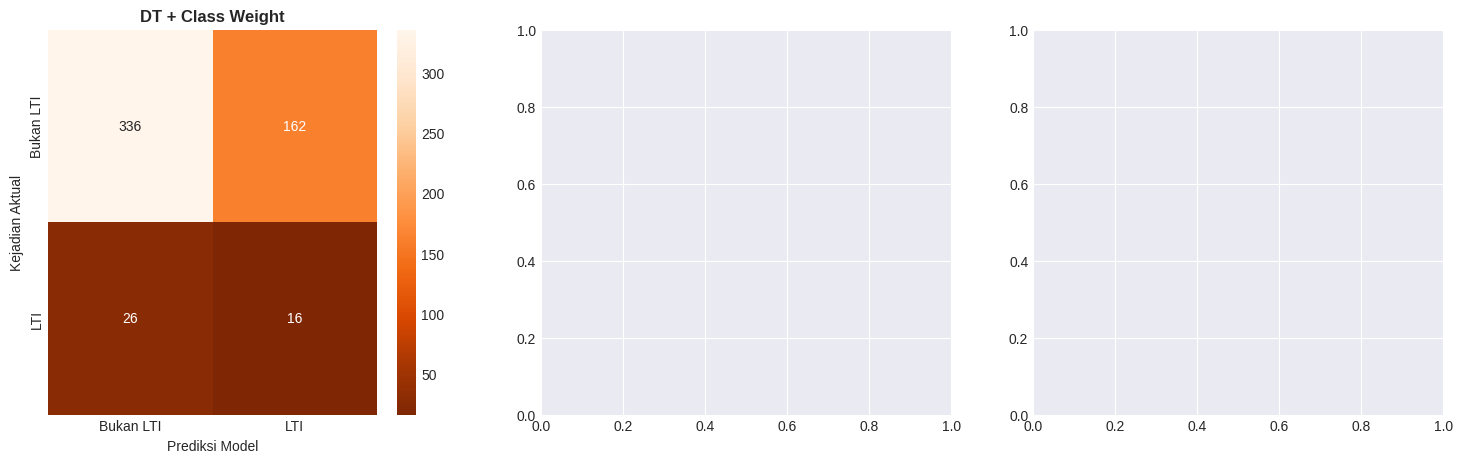

In [ ]:
# Siapkan kanvas untuk 3 gambar berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==============================================================================
# 1. DECISION TREE + CLASS WEIGHT (BALANCED)
# Data Asli (X_train), tapi algoritma diberikan bobot penalti
# ==============================================================================
print(">>> 1. Rapor DT + Class Weight <<<")
dt_weight = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
dt_weight.fit(X_train, y_train)
y_pred_weight = dt_weight.predict(X_test)

sns.heatmap(confusion_matrix(y_test, y_pred_weight), annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('DT + Class Weight', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

print(classification_report(y_test, y_pred_weight))

# 1. Menghitung Metrik Evaluasi
akurasi = accuracy_score(y_test, y_pred_weight)
precision = precision_score(y_test, y_pred_weight)
recall = recall_score(y_test, y_pred_weight)
f1 = f1_score(y_test, y_pred_weight)

# AUC-ROC dihitung menggunakan probabilitas (bukan hasil custom 0/1) agar lebih akurat
auc_roc = roc_auc_score(y_test, y_pred_prob_test)

# (Opsional) Menghitung CV Recall menggunakan probabilitas dan threshold manual
# Karena pakai custom threshold, untuk simplifikasi kita hitung CV bawaan dulu,
# atau kamu bisa lewati baris CV ini jika proses runningnya terlalu lama.
cv_recall = cross_val_score(dt_weight, X_train, y_train, cv=5, scoring='recall').mean()

# 2. Mencetak Output Rapi Sejajar
print("\n--- Metrik Decision Tree (Thresh 0.1) ---")
print(f"{'Akurasi':<10}: {akurasi:.4f}")
print(f"{'Precision':<10}: {precision:.4f}")
print(f"{'Recall':<10}: {recall:.4f}")
print(f"{'F1-Score':<10}: {f1:.4f}")
print(f"{'AUC-ROC':<10}: {auc_roc:.4f}")
print(f"{'CV Recall':<10}: {cv_recall:.4f}")

### RUS

In [ ]:
# ==========================================
# PERSIAPAN DATA: RANDOM UNDER SAMPLING (RUS)
# ==========================================
from imblearn.under_sampling import RandomUnderSampler

print("=== MENCETAK DATA UNDERSAMPLING (50:50) ===")
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Distribusi Kelas Sebelum RUS:\n{y_train.value_counts()}\n")
print(f"Distribusi Kelas Sesudah RUS:\n{y_train_rus.value_counts()}")

=== MENCETAK DATA UNDERSAMPLING (50:50) ===
Distribusi Kelas Sebelum RUS:
LTI
0    1990
1     169
Name: count, dtype: int64

Distribusi Kelas Sesudah RUS:
LTI
0    169
1    169
Name: count, dtype: int64


In [ ]:
# ==============================================================================
# 3. DECISION TREE + RUS (Random Under Sampling)
# Menggunakan X_train_rus (Data Undersampling)
# ==============================================================================
print("\n>>> 3. Rapor DT + RUS <<<")
dt_rus = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = dt_rus.predict(X_test)

sns.heatmap(confusion_matrix(y_test, y_pred_rus), annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[2])
axes[2].set_title('DT + RUS', fontweight='bold')
axes[2].set_xlabel('Prediksi Model')

print(classification_report(y_test, y_pred_rus))

# Tampilkan ketiga matriks
plt.tight_layout()
plt.show()

# 1. Menghitung Metrik Evaluasi
akurasi = accuracy_score(y_test, y_pred_rus)
precision = precision_score(y_test, y_pred_rus)
recall = recall_score(y_test, y_pred_rus)
f1 = f1_score(y_test, y_pred_rus)

# AUC-ROC dihitung menggunakan probabilitas (bukan hasil custom 0/1) agar lebih akurat
auc_roc = roc_auc_score(y_test, y_pred_prob_test)

# (Opsional) Menghitung CV Recall menggunakan probabilitas dan threshold manual
# Karena pakai custom threshold, untuk simplifikasi kita hitung CV bawaan dulu,
# atau kamu bisa lewati baris CV ini jika proses runningnya terlalu lama.
cv_recall = cross_val_score(dt_rus, X_train, y_train, cv=5, scoring='recall').mean()

# 2. Mencetak Output Rapi Sejajar
print("\n--- Metrik Decision Tree (Thresh 0.1) ---")
print(f"{'Akurasi':<10}: {akurasi:.4f}")
print(f"{'Precision':<10}: {precision:.4f}")
print(f"{'Recall':<10}: {recall:.4f}")
print(f"{'F1-Score':<10}: {f1:.4f}")
print(f"{'AUC-ROC':<10}: {auc_roc:.4f}")
print(f"{'CV Recall':<10}: {cv_recall:.4f}")




>>> 3. Rapor DT + RUS <<<
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       498
           1       0.08      0.24      0.12        42

    accuracy                           0.72       540
   macro avg       0.50      0.50      0.48       540
weighted avg       0.86      0.72      0.78       540



<Figure size 640x480 with 0 Axes>


--- Metrik Decision Tree (Thresh 0.1) ---
Akurasi   : 0.7241
Precision : 0.0787
Recall    : 0.2381
F1-Score  : 0.1183
AUC-ROC   : 0.5432
CV Recall : 0.0296


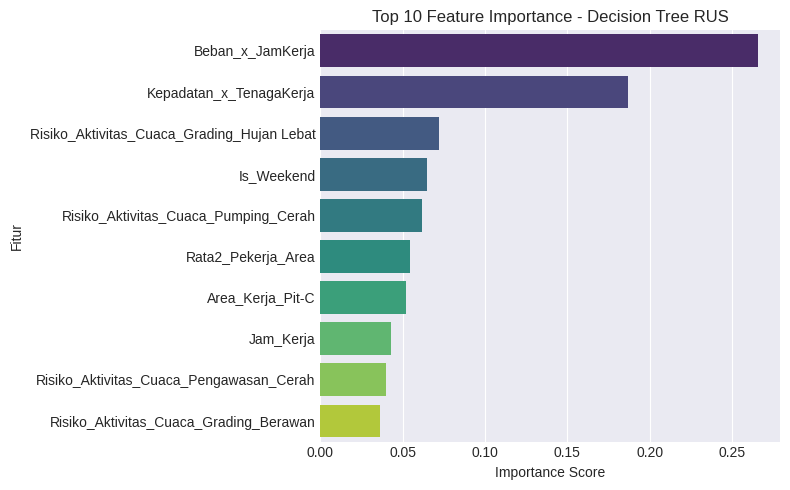

In [ ]:
plot_feature_importance(
    nama_model='Decision Tree RUS',
    importances=dt_rus.feature_importances_,
    fitur_names=X_train_rus.columns
)

### Custom Threshold


>>> PEMODELAN DECISION TREE + SMOTE + THRESHOLD 0.1 <<<


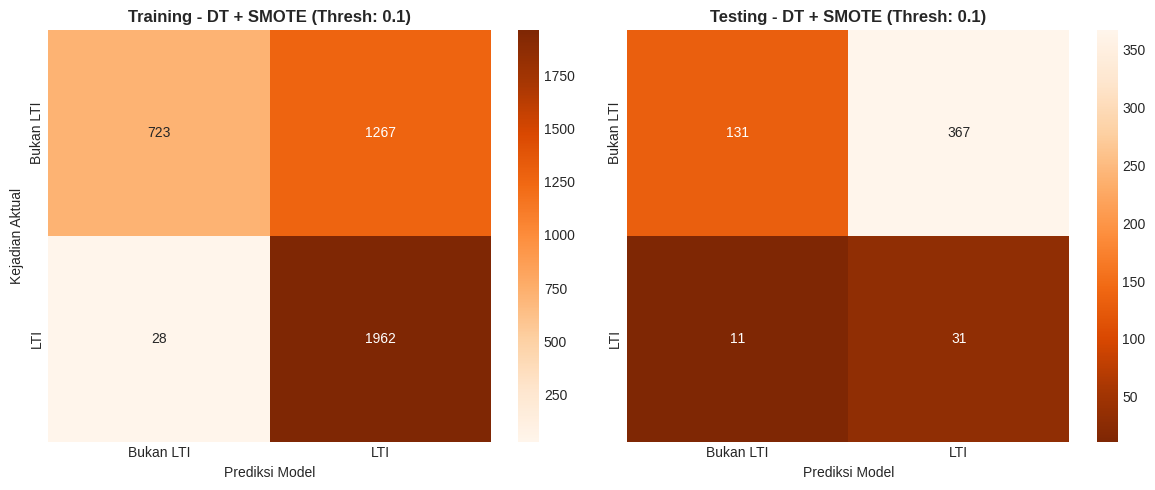

--- Rapor Decision Tree + SMOTE (Threshold 0.1) ---
              precision    recall  f1-score   support

           0       0.92      0.26      0.41       498
           1       0.08      0.74      0.14        42

    accuracy                           0.30       540
   macro avg       0.50      0.50      0.28       540
weighted avg       0.86      0.30      0.39       540



In [ ]:
print("\n>>> PEMODELAN DECISION TREE + SMOTE + THRESHOLD 0.1 <<<")

# 1. Terapkan SMOTE pada data training agar rasio kelas menjadi 50:50
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2. Bangun dan Latih Model Decision Tree
# Note: max_depth=5 dipasang agar pohon tidak terlalu dalam dan mencegah overfitting
# karena Decision Tree sangat sensitif terhadap data kloningan dari SMOTE
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_smote, y_train_smote)

# 3. Ambil Prediksi berupa PROBABILITAS (Bukan langsung kelas 0 atau 1)
# [:, 1] artinya kita hanya mengambil kolom probabilitas untuk kelas 1 (LTI)
y_pred_prob_train = dt_model.predict_proba(X_train_smote)[:, 1]
y_pred_prob_test = dt_model.predict_proba(X_test)[:, 1]

# 4. TERAPKAN CUSTOM THRESHOLD 0.1
# Jika probabilitas >= 0.1, maka jadi True (1), sisanya False (0)
CUSTOM_THRESHOLD = 0.1
y_pred_train_custom = (y_pred_prob_train >= CUSTOM_THRESHOLD).astype(int)
y_pred_test_custom = (y_pred_prob_test >= CUSTOM_THRESHOLD).astype(int)

# 5. Matriks Visualisasi (Tema Oranye senada dengan PPT)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Training
sns.heatmap(confusion_matrix(y_train_smote, y_pred_train_custom), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title(f'Training - DT + SMOTE (Thresh: {CUSTOM_THRESHOLD})', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

# Plot Testing
sns.heatmap(confusion_matrix(y_test, y_pred_test_custom), annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title(f'Testing - DT + SMOTE (Thresh: {CUSTOM_THRESHOLD})', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

# 6. Rapor Evaluasi Akhir
print(f"--- Rapor Decision Tree + SMOTE (Threshold {CUSTOM_THRESHOLD}) ---")
print(classification_report(y_test, y_pred_test_custom))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

# 1. Menghitung Metrik Evaluasi
akurasi = accuracy_score(y_test, y_pred_test_custom)
precision = precision_score(y_test, y_pred_test_custom)
recall = recall_score(y_test, y_pred_test_custom)
f1 = f1_score(y_test, y_pred_test_custom)

# AUC-ROC dihitung menggunakan probabilitas (bukan hasil custom 0/1) agar lebih akurat
auc_roc = roc_auc_score(y_test, y_pred_prob_test)

# (Opsional) Menghitung CV Recall menggunakan probabilitas dan threshold manual
# Karena pakai custom threshold, untuk simplifikasi kita hitung CV bawaan dulu,
# atau kamu bisa lewati baris CV ini jika proses runningnya terlalu lama.
cv_recall = cross_val_score(dt_model, X_train_smote, y_train_smote, cv=5, scoring='recall').mean()

# 2. Mencetak Output Rapi Sejajar
print("\n--- Metrik Decision Tree (Thresh 0.1) ---")
print(f"{'Akurasi':<10}: {akurasi:.4f}")
print(f"{'Precision':<10}: {precision:.4f}")
print(f"{'Recall':<10}: {recall:.4f}")
print(f"{'F1-Score':<10}: {f1:.4f}")
print(f"{'AUC-ROC':<10}: {auc_roc:.4f}")
print(f"{'CV Recall':<10}: {cv_recall:.4f}")


--- Metrik Decision Tree (Thresh 0.1) ---
Akurasi   : 0.3000
Precision : 0.0779
Recall    : 0.7381
F1-Score  : 0.1409
AUC-ROC   : 0.5432
CV Recall : 0.7794


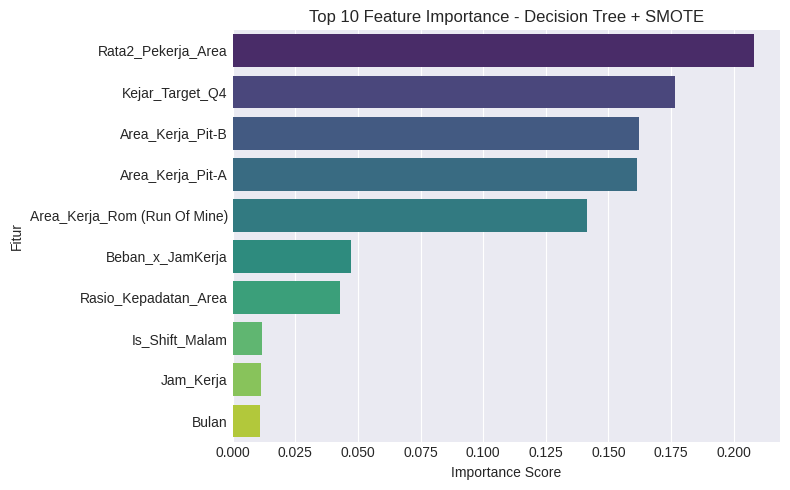

In [ ]:
plot_feature_importance(
    nama_model='Decision Tree + SMOTE',
    importances=dt_model.feature_importances_,
    fitur_names=X_train_smote.columns
)

>>> SHAP SUMMARY PLOT: ARAH PENGARUH VARIABEL <<<


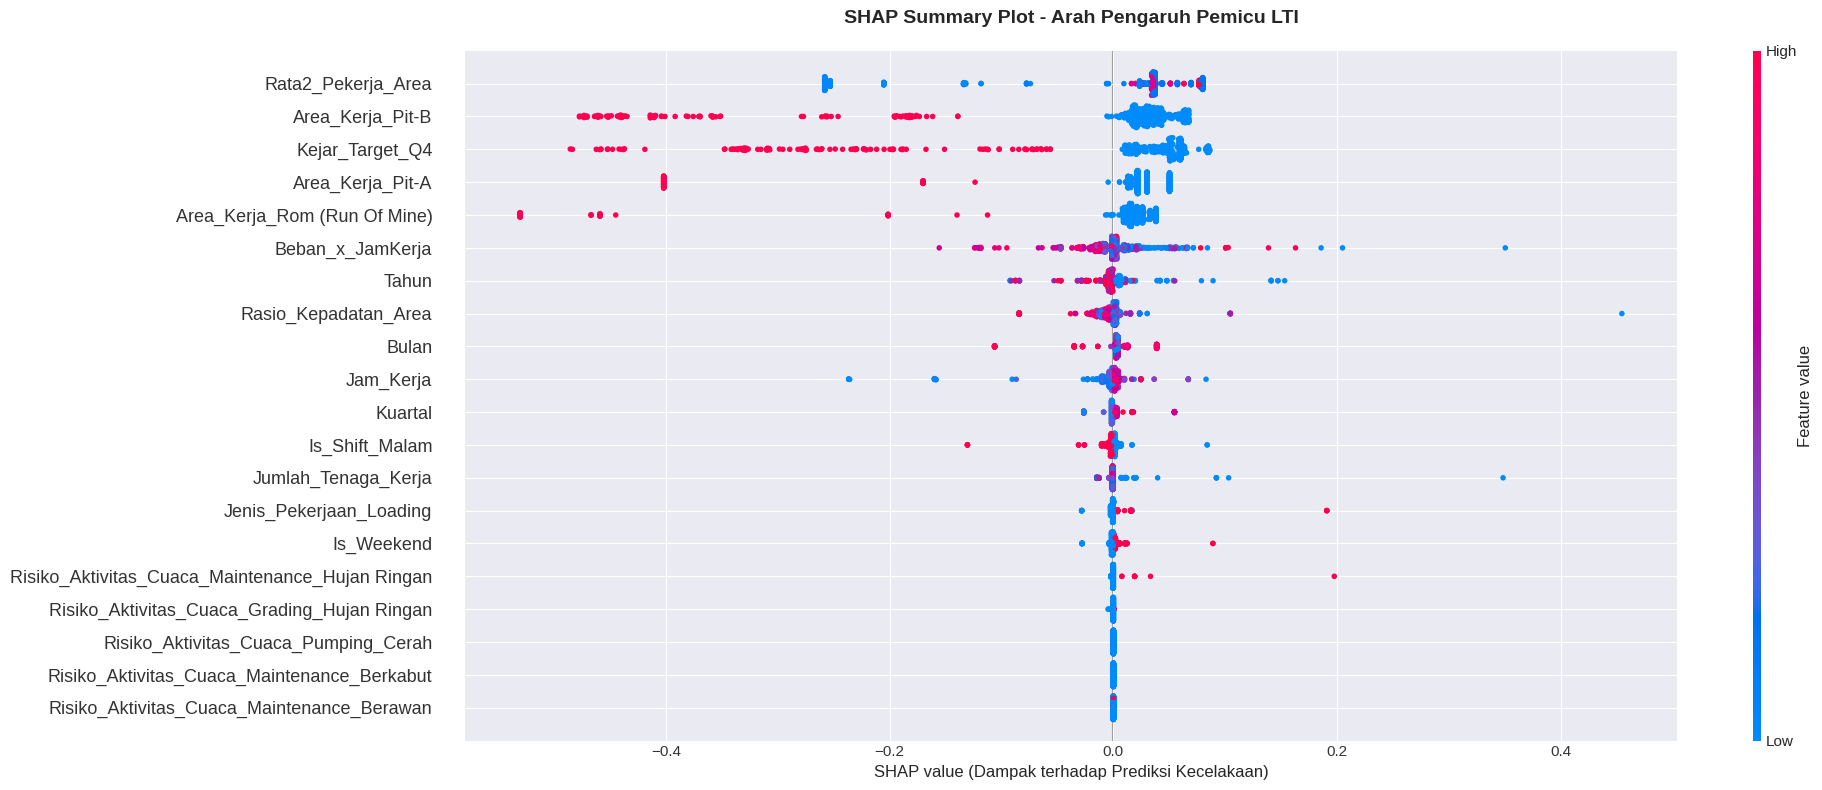

In [ ]:
# Install dulu library-nya kalau belum punya: !pip install shap
import shap
import matplotlib.pyplot as plt

print(">>> SHAP SUMMARY PLOT: ARAH PENGARUH VARIABEL <<<")

# ================= TRIK BUNGLON (PENGAMAN NAMA KOLOM) =================
X_test_shap = X_test.copy()
# Memastikan X_test memakai ejaan nama kolom yang diingat oleh model
if hasattr(dt_model, 'feature_names_in_'):
    X_test_shap.columns = dt_model.feature_names_in_
# ======================================================================

# 1. Buat 'Explainer' untuk membedah otak Decision Tree
explainer = shap.TreeExplainer(dt_model)

# 2. Hitung nilai SHAP menggunakan data Testing yang namanya sudah dicocokkan
shap_values = explainer.shap_values(X_test_shap)

# 3. AUTO-DETEKSI FORMAT SHAP (SOLUSI ERROR MATRIKS)
if isinstance(shap_values, list):
    shap_fix = shap_values[1]          # Jika outputnya list, ambil elemen ke-2 (Kelas LTI)
elif len(shap_values.shape) == 3:
    shap_fix = shap_values[:, :, 1]    # Jika outputnya array 3D
else:
    shap_fix = shap_values             # Jika outputnya sudah berupa array 2D tunggal

# 4. Tampilkan grafiknya
# 4. Tampilkan grafiknya dengan plot_size bawaan SHAP

shap.summary_plot(
    shap_fix,
    X_test_shap,
    plot_size=(20, 8),    # <--- KUNCI RAHASIANYA DI SINI (Lebar 12, Tinggi 8)
    show=False            # Tahan dulu gambarnya supaya bisa dikustomisasi
)

# Kustomisasi tambahan agar lebih estetik untuk Skripsi
plt.title("SHAP Summary Plot - Arah Pengaruh Pemicu LTI", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (Dampak terhadap Prediksi Kecelakaan)", fontsize=12)
plt.tight_layout()
plt.show()

## Random Forest

### SMOTE

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

# Modul 7: Pembangunan Model
# Menggunakan Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)


--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       498
           1       0.25      0.02      0.04        42

    accuracy                           0.92       540
   macro avg       0.59      0.51      0.50       540
weighted avg       0.87      0.92      0.89       540

AUC-ROC Score: 0.5185503920443679


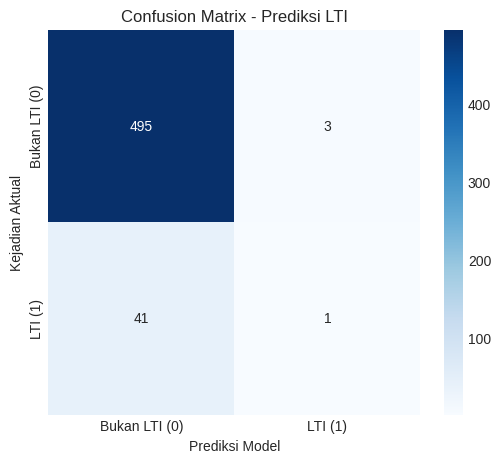

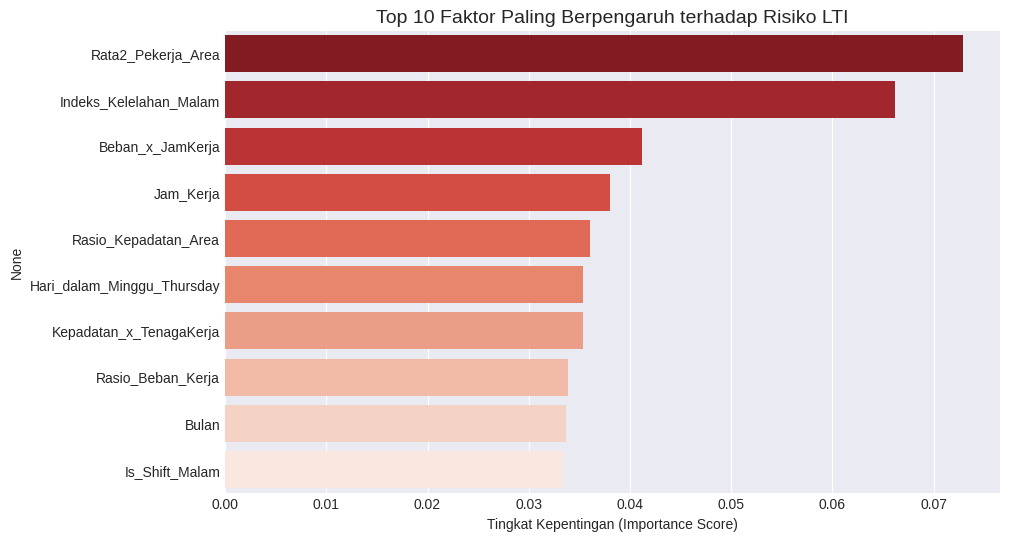

Model berhasil disimpan sebagai 'Model_Prediksi_LTI.pkl'


In [ ]:
# Modul 8: Evaluasi Model
y_pred = rf_model.predict(X_test)

print("\n--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

# 1. Confusion Matrix (Sangat bagus untuk di-screenshot ke PPT)
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan LTI (0)', 'LTI (1)'],
            yticklabels=['Bukan LTI (0)', 'LTI (1)'])
plt.title('Confusion Matrix - Prediksi LTI')
plt.xlabel('Prediksi Model')
plt.ylabel('Kejadian Aktual')
plt.show()

# 2. Feature Importance (Grafik paling penting untuk manajemen)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='Reds_r')
plt.title('Top 10 Faktor Paling Berpengaruh terhadap Risiko LTI', fontsize=14)
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.show()

# Export Model
joblib.dump(rf_model, 'Model_Prediksi_LTI.pkl')
print("Model berhasil disimpan sebagai 'Model_Prediksi_LTI.pkl'")

### Balanced Random Forest Classifier


>>> Melatih Model Balanced Random Forest <<<


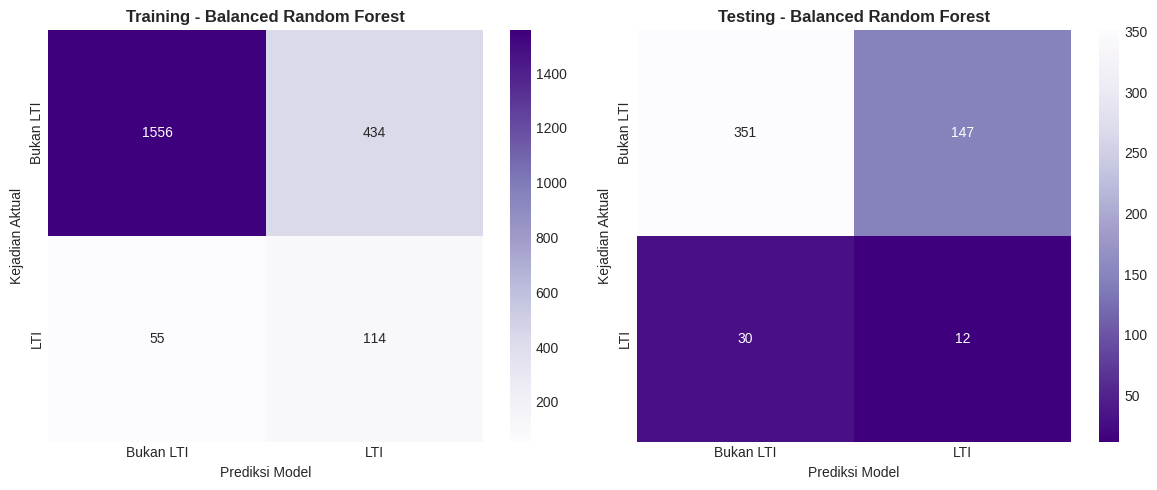


--- Rapor Final Balanced Random Forest ---
              precision    recall  f1-score   support

           0       0.92      0.70      0.80       498
           1       0.08      0.29      0.12        42

    accuracy                           0.67       540
   macro avg       0.50      0.50      0.46       540
weighted avg       0.86      0.67      0.75       540



In [ ]:
# ---------------------------------------------------------
# B. EKSEKUSI BALANCED RANDOM FOREST
# ---------------------------------------------------------
print("\n>>> Melatih Model Balanced Random Forest <<<")

brf_model = BalancedRandomForestClassifier(
    n_estimators=500,        # Membangun 500 pohon keputusan
    max_depth=4,             # Pohon dangkal agar tidak overfitting
    sampling_strategy='all', # Menyeimbangkan semua kelas
    replacement=True,
    random_state=42,
    n_jobs=-1
)

# Latih MURNI pada data training asli (BUKAN SMOTE)
brf_model.fit(X_train, y_train)

# Prediksi
y_pred_train_brf = brf_model.predict(X_train)
y_pred_test_brf = brf_model.predict(X_test)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train, y_pred_train_brf), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - Balanced Random Forest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_brf), annot=True, fmt='d', cmap='Purples_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - Balanced Random Forest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

print(f"\n--- Rapor Final Balanced Random Forest ---")
print(classification_report(y_test, y_pred_test_brf))

### Random Under Sampling


>>> PEMODELAN RANDOM FOREST (RUS) <<<


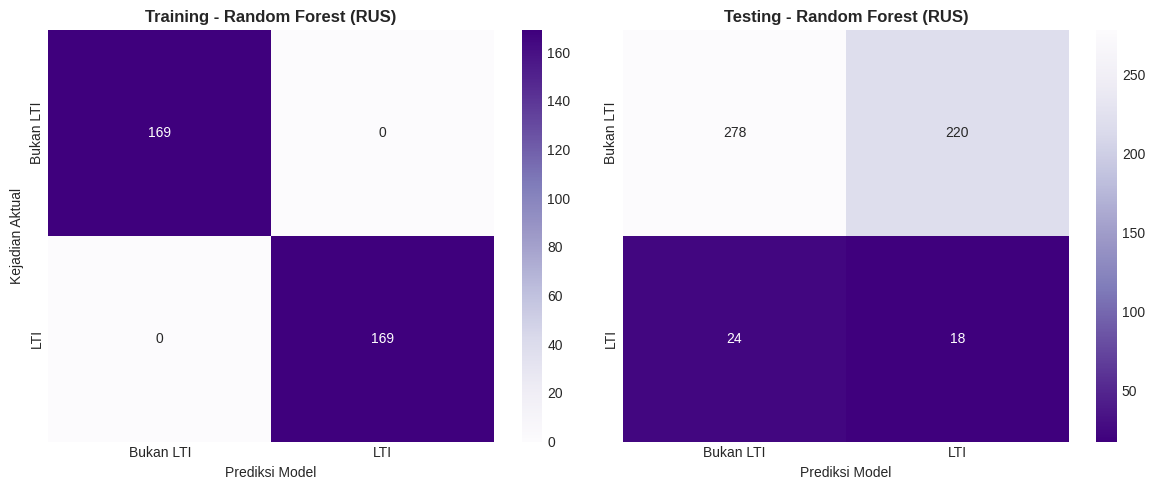

--- Rapor Random Forest (RUS) ---
              precision    recall  f1-score   support

           0       0.92      0.56      0.69       498
           1       0.08      0.43      0.13        42

    accuracy                           0.55       540
   macro avg       0.50      0.49      0.41       540
weighted avg       0.85      0.55      0.65       540

--- Metrik Random Forest (RUS) ---
Akurasi   : 0.5481
Precision : 0.0756
Recall    : 0.4286 (Fokus Utama)
F1-Score  : 0.1286
AUC-ROC   : 0.5013
CV Recall : 0.5219



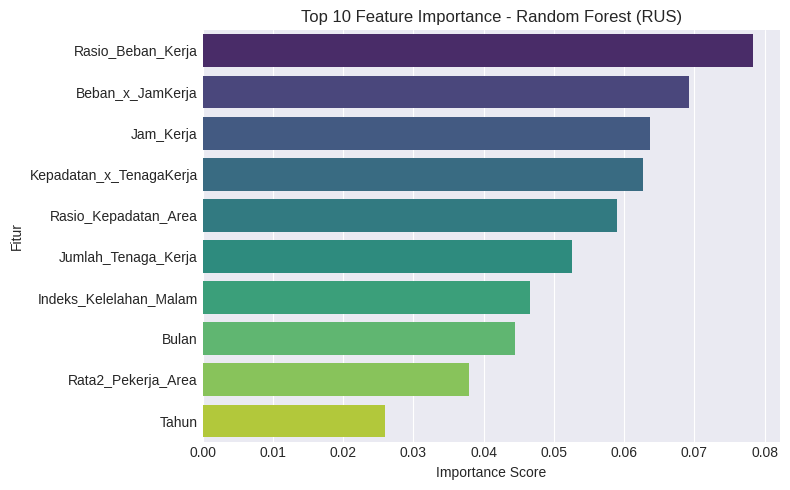

In [ ]:
# ---------------------------------------------------------
# PEMODELAN RANDOM FOREST (UNDERSAMPLING)
# ---------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("\n>>> PEMODELAN RANDOM FOREST (RUS) <<<")
rf_rus = RandomForestClassifier(random_state=42)
rf_rus.fit(X_train_rus, y_train_rus)

# Prediksi
y_pred_train_rf = rf_rus.predict(X_train_rus)
y_pred_test_rf = rf_rus.predict(X_test)

# Matriks Visualisasi (Tema Hijau)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train_rus, y_pred_train_rf), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - Random Forest (RUS)', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_rf), annot=True, fmt='d', cmap='Purples_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - Random Forest (RUS)', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

print("--- Rapor Random Forest (RUS) ---")
print(classification_report(y_test, y_pred_test_rf))

# Evaluasi Model
evaluasi_model('Random Forest (RUS)', rf_rus, X_train_rus, y_train_rus, X_test, y_test)
plot_feature_importance('Random Forest (RUS)', rf_rus.feature_importances_, X_train_rus.columns)

### CUSTOM Threshold

=== EKSPERIMEN RANDOM FOREST (RUS) DENGAN CUSTOM THRESHOLD ===



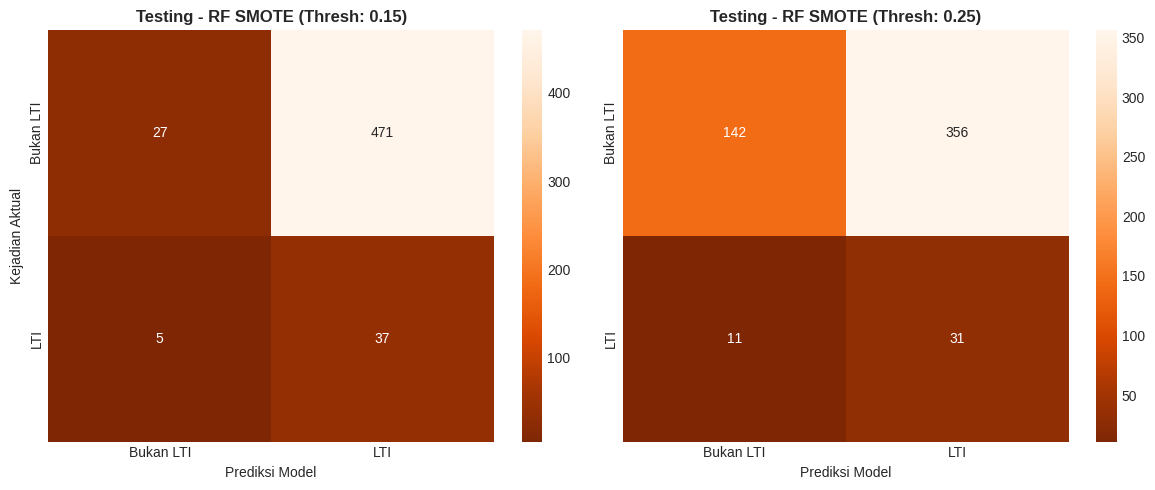


--- Rapor RF SMOTE (Threshold 0.15) ---
              precision    recall  f1-score   support

           0       0.84      0.05      0.10       498
           1       0.07      0.88      0.13        42

    accuracy                           0.12       540
   macro avg       0.46      0.47      0.12       540
weighted avg       0.78      0.12      0.10       540


--- Rapor RF SMOTE (Threshold 0.25) ---
              precision    recall  f1-score   support

           0       0.93      0.29      0.44       498
           1       0.08      0.74      0.14        42

    accuracy                           0.32       540
   macro avg       0.50      0.51      0.29       540
weighted avg       0.86      0.32      0.41       540



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

print("=== EKSPERIMEN RANDOM FOREST (RUS) DENGAN CUSTOM THRESHOLD ===\n")

# 1. Bangun dan Latih Model Random Forest dengan data RUS
# (Menggunakan max_depth yang tidak terlalu dalam agar tetap stabil)
rf_rus_custom = RandomForestClassifier(random_state=42, max_depth=8)
rf_rus_custom.fit(X_train_smote, y_train_smote)

# 2. Ambil Probabilitas HANYA dari data Testing
y_pred_prob_rf = rf_rus_custom.predict_proba(X_test)[:, 1]

# 3. Tentukan dua threshold penengah untuk dibandingkan
threshold_1 = 0.15
threshold_2 = 0.25

# Terapkan custom threshold secara matematis
y_pred_th1 = (y_pred_prob_rf >= threshold_1).astype(int)
y_pred_th2 = (y_pred_prob_rf >= threshold_2).astype(int)

# 4. Siapkan Visualisasi 2 Matriks Berdampingan (Tema Oranye)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Threshold 1 (0.15)
sns.heatmap(confusion_matrix(y_test, y_pred_th1), annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title(f'Testing - RF SMOTE (Thresh: {threshold_1})', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

# Plot Threshold 2 (0.25)
sns.heatmap(confusion_matrix(y_test, y_pred_th2), annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title(f'Testing - RF SMOTE (Thresh: {threshold_2})', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

# 5. Tampilkan Rapor Evaluasi
print(f"\n--- Rapor RF SMOTE (Threshold {threshold_1}) ---")
print(classification_report(y_test, y_pred_th1))

print(f"\n--- Rapor RF SMOTE (Threshold {threshold_2}) ---")
print(classification_report(y_test, y_pred_th2))

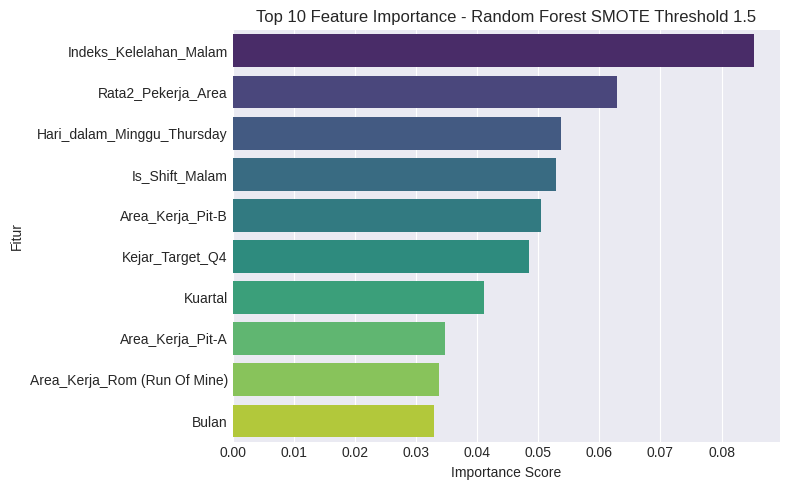

In [ ]:
plot_feature_importance(
    nama_model='Random Forest SMOTE Threshold 1.5',
    importances=rf_rus_custom.feature_importances_,
    fitur_names=X_train_smote.columns
)

>>> SHAP PLOT TOP 5 RANDOM FOREST (TRANSPARAN & TEKS PUTIH) <<<


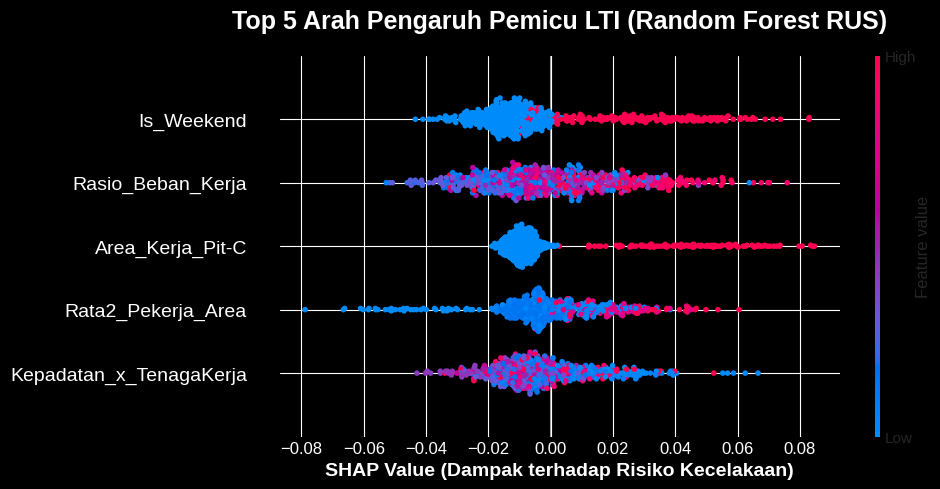

In [ ]:
import shap
import matplotlib.pyplot as plt

print(">>> SHAP PLOT TOP 5 RANDOM FOREST (TRANSPARAN & TEKS PUTIH) <<<")

X_test_shap = X_test.copy()
if hasattr(rf_rus, 'feature_names_in_'):
    X_test_shap.columns = rf_rus.feature_names_in_

explainer_rf = shap.TreeExplainer(rf_rus)
shap_values_rf = explainer_rf.shap_values(X_test_shap)

if isinstance(shap_values_rf, list):
    shap_fix_rf = shap_values_rf[1]
elif len(shap_values_rf.shape) == 3:
    shap_fix_rf = shap_values_rf[:, :, 1]
else:
    shap_fix_rf = shap_values_rf

fig = plt.figure(figsize=(10, 5), facecolor='black')

shap.summary_plot(
    shap_fix_rf,
    X_test_shap,
    plot_size=(10, 5),
    max_display=5,
    show=False
)

ax = plt.gca()
ax.set_facecolor('black')

plt.title("Top 5 Arah Pengaruh Pemicu LTI (Random Forest RUS)", color='white', fontsize=18, fontweight='bold', pad=20)
plt.xlabel("SHAP Value (Dampak terhadap Risiko Kecelakaan)", color='white', fontsize=14, fontweight='bold')

ax.tick_params(axis='x', colors='white', labelsize=12)
ax.tick_params(axis='y', colors='white', labelsize=14)

for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()

## CatBoost

### SMOTE


>>> 1. PEMODELAN CATBOOST <<<
--- Metrik CatBoost ---
Akurasi   : 0.9093
Precision : 0.1111
Recall    : 0.0238 (Fokus Utama)
F1-Score  : 0.0392
AUC-ROC   : 0.5139
CV Recall : 0.9176



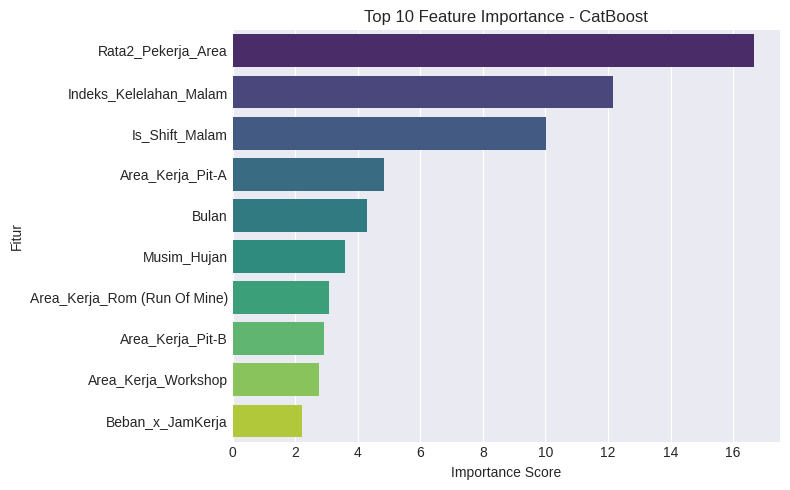

In [ ]:
print("\n>>> 1. PEMODELAN CATBOOST <<<")
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train_smote, y_train_smote)

evaluasi_model('CatBoost', cat_model, X_train_smote, y_train_smote, X_test, y_test)
plot_feature_importance('CatBoost', cat_model.feature_importances_, X.columns)

### Tuning SMOTE

In [ ]:
from sklearn.model_selection import GridSearchCV

# ==========================================
# MODUL 7: HYPERPARAMETER TUNING SEDERHANA
# ==========================================
print("="*50)
print("PROSES HYPERPARAMETER TUNING SEDERHANA")
print("="*50)

# ---------------------------------------------------------
# 1. TUNING CATBOOST
# ---------------------------------------------------------
print("\n>>> Memulai Tuning CatBoost (Mohon tunggu sebentar...) <<<")
# Grid parameter sederhana untuk CatBoost
param_grid_cat = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 10],
    'l2_leaf_reg': [5, 10, 20]
}

cat_base = CatBoostClassifier(random_state=42, verbose=0)
grid_cat = GridSearchCV(estimator=cat_base, param_grid=param_grid_cat,
                        cv=3, scoring='recall', n_jobs=-1)
grid_cat.fit(X_train_smote, y_train_smote)

cat_best = grid_cat.best_estimator_
print(f"Parameter Terbaik CatBoost: {grid_cat.best_params_}")

PROSES HYPERPARAMETER TUNING SEDERHANA

>>> Memulai Tuning CatBoost (Mohon tunggu sebentar...) <<<
Parameter Terbaik CatBoost: {'depth': 5, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.1}


--- CLASSIFICATION REPORT (DATA TRAINING) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1990
           1       1.00      0.97      0.98      1990

    accuracy                           0.98      3980
   macro avg       0.98      0.98      0.98      3980
weighted avg       0.98      0.98      0.98      3980


--- CLASSIFICATION REPORT (DATA TESTING) ---
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       498
           1       0.14      0.02      0.04        42

    accuracy                           0.91       540
   macro avg       0.53      0.51      0.50       540
weighted avg       0.86      0.91      0.88       540



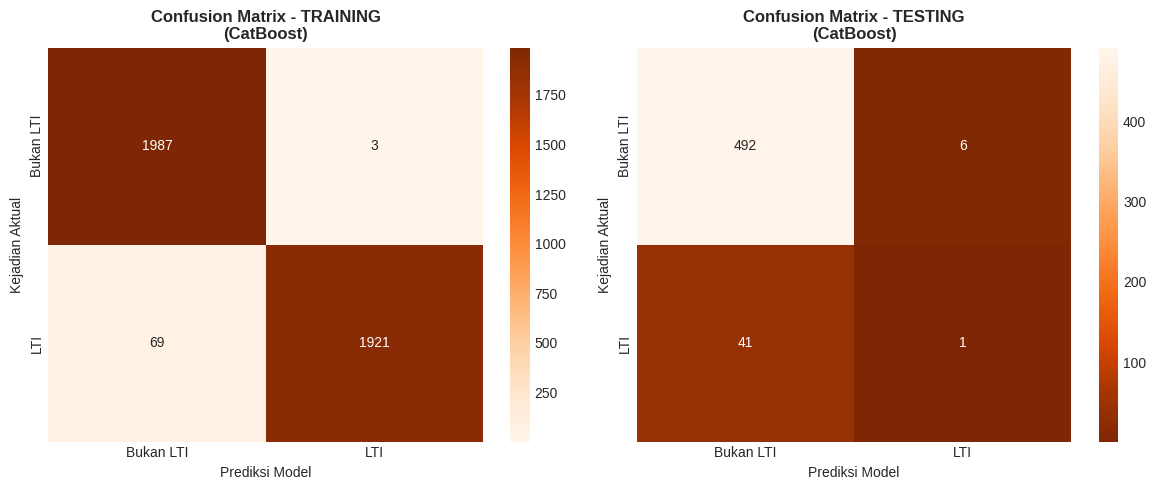

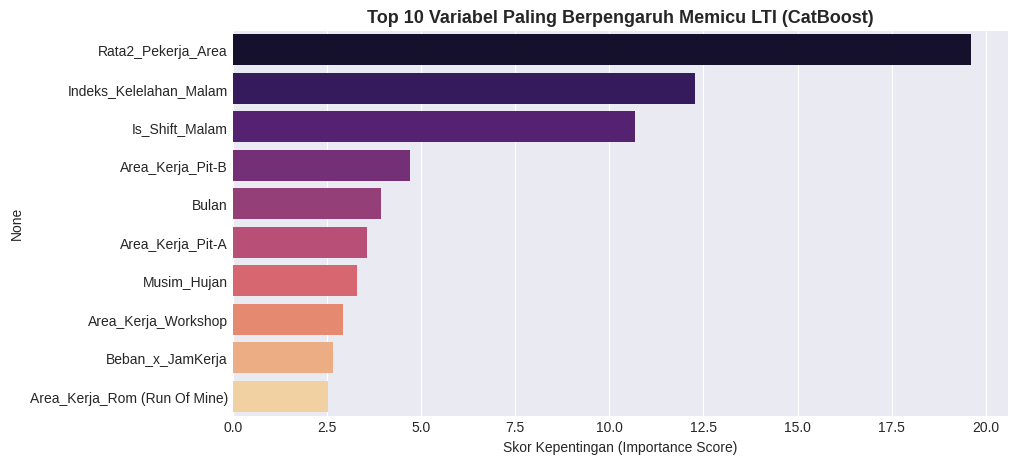

In [ ]:
# 1. Prediksi pada data Training dan Testing
y_pred_train_cat = cat_best.predict(X_train_smote)
y_pred_test_cat = cat_best.predict(X_test)

# 2. Cetak Classification Report
print("--- CLASSIFICATION REPORT (DATA TRAINING) ---")
print(classification_report(y_train_smote, y_pred_train_cat))
print("\n--- CLASSIFICATION REPORT (DATA TESTING) ---")
print(classification_report(y_test, y_pred_test_cat))

# 3. Visualisasi Confusion Matrix Kiri-Kanan (Train vs Test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrix Training (Kiri)
cm_train_cat = confusion_matrix(y_train_smote, y_pred_train_cat)
sns.heatmap(cm_train_cat, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Confusion Matrix - TRAINING\n(CatBoost)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

# Matrix Testing (Kanan)
cm_test_cat = confusion_matrix(y_test, y_pred_test_cat)
sns.heatmap(cm_test_cat, annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Confusion Matrix - TESTING\n(CatBoost)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# 4. Feature Importance
feat_imp_cat = pd.Series(cat_best.feature_importances_, index=X_train_smote.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_cat.values, y=feat_imp_cat.index, palette='magma')
plt.title('Top 10 Variabel Paling Berpengaruh Memicu LTI (CatBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Skor Kepentingan (Importance Score)')
plt.show()

### Tuning Class Weight

In [ ]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

# ==========================================
# MODUL 7: REVISI HYPERPARAMETER TUNING CATBOOST
# ==========================================
print("="*50)
print("PROSES HYPERPARAMETER TUNING (ANTI-OVERFITTING)")
print("="*50)

print("\n>>> Memulai Tuning CatBoost (Menggunakan Data Asli + Class Weight) <<<")

# Grid parameter difokuskan pada Regularisasi untuk mencekik model agar tidak menghafal
param_grid_cat = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 10],
    'l2_leaf_reg': [5, 10, 20]             # Penalti L2 untuk memangkas bobot fitur yang terlalu dominan
}

# Inisialisasi model menggunakan senjata bawaan pengganti SMOTE
cat_base = CatBoostClassifier(
    auto_class_weights='Balanced', # Otomatis melipatgandakan penalti jika salah tebak LTI
    random_state=42,
    verbose=0
)

# Cross Validation
grid_cat = GridSearchCV(
    estimator=cat_base,
    param_grid=param_grid_cat,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

# PERHATIKAN: Eksekusi model dilakukan murni pada data asli, BUKAN pada data SMOTE
grid_cat.fit(X_train, y_train)

cat_best = grid_cat.best_estimator_
print(f"Parameter Terbaik CatBoost: {grid_cat.best_params_}")

PROSES HYPERPARAMETER TUNING (ANTI-OVERFITTING)

>>> Memulai Tuning CatBoost (Menggunakan Data Asli + Class Weight) <<<
Parameter Terbaik CatBoost: {'depth': 3, 'iterations': 100, 'l2_leaf_reg': 20, 'learning_rate': 0.05}


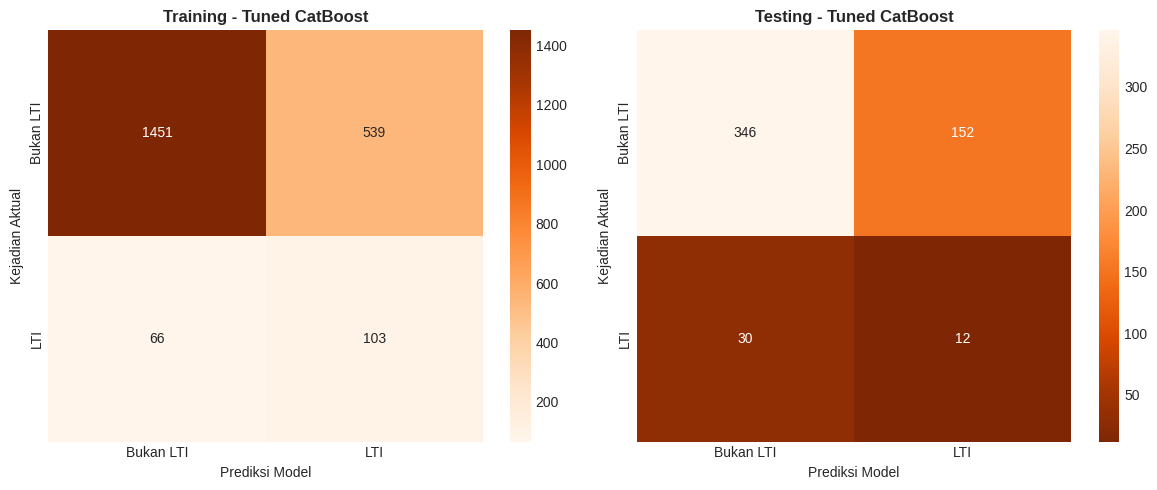


--- Rapor Final CatBoost (Tuned) ---
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       498
           1       0.07      0.29      0.12        42

    accuracy                           0.66       540
   macro avg       0.50      0.49      0.45       540
weighted avg       0.85      0.66      0.74       540


>>> Menampilkan Top 10 Faktor Paling Berpengaruh <<<


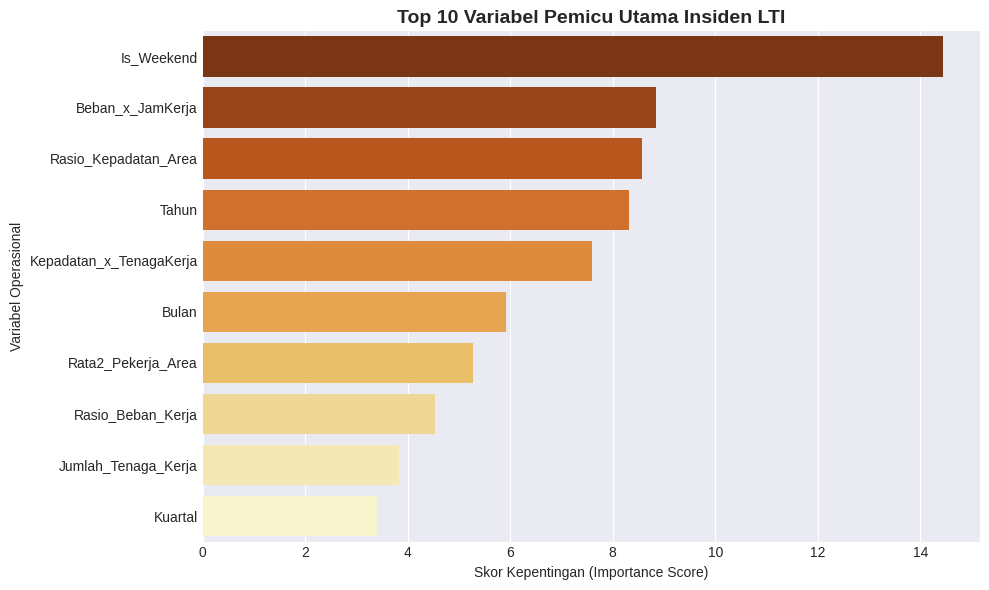

In [ ]:
# 1. Pastikan nama kolom sinkron
X_train.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

# 2. Masukkan parameter hasil GridSearch
cat_final_tuned = CatBoostClassifier(
    auto_class_weights='Balanced',
    depth=3,
    iterations=100,
    l2_leaf_reg=20,
    learning_rate=0.01,
    random_state=42,
    verbose=0
)

# 3. Latih model
cat_final_tuned.fit(X_train, y_train)

# 4. Prediksi (menggunakan threshold bawaan model yang sudah di-balance)
y_pred_train = cat_final_tuned.predict(X_train)
y_pred_test = cat_final_tuned.predict(X_test)

# 5. Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - Tuned CatBoost', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - Tuned CatBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# 6. Tampilkan Rapor Baru
print(f"\n--- Rapor Final CatBoost (Tuned) ---")
print(classification_report(y_test, y_pred_test))

# ==========================================
# 7. VISUALISASI FEATURE IMPORTANCE
# ==========================================
print("\n>>> Menampilkan Top 10 Faktor Paling Berpengaruh <<<")

# Ekstrak nilai penting dari model dan pasangkan dengan nama kolom
feat_imp = pd.Series(cat_final_tuned.feature_importances_, index=X_train.columns)

# Ambil 10 teratas dan urutkan
feat_imp_top10 = feat_imp.sort_values(ascending=False).head(10)

# Buat visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_top10.values, y=feat_imp_top10.index, palette='YlOrBr_r')
plt.title('Top 10 Variabel Pemicu Utama Insiden LTI', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan (Importance Score)')
plt.ylabel('Variabel Operasional')
plt.tight_layout()
plt.show()

### Random Under Sampling


>>> PEMODELAN CATBOOST (RUS) <<<


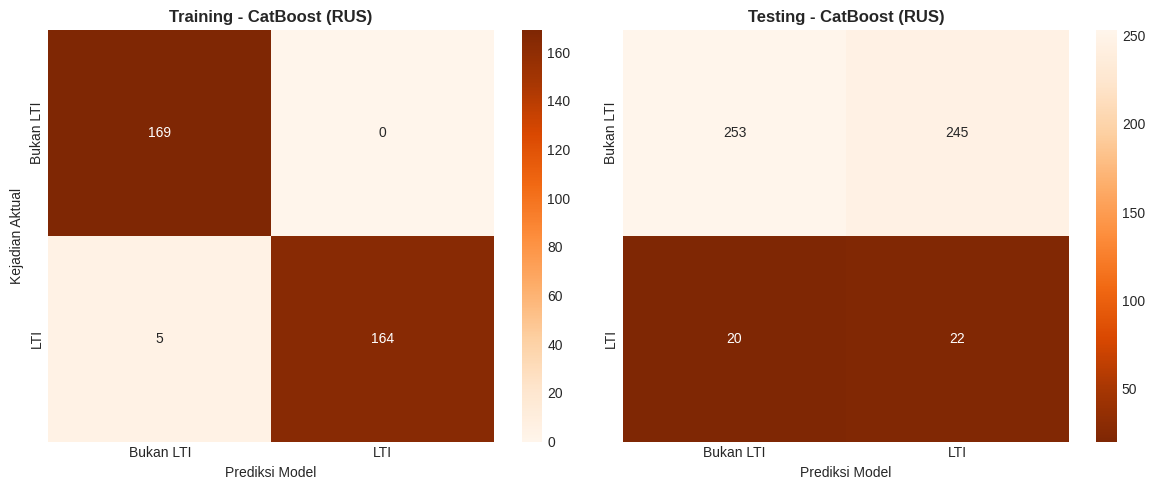

--- Rapor CatBoost (RUS) ---
              precision    recall  f1-score   support

           0       0.93      0.51      0.66       498
           1       0.08      0.52      0.14        42

    accuracy                           0.51       540
   macro avg       0.50      0.52      0.40       540
weighted avg       0.86      0.51      0.62       540

--- Metrik CatBoost (RUS) ---
Akurasi   : 0.5093
Precision : 0.0824
Recall    : 0.5238 (Fokus Utama)
F1-Score  : 0.1424
AUC-ROC   : 0.5168
CV Recall : 0.5276



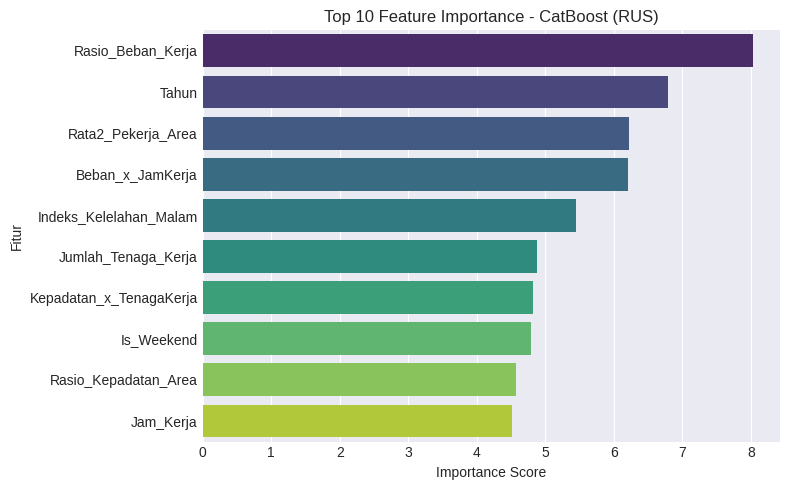

In [ ]:
# 1. Pastikan nama kolom sinkron
X_train_rus.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

# ---------------------------------------------------------
# PEMODELAN CATBOOST (UNDERSAMPLING)
# ---------------------------------------------------------
from catboost import CatBoostClassifier

print("\n>>> PEMODELAN CATBOOST (RUS) <<<")
cat_rus = CatBoostClassifier(random_state=42, verbose=0)
cat_rus.fit(X_train_rus, y_train_rus)

# Prediksi
y_pred_train_cat = cat_rus.predict(X_train_rus)
y_pred_test_cat = cat_rus.predict(X_test)

# Matriks Visualisasi (Tema Ungu)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train_rus, y_pred_train_cat), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - CatBoost (RUS)', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_cat), annot=True, fmt='d', cmap='Oranges_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - CatBoost (RUS)', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

print("--- Rapor CatBoost (RUS) ---")
print(classification_report(y_test, y_pred_test_cat))

# Evaluasi Model
evaluasi_model('CatBoost (RUS)', cat_rus, X_train_rus, y_train_rus, X_test, y_test)
plot_feature_importance('CatBoost (RUS)', cat_rus.feature_importances_, X_train_rus.columns)

## LightGBM

### SMOTE


>>> 2. PEMODELAN LIGHTGBM <<<
--- Metrik LightGBM ---
Akurasi   : 0.9148
Precision : 0.1667
Recall    : 0.0238 (Fokus Utama)
F1-Score  : 0.0417
AUC-ROC   : 0.5015
CV Recall : 0.9181



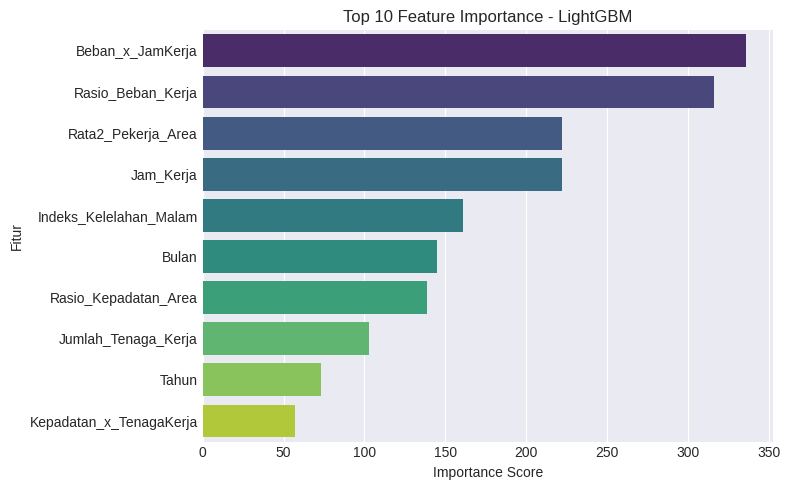

In [ ]:
# ---------------------------------------------------------
# 2. LIGHTGBM
# ---------------------------------------------------------
print("\n>>> 2. PEMODELAN LIGHTGBM <<<")
lgbm_model = LGBMClassifier(random_state=42, verbose=-1)
lgbm_model.fit(X_train_smote, y_train_smote)

evaluasi_model('LightGBM', lgbm_model, X_train_smote, y_train_smote, X_test, y_test)
plot_feature_importance('LightGBM', lgbm_model.feature_importances_, X.columns)

### Tuning SMOTE

In [ ]:
# ---------------------------------------------------------
# 2. TUNING LIGHTGBM
# ---------------------------------------------------------
print("\n>>> Memulai Tuning LightGBM <<<")
# Grid parameter sederhana untuk LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],            # Dangkal
    'min_child_samples': [10, 20],  # Mencegah pembuatan aturan untuk data yang terlalu sedikit
    'reg_lambda': [3, 5]           # Penalti L2

}

lgbm_base = LGBMClassifier(random_state=42, verbose=-1)
grid_lgbm = GridSearchCV(estimator=lgbm_base, param_grid=param_grid_lgbm,
                         cv=3, scoring='recall', n_jobs=-1)
grid_lgbm.fit(X_train_smote, y_train_smote)

lgbm_best = grid_lgbm.best_estimator_
print(f"Parameter Terbaik LightGBM: {grid_lgbm.best_params_}")


>>> Memulai Tuning LightGBM <<<
Parameter Terbaik LightGBM: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 200, 'reg_lambda': 3}


--- CLASSIFICATION REPORT (DATA TRAINING) ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1990
           1       1.00      0.94      0.97      1990

    accuracy                           0.97      3980
   macro avg       0.97      0.97      0.97      3980
weighted avg       0.97      0.97      0.97      3980


--- CLASSIFICATION REPORT (DATA TESTING) ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       498
           1       0.33      0.05      0.08        42

    accuracy                           0.92       540
   macro avg       0.63      0.52      0.52       540
weighted avg       0.88      0.92      0.89       540



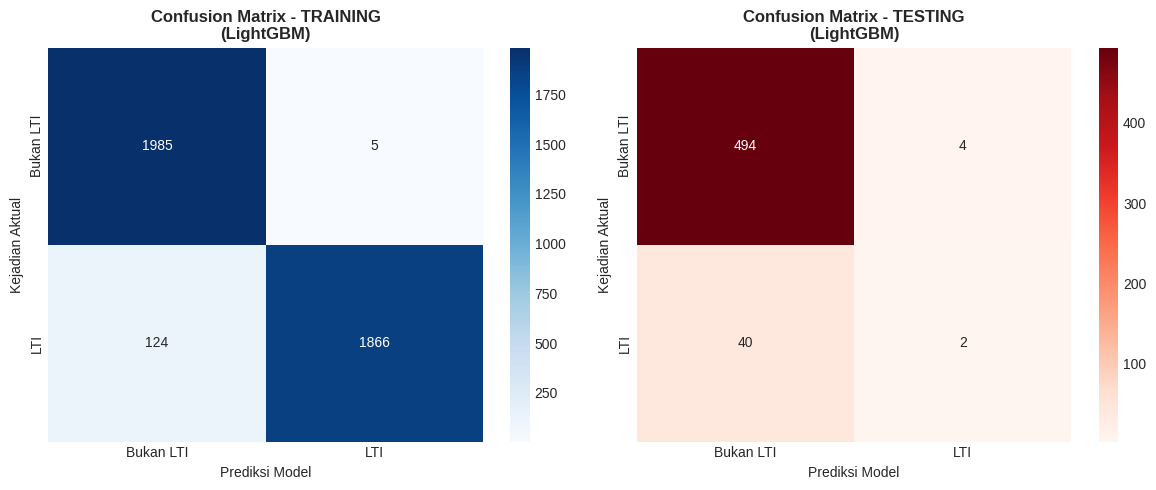

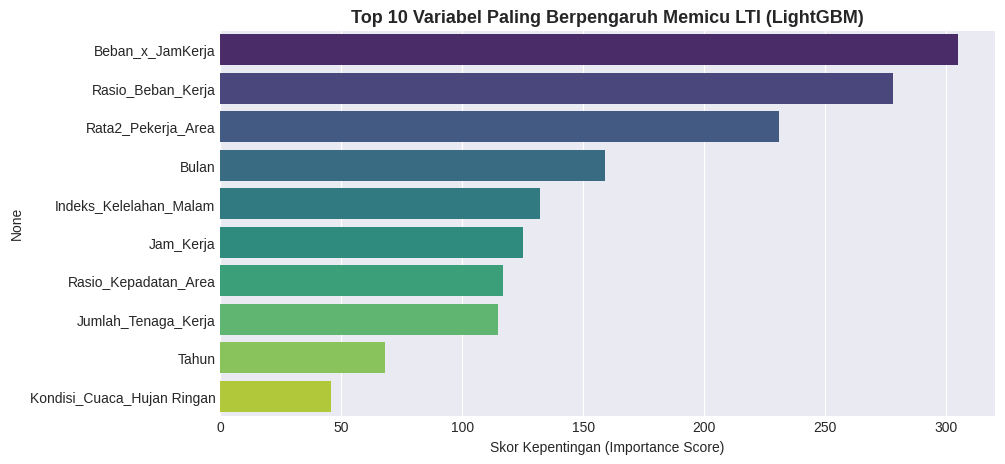

In [ ]:
# 1. Prediksi pada data Training dan Testing
y_pred_train_lgbm = lgbm_best.predict(X_train_smote)
y_pred_test_lgbm = lgbm_best.predict(X_test)

# 2. Cetak Classification Report
print("--- CLASSIFICATION REPORT (DATA TRAINING) ---")
print(classification_report(y_train_smote, y_pred_train_lgbm))
print("\n--- CLASSIFICATION REPORT (DATA TESTING) ---")
print(classification_report(y_test, y_pred_test_lgbm))

# 3. Visualisasi Confusion Matrix Kiri-Kanan (Train vs Test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrix Training (Kiri)
cm_train_lgbm = confusion_matrix(y_train_smote, y_pred_train_lgbm)
sns.heatmap(cm_train_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Confusion Matrix - TRAINING\n(LightGBM)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

# Matrix Testing (Kanan)
cm_test_lgbm = confusion_matrix(y_test, y_pred_test_lgbm)
sns.heatmap(cm_test_lgbm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Confusion Matrix - TESTING\n(LightGBM)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# 4. Feature Importance
feat_imp_lgbm = pd.Series(lgbm_best.feature_importances_, index=X_train_smote.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_lgbm.values, y=feat_imp_lgbm.index, palette='viridis')
plt.title('Top 10 Variabel Paling Berpengaruh Memicu LTI (LightGBM)', fontsize=13, fontweight='bold')
plt.xlabel('Skor Kepentingan (Importance Score)')
plt.show()

### Tuning Class Weight Balance

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

print("\n>>> Memulai Tuning LightGBM (Anti-Overfitting) <<<")

# Parameter regularisasi untuk mencekik model agar tidak menghafal
param_grid_lgbm = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],            # Dangkal
    'min_child_samples': [10, 20],  # Mencegah pembuatan aturan untuk data yang terlalu sedikit
    'reg_lambda': [3, 5]           # Penalti L2
}

# Gunakan class_weight='balanced' sebagai ganti SMOTE
lgbm_base = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

grid_lgbm = GridSearchCV(estimator=lgbm_base, param_grid=param_grid_lgbm,
                         cv=3, scoring='recall', n_jobs=-1)

# Latih MURNI pada data asli (X_train)
grid_lgbm.fit(X_train, y_train)
lgbm_best = grid_lgbm.best_estimator_
print(f"Parameter Terbaik LightGBM: {grid_lgbm.best_params_}")


>>> Memulai Tuning LightGBM (Anti-Overfitting) <<<
Parameter Terbaik LightGBM: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_samples': 20, 'n_estimators': 200, 'reg_lambda': 5}


EVALUASI FINAL LIGHTGBM (TUNED)


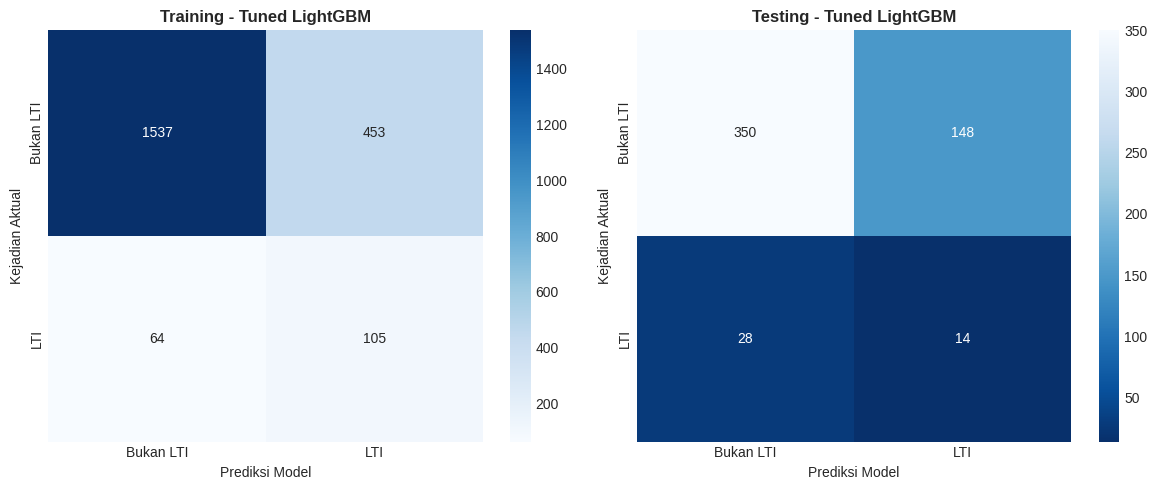


--- Rapor Final LightGBM (Tuned) ---
              precision    recall  f1-score   support

           0       0.93      0.70      0.80       498
           1       0.09      0.33      0.14        42

    accuracy                           0.67       540
   macro avg       0.51      0.52      0.47       540
weighted avg       0.86      0.67      0.75       540



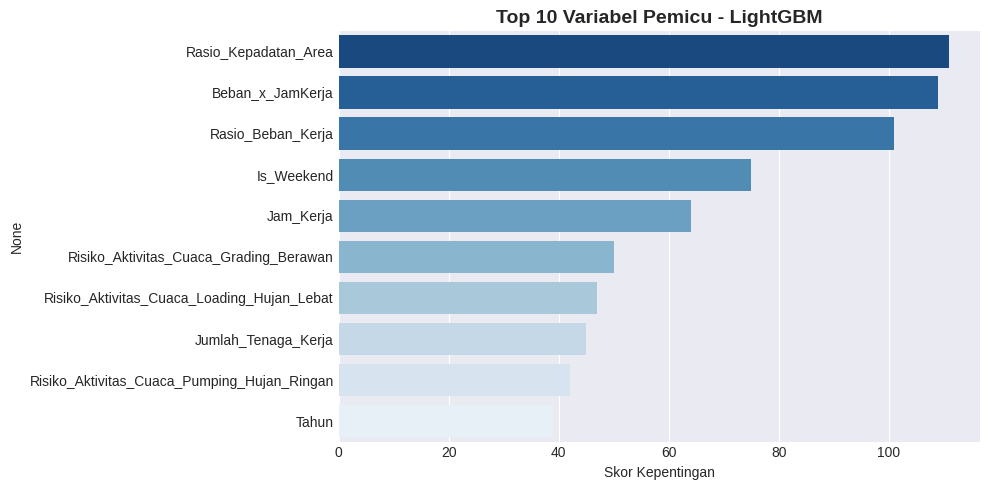

In [ ]:
# ==========================================
# 8. EVALUASI FINAL LIGHTGBM DENGAN PARAMETER TERBAIK
# ==========================================
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

print("="*50)
print("EVALUASI FINAL LIGHTGBM (TUNED)")
print("="*50)

# 1. Inisialisasi LightGBM dengan parameter terbaik + class_weight balanced
lgbm_final = LGBMClassifier(
    class_weight='balanced',
    learning_rate=0.01,
    max_depth=3,
    min_child_samples=10,
    n_estimators=200,
    reg_lambda=5,
    random_state=42,
    verbose=-1
)

# 2. Latih model pada data asli
lgbm_final.fit(X_train, y_train)

# 3. Prediksi
y_pred_train_lgbm = lgbm_final.predict(X_train)
y_pred_test_lgbm = lgbm_final.predict(X_test)

# 4. Visualisasi Confusion Matrix (Tema Biru)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train, y_pred_train_lgbm), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - Tuned LightGBM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_lgbm), annot=True, fmt='d', cmap='Blues_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - Tuned LightGBM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# 5. Tampilkan Rapor Baru LightGBM
print(f"\n--- Rapor Final LightGBM (Tuned) ---")
print(classification_report(y_test, y_pred_test_lgbm))

# 6. Feature Importance LightGBM
feat_imp_lgbm = pd.Series(lgbm_final.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_lgbm.values, y=feat_imp_lgbm.index, palette='Blues_r')
plt.title('Top 10 Variabel Pemicu - LightGBM', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan')
plt.tight_layout()
plt.show()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print("\n" + "="*50)
print("2. STRATIFIED CROSS-VALIDATION (TUNED LIGHTGBM)")
print("="*50)

# 1. Buat model KHUSUS CV menggunakan Parameter Hasil Tuning + Class Weight
lgbm_cv_tuned = LGBMClassifier(
    class_weight='balanced', # Wajib ada agar tidak tebak 0
    learning_rate=0.01,      # Hasil tuning
    max_depth=3,             # Hasil tuning
    min_child_samples=10,    # Hasil tuning
    n_estimators=200,        # Hasil tuning
    reg_lambda=5,            # Hasil tuning
    random_state=42,
    verbose=-1
)

# 2. Inisialisasi K-Fold dengan 5 lipatan
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Jalankan Cross-Validation dengan metrik 'recall'
cv_scores = cross_val_score(lgbm_cv_tuned, X_train, y_train, cv=skf, scoring='recall')

print(f"Skor Recall pada tiap Fold : {cv_scores}")
print(f"Rata-rata Recall (CV)      : {np.mean(cv_scores):.4f}")
print(f"Standar Deviasi (CV)       : {np.std(cv_scores):.4f}")

# 4. Narasi Otomatis Evaluasi
rata2_recall = np.mean(cv_scores)

if rata2_recall == 0:
    print("\n🚨 WARNING: Recall 0%. Model gagal total mengenali kelas minoritas (LTI).")
elif np.std(cv_scores) < 0.20 and rata2_recall > 0.10:
    print("\n✅ Kesimpulan Uji Stabilitas:")
    print("Model terbukti cukup STABIL. Mengingat sampel LTI per fold sangat kecil (sekitar 6-8 kejadian),")
    print("adanya variansi adalah wajar, namun model tetap konsisten mengenali pola LTI di setiap lipatan data.")
else:
    print("\n⚠️ Kesimpulan Uji Stabilitas:")
    print("Terdapat variansi skor yang cukup tinggi antar-fold.")
    print("Fenomena ini sangat wajar pada data ekstrem imbalanced, di mana satu lipatan mungkin mendapat")
    print("insiden LTI yang polanya lebih sulit ditebak dibanding lipatan lainnya.")


2. STRATIFIED CROSS-VALIDATION (TUNED LIGHTGBM)
Skor Recall pada tiap Fold : [0.29411765 0.32352941 0.35294118 0.44117647 0.33333333]
Rata-rata Recall (CV)      : 0.3490
Standar Deviasi (CV)       : 0.0498

✅ Kesimpulan Uji Stabilitas:
Model terbukti cukup STABIL. Mengingat sampel LTI per fold sangat kecil (sekitar 6-8 kejadian),
adanya variansi adalah wajar, namun model tetap konsisten mengenali pola LTI di setiap lipatan data.


### Random Under Sampling Tuning

EKSPERIMEN FINAL: UNDERSAMPLING + ADVANCED FEATURES

>>> Melakukan Random Under-Sampling pada Data Latih <<<
Distribusi Kelas SEBELUM RUS:
LTI
0    1990
1     169
Name: count, dtype: int64
Distribusi Kelas SETELAH RUS:
LTI
0    169
1    169
Name: count, dtype: int64

>>> Melatih LightGBM pada Data Undersampled <<<


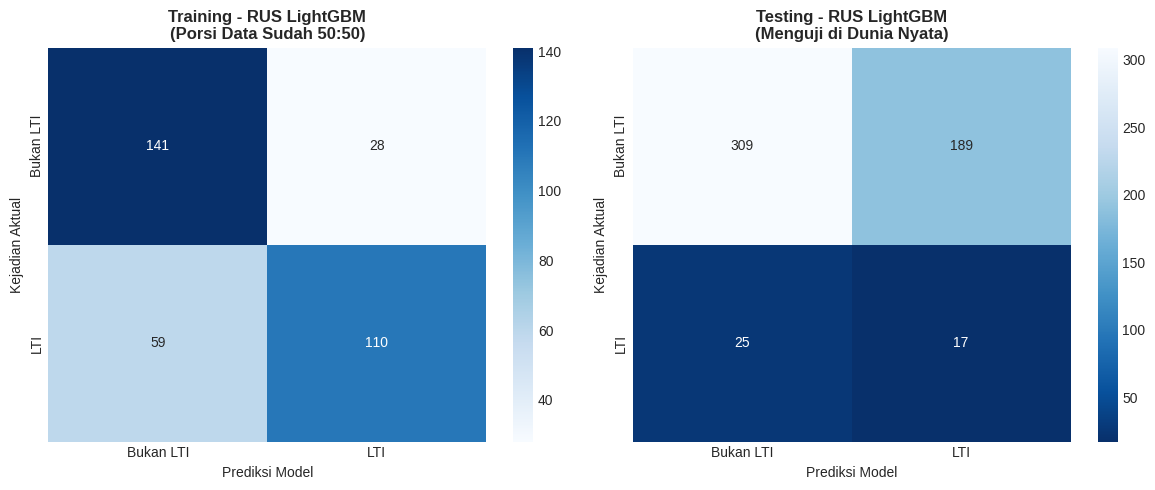


--- Rapor Final RUS LightGBM ---
              precision    recall  f1-score   support

           0       0.93      0.62      0.74       498
           1       0.08      0.40      0.14        42

    accuracy                           0.60       540
   macro avg       0.50      0.51      0.44       540
weighted avg       0.86      0.60      0.70       540

--- Metrik LightGBM (RUS) ---
Akurasi   : 0.6037
Precision : 0.0825
Recall    : 0.4048 (Fokus Utama)
F1-Score  : 0.1371
AUC-ROC   : 0.5200
CV Recall : 0.4854



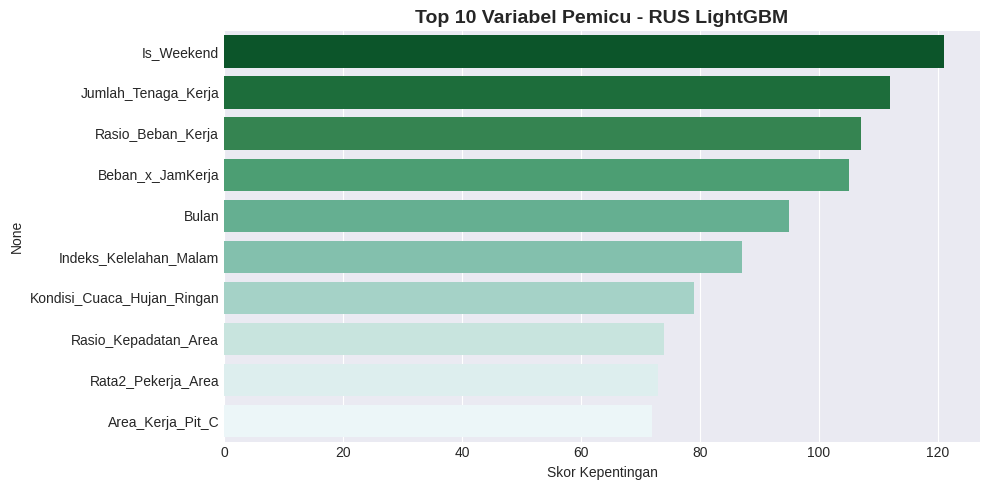

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("="*50)
print("EKSPERIMEN FINAL: UNDERSAMPLING + ADVANCED FEATURES")
print("="*50)

# ---------------------------------------------------------
# B. PENANGANAN IMBALANCE: RANDOM UNDER-SAMPLING (RUS)
# ---------------------------------------------------------
print("\n>>> Melakukan Random Under-Sampling pada Data Latih <<<")

# Memotong data mayoritas (Bukan LTI) agar seimbang dengan LTI
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Distribusi Kelas SEBELUM RUS:\n{y_train.value_counts()}")
print(f"Distribusi Kelas SETELAH RUS:\n{y_train_rus.value_counts()}")

# ---------------------------------------------------------
# C. PELATIHAN LIGHTGBM PADA DATA UNDERSAMPLED
# ---------------------------------------------------------
print("\n>>> Melatih LightGBM pada Data Undersampled <<<")

# Kita tidak butuh class_weight='balanced' lagi karena data sudah 50:50!
lgbm_rus = LGBMClassifier(
    learning_rate=0.01,
    max_depth=3,
    min_child_samples=5, # Diturunkan karena sisa sampel data latih kita jadi sangat sedikit
    n_estimators=200,
    reg_lambda=5,
    random_state=42,
    verbose=-1
)

# Latih pada data yang sudah di-Undersampling
lgbm_rus.fit(X_train_rus, y_train_rus)

# Prediksi pada X_test asli (Tidak boleh di-undersample agar evaluasi tetap jujur di dunia nyata)
y_pred_train_rus = lgbm_rus.predict(X_train_rus)
y_pred_test_rus = lgbm_rus.predict(X_test)

# ---------------------------------------------------------
# D. VISUALISASI HASIL
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Menggunakan cmap='BuGn' (Blue-Green) yang standar di Matplotlib
sns.heatmap(confusion_matrix(y_train_rus, y_pred_train_rus), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - RUS LightGBM\n(Porsi Data Sudah 50:50)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_rus), annot=True, fmt='d', cmap='Blues_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - RUS LightGBM\n(Menguji di Dunia Nyata)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# Rapor Akhir
print(f"\n--- Rapor Final RUS LightGBM ---")
print(classification_report(y_test, y_pred_test_rus))
evaluasi_model('LightGBM (RUS)', lgbm_rus, X_train_rus, y_train_rus, X_test, y_test)

# Feature Importance Lanjutan
feat_imp_rus = pd.Series(lgbm_rus.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_rus.values, y=feat_imp_rus.index, palette='BuGn_r')
plt.title('Top 10 Variabel Pemicu - RUS LightGBM', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan')
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print("\n" + "="*50)
print("3. STRATIFIED CROSS-VALIDATION (RUS LIGHTGBM PAKE PIPELINE)")
print("="*50)

# 1. Definisikan langkah-langkah dalam Pipeline
# Pipeline memastikan RUS HANYA memotong data di porsi training setiap fold
rus_step = RandomUnderSampler(random_state=42)

# Gunakan parameter hasil tuning yang dikombinasikan dengan kebutuhan RUS
lgbm_rus_step = LGBMClassifier(
    learning_rate=0.01,
    max_depth=3,
    min_child_samples=5, # Kita pakai 5 karena setelah di-RUS, datanya jadi sedikit banget
    n_estimators=200,
    reg_lambda=5,
    random_state=42,
    verbose=-1
)

# Gabungkan menjadi satu mesin (Pipeline)
pipeline_rus = ImbPipeline(steps=[('rus', rus_step), ('model', lgbm_rus_step)])

# 2. Inisialisasi K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Jalankan CV menggunakan X_train dan y_train ASLI (biar Pipeline yang ngurus potong-potongnya)
cv_scores_rus = cross_val_score(pipeline_rus, X_train, y_train, cv=skf, scoring='recall')

print(f"Skor Recall tiap Fold : {cv_scores_rus}")
print(f"Rata-rata Recall (CV) : {np.mean(cv_scores_rus):.4f}")
print(f"Standar Deviasi (CV)  : {np.std(cv_scores_rus):.4f}")

# Narasi Kesimpulan
if np.mean(cv_scores_rus) > 0.35:
    print("\n✅ Validasi Juara:")
    print("Model RUS LightGBM terbukti lebih sensitif (Recall lebih tinggi) dan stabil di dunia nyata.")
else:
    print("\n⚠️ Catatan Evaluasi:")
    print("Meskipun diuji secara ketat, performa model bergantung pada lipatan data tertentu.")


3. STRATIFIED CROSS-VALIDATION (RUS LIGHTGBM PAKE PIPELINE)
Skor Recall tiap Fold : [0.29411765 0.44117647 0.70588235 0.47058824 0.42424242]
Rata-rata Recall (CV) : 0.4672
Standar Deviasi (CV)  : 0.1338

✅ Validasi Juara:
Model RUS LightGBM terbukti lebih sensitif (Recall lebih tinggi) dan stabil di dunia nyata.


### RUS


>>> PEMODELAN LIGHTGBM (RUS - DEFAULT) <<<
--- Rapor LightGBM (RUS Default) ---
              precision    recall  f1-score   support

           0       0.92      0.50      0.65       498
           1       0.07      0.45      0.12        42

    accuracy                           0.50       540
   macro avg       0.49      0.48      0.39       540
weighted avg       0.85      0.50      0.61       540

--- Metrik LightGBM (RUS) ---
Akurasi   : 0.5000
Precision : 0.0714
Recall    : 0.4524 (Fokus Utama)
F1-Score  : 0.1234
AUC-ROC   : 0.4754
CV Recall : 0.5041



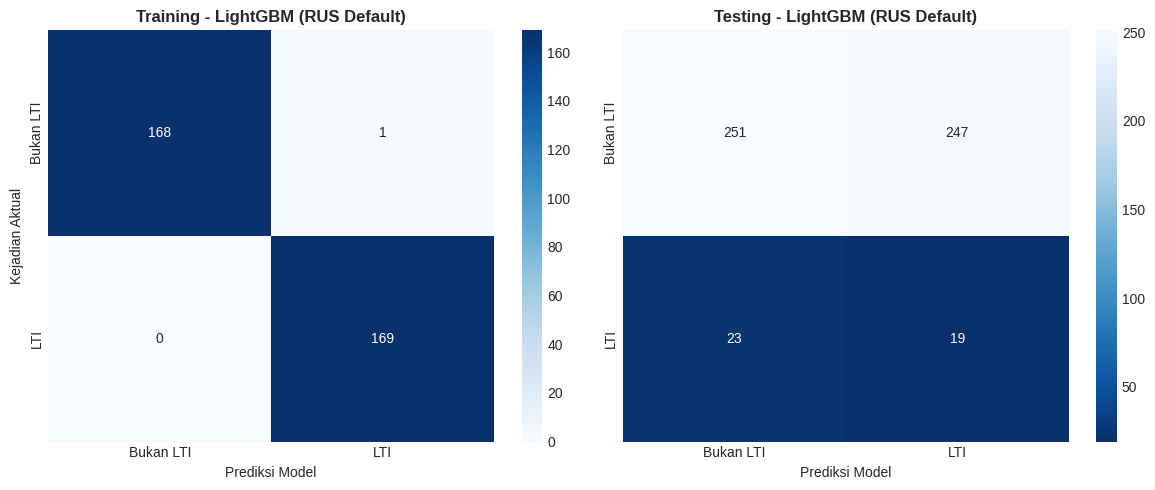

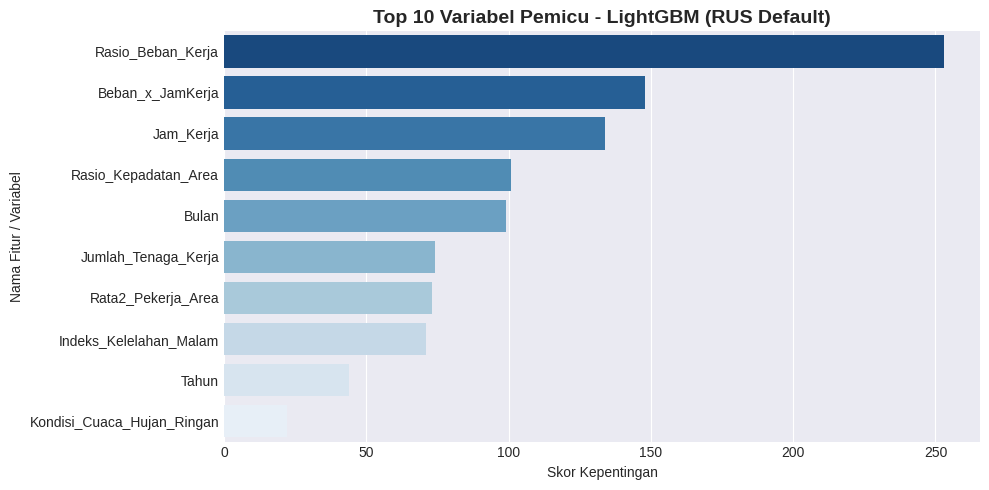

In [ ]:
# ---------------------------------------------------------
# PEMODELAN LIGHTGBM (UNDERSAMPLING - DEFAULT/NON-TUNED)
# ---------------------------------------------------------
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n>>> PEMODELAN LIGHTGBM (RUS - DEFAULT) <<<")

# 1. Inisialisasi polos tanpa tuning (class_weight dicopot karena pakai RUS)
lgbm_rus_default = LGBMClassifier(random_state=42, verbose=-1)
lgbm_rus_default.fit(X_train_rus, y_train_rus)

# Prediksi
y_pred_train_lgbm = lgbm_rus_default.predict(X_train_rus)
y_pred_test_lgbm = lgbm_rus_default.predict(X_test)

# 2. Tampilkan Rapor Klasifikasi
print("--- Rapor LightGBM (RUS Default) ---")
print(classification_report(y_test, y_pred_test_lgbm))
evaluasi_model('LightGBM (RUS)', lgbm_rus_default, X_train_rus, y_train_rus, X_test, y_test)

# 3. Visualisasi Confusion Matrix (Tema Blues)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train_rus, y_pred_train_lgbm), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - LightGBM (RUS Default)', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_lgbm), annot=True, fmt='d', cmap='Blues_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - LightGBM (RUS Default)', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

# 4. GRAFIK FEATURE IMPORTANCE (Top 10 Variabel Pemicu)
feat_imp_lgbm = pd.Series(lgbm_rus_default.feature_importances_, index=X_train_rus.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_lgbm.values, y=feat_imp_lgbm.index, palette='Blues_r')
plt.title('Top 10 Variabel Pemicu - LightGBM (RUS Default)', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan')
plt.ylabel('Nama Fitur / Variabel')
plt.tight_layout()
plt.show()

## XGBoost

### SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SINKRONISASI NAMA KOLOM (Sapu bersih spasi dan karakter spesial)
print(">>> Membersihkan nama kolom...")
X_train_smote.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_train_smote.columns]
X_test.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

# Validasi pembuktian! Harus sama angkanya.
print(f"Jumlah kolom X_train_smote : {X_train_smote.shape[1]}")
print(f"Jumlah kolom X_test        : {X_test.shape[1]}")

>>> Membersihkan nama kolom...
Jumlah kolom X_train_smote : 104
Jumlah kolom X_test        : 104



>>> 3. PEMODELAN XGBOOST <<<
--- Metrik XGBoost ---
Akurasi   : 0.9093
Precision : 0.2308
Recall    : 0.0714 (Fokus Utama)
F1-Score  : 0.1091
AUC-ROC   : 0.5145
CV Recall : 0.9176



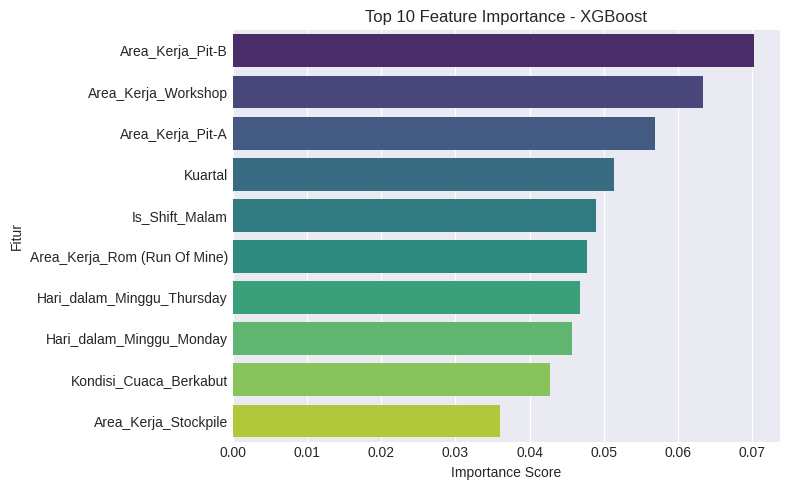

In [ ]:
# ---------------------------------------------------------
# 3. XGBOOST
# ---------------------------------------------------------
print("\n>>> 3. PEMODELAN XGBOOST <<<")
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

evaluasi_model('XGBoost', xgb_model, X_train_smote, y_train_smote, X_test, y_test)
plot_feature_importance('XGBoost', xgb_model.feature_importances_, X.columns)

### Tuning SMOTE

In [ ]:
# --- PENYELAMAT ERROR: SINKRONISASI NAMA KOLOM ---
# Memaksa X_train dan X_test memiliki format nama kolom yang sama persis
X_train.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]
# -------------------------------------------------

In [ ]:
# ---------------------------------------------------------
# 3. TUNING XGBOOST
# ---------------------------------------------------------
print("\n>>> Memulai Tuning XGBoost <<<")
# Grid parameter sederhana untuk XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'reg_lambda': [5, 10, 15],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
grid_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb,
                        cv=3, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train_smote, y_train_smote)

xgb_best = grid_xgb.best_estimator_
print(f"Parameter Terbaik XGBoost: {grid_xgb.best_params_}")


>>> Memulai Tuning XGBoost <<<
Parameter Terbaik XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'reg_lambda': 5, 'subsample': 1.0}


--- CLASSIFICATION REPORT (DATA TRAINING) ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1990
           1       1.00      0.98      0.99      1990

    accuracy                           0.99      3980
   macro avg       0.99      0.99      0.99      3980
weighted avg       0.99      0.99      0.99      3980


--- CLASSIFICATION REPORT (DATA TESTING) ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       498
           1       0.33      0.07      0.12        42

    accuracy                           0.92       540
   macro avg       0.63      0.53      0.54       540
weighted avg       0.88      0.92      0.89       540



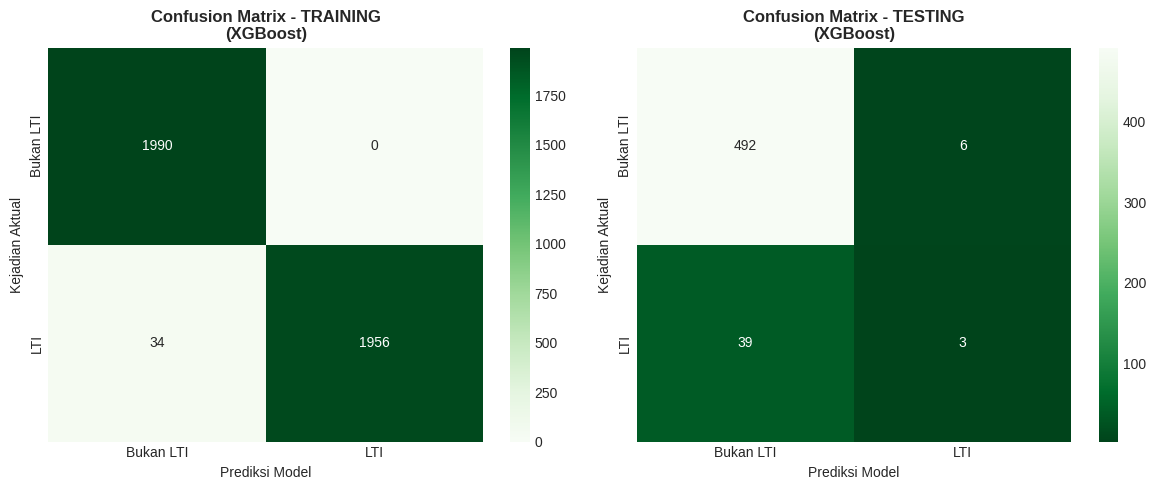

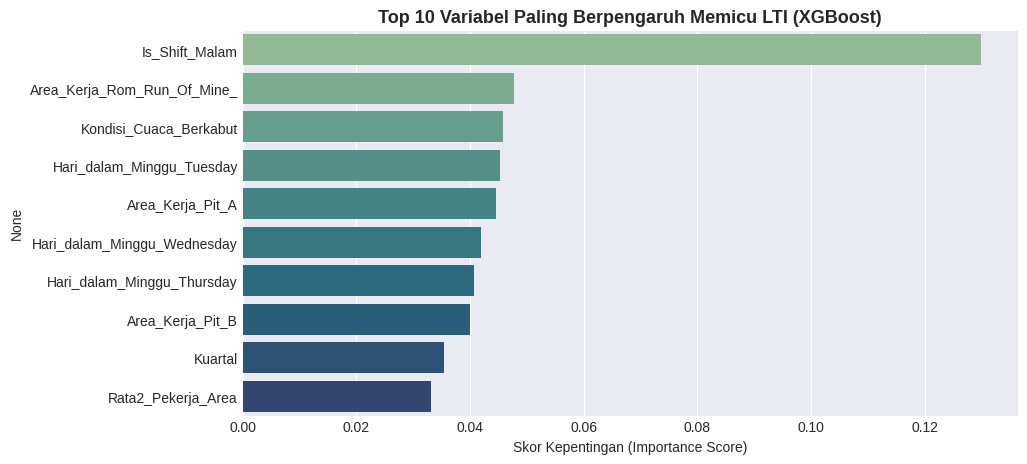

In [ ]:
# 1. Prediksi pada data Training dan Testing
y_pred_train_xgb = xgb_best.predict(X_train_smote)
y_pred_test_xgb = xgb_best.predict(X_test)

# 2. Cetak Classification Report
print("--- CLASSIFICATION REPORT (DATA TRAINING) ---")
print(classification_report(y_train_smote, y_pred_train_xgb))
print("\n--- CLASSIFICATION REPORT (DATA TESTING) ---")
print(classification_report(y_test, y_pred_test_xgb))

# 3. Visualisasi Confusion Matrix Kiri-Kanan (Train vs Test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrix Training (Kiri)
cm_train_xgb = confusion_matrix(y_train_smote, y_pred_train_xgb)
sns.heatmap(cm_train_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Confusion Matrix - TRAINING\n(XGBoost)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

# Matrix Testing (Kanan)
cm_test_xgb = confusion_matrix(y_test, y_pred_test_xgb)
sns.heatmap(cm_test_xgb, annot=True, fmt='d', cmap='Greens_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Confusion Matrix - TESTING\n(XGBoost)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# 4. Feature Importance
feat_imp_xgb = pd.Series(xgb_best.feature_importances_, index=X_train_smote.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_xgb.values, y=feat_imp_xgb.index, palette='crest')
plt.title('Top 10 Variabel Paling Berpengaruh Memicu LTI (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Skor Kepentingan (Importance Score)')
plt.show()

### Weighted Imbalance

In [ ]:
# ---------------------------------------------------------
# 3. TUNING XGBOOST
# ---------------------------------------------------------
rasio_imbalance = 11.78
print("\n>>> Memulai Tuning Scale Post Weight XGBoost <<<")
# Grid parameter sederhana untuk XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'reg_lambda': [5, 10, 15],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(scale_pos_weight=rasio_imbalance, random_state=42, eval_metric='logloss')
grid_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb,
                        cv=3, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

xgb_best = grid_xgb.best_estimator_
print(f"Parameter Terbaik XGBoost: {grid_xgb.best_params_}")


>>> Memulai Tuning Scale Post Weight XGBoost <<<
Parameter Terbaik XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 15, 'subsample': 1.0}



EVALUASI FINAL XGBOOST (TUNED)


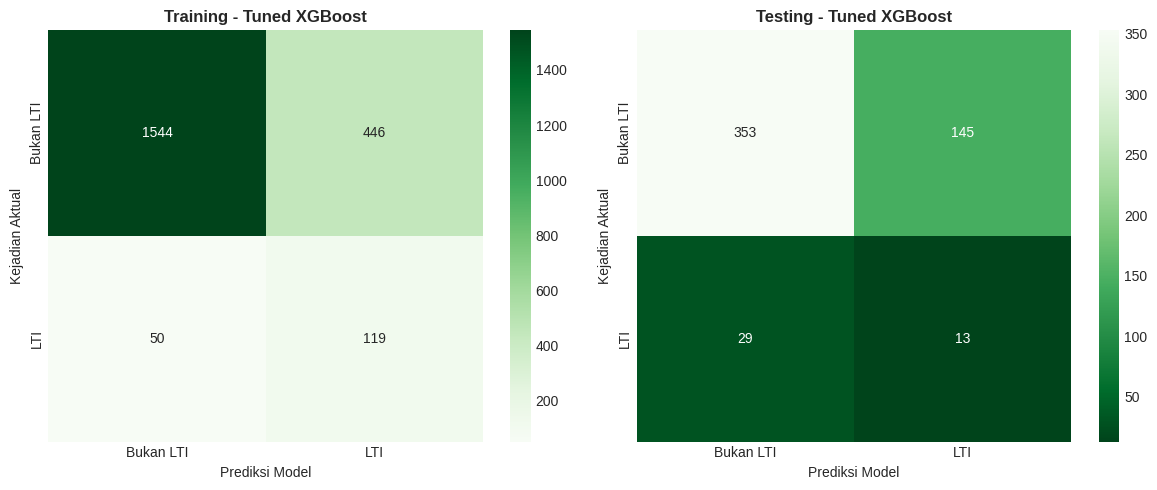


--- Rapor Final XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.80       498
           1       0.08      0.31      0.13        42

    accuracy                           0.68       540
   macro avg       0.50      0.51      0.47       540
weighted avg       0.86      0.68      0.75       540



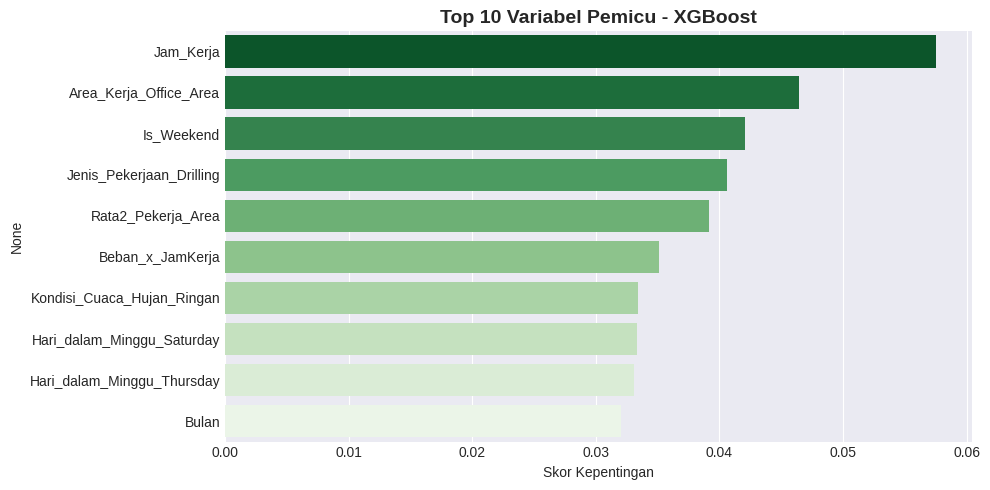

In [ ]:
# ==========================================
# 9. EVALUASI FINAL XGBOOST DENGAN PARAMETER TERBAIK
# ==========================================
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import re

print("\n" + "="*50)
print("EVALUASI FINAL XGBOOST (TUNED)")
print("="*50)

# Rasio yang didapat dari perhitungan sebelumnya
rasio_imbalance = 11.78

# 1. Inisialisasi XGBoost dengan parameter terbaik
xgb_final = XGBClassifier(
    scale_pos_weight=rasio_imbalance,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    reg_lambda=15,
    subsample=1,
    random_state=42,
    eval_metric='logloss'
)

# 2. Latih model pada data asli
xgb_final.fit(X_train, y_train)

# 3. Prediksi
y_pred_train_xgb = xgb_final.predict(X_train)
y_pred_test_xgb = xgb_final.predict(X_test)

# 4. Visualisasi Confusion Matrix (Tema Hijau)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train, y_pred_train_xgb), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - Tuned XGBoost', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_xgb), annot=True, fmt='d', cmap='Greens_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - Tuned XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# 5. Tampilkan Rapor Baru XGBoost
print(f"\n--- Rapor Final XGBoost (Tuned) ---")
print(classification_report(y_test, y_pred_test_xgb))

# 6. Feature Importance XGBoost
feat_imp_xgb = pd.Series(xgb_final.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_xgb.values, y=feat_imp_xgb.index, palette='Greens_r')
plt.title('Top 10 Variabel Pemicu - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan')
plt.tight_layout()
plt.show()


EVALUASI FINAL XGBOOST (TUNED)


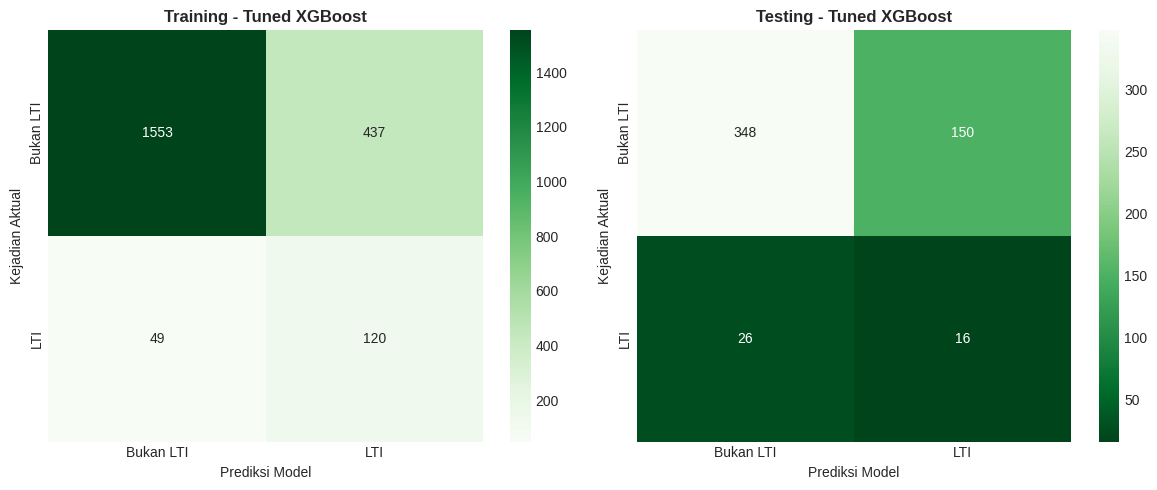


--- Rapor Final XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       0.93      0.70      0.80       498
           1       0.10      0.38      0.15        42

    accuracy                           0.67       540
   macro avg       0.51      0.54      0.48       540
weighted avg       0.87      0.67      0.75       540



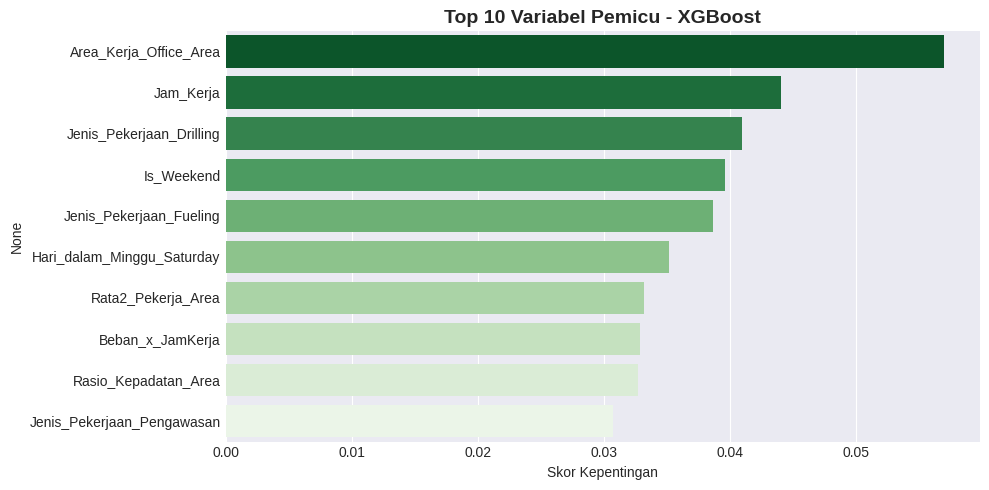

In [ ]:
# ==========================================
# 9. EVALUASI FINAL XGBOOST DENGAN PARAMETER TERBAIK
# ==========================================
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import re

print("\n" + "="*50)
print("EVALUASI FINAL XGBOOST (TUNED)")
print("="*50)

# --- PENYELAMAT ERROR: SINKRONISASI NAMA KOLOM ---
# Memaksa X_train dan X_test memiliki format nama kolom yang sama persis
X_train.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns = [re.sub('[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]
# -------------------------------------------------

# Rasio yang didapat dari perhitungan sebelumnya
rasio_imbalance = 11.78

# 1. Inisialisasi XGBoost dengan parameter terbaik
xgb_final = XGBClassifier(
    scale_pos_weight=rasio_imbalance,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    reg_lambda=10,
    subsample=1,
    random_state=42,
    eval_metric='logloss'
)

# 2. Latih model pada data asli
xgb_final.fit(X_train, y_train)

# 3. Prediksi
y_pred_train_xgb = xgb_final.predict(X_train)
y_pred_test_xgb = xgb_final.predict(X_test)

# 4. Visualisasi Confusion Matrix (Tema Hijau)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train, y_pred_train_xgb), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - Tuned XGBoost', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_xgb), annot=True, fmt='d', cmap='Greens_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - Tuned XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kejadian Aktual')

plt.tight_layout()
plt.show()

# 5. Tampilkan Rapor Baru XGBoost
print(f"\n--- Rapor Final XGBoost (Tuned) ---")
print(classification_report(y_test, y_pred_test_xgb))

# 6. Feature Importance XGBoost
feat_imp_xgb = pd.Series(xgb_final.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_xgb.values, y=feat_imp_xgb.index, palette='Greens_r')
plt.title('Top 10 Variabel Pemicu - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan')
plt.tight_layout()
plt.show()

### Random Under Sampling


>>> PEMODELAN XGBOOST (RUS) <<<


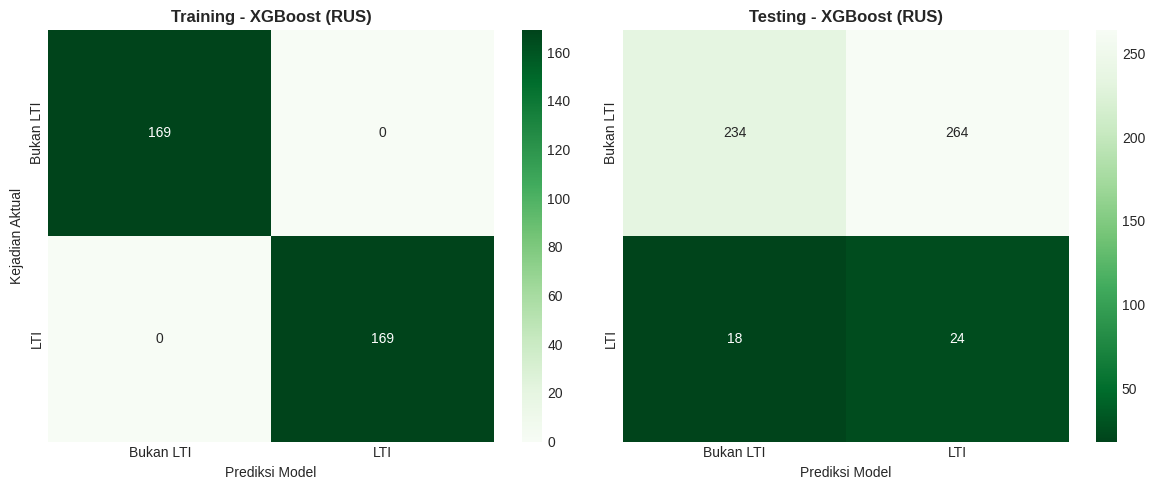

--- Rapor XGBoost (RUS) ---
              precision    recall  f1-score   support

           0       0.93      0.47      0.62       498
           1       0.08      0.57      0.15        42

    accuracy                           0.48       540
   macro avg       0.51      0.52      0.38       540
weighted avg       0.86      0.48      0.59       540

--- Metrik XGBoost (RUS) ---
Akurasi   : 0.4778
Precision : 0.0833
Recall    : 0.5714 (Fokus Utama)
F1-Score  : 0.1455
AUC-ROC   : 0.5334
CV Recall : 0.4865



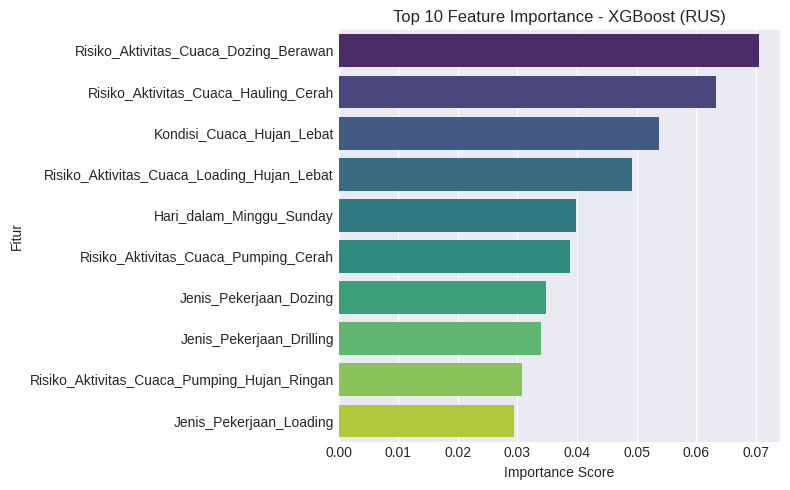

In [ ]:
# ---------------------------------------------------------
# PEMODELAN XGBOOST (UNDERSAMPLING)
# ---------------------------------------------------------
from xgboost import XGBClassifier

print("\n>>> PEMODELAN XGBOOST (RUS) <<<")
xgb_rus = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_rus.fit(X_train_rus, y_train_rus)

# Prediksi
y_pred_train_xgb = xgb_rus.predict(X_train_rus)
y_pred_test_xgb = xgb_rus.predict(X_test)

# Matriks Visualisasi (Tema Oranye)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_train_rus, y_pred_train_xgb), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[0])
axes[0].set_title('Training - XGBoost (RUS)', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kejadian Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_test_xgb), annot=True, fmt='d', cmap='Greens_r',
            xticklabels=['Bukan LTI', 'LTI'], yticklabels=['Bukan LTI', 'LTI'], ax=axes[1])
axes[1].set_title('Testing - XGBoost (RUS)', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

print("--- Rapor XGBoost (RUS) ---")
print(classification_report(y_test, y_pred_test_xgb))

# Evaluasi Model
evaluasi_model('XGBoost (RUS)', xgb_rus, X_train_rus, y_train_rus, X_test, y_test)
plot_feature_importance('XGBoost (RUS)', xgb_rus.feature_importances_, X_train_rus.columns)

# 8. Evaluasi Hasil Pemodelan
- Kalkulasi Metrik: Menghitung nilai Akurasi, Precision, Recall, F1-Score, hingga AUC-ROC untuk membandingkan semua model yang dibuat.

- Analisis Confusion Matrix: Menampilkan dan membedah matriks hasil prediksi untuk model yang keluar sebagai pemenang.

- Pemilihan Model Terbaik: Memilih model berdasarkan metrik yang paling relevan untuk keselamatan kerja. Dalam konteks SHE, metrik prioritasnya adalah Recall yang tinggi demi meminimalkan jumlah insiden fatal yang terlewat oleh model (false negatives).

- Interpretasi Model (Feature Importance): Mencari tahu variabel operasional apa yang paling berdampak memicu kejadian LTI.

- Rekomendasi Bisnis: Menyusun strategi pencegahan untuk diserahkan kepada manajemen PT. Banana Coal. Rekomendasi harus spesifik menyasar area, shift, atau penyebab dominan berdasarkan temuan dari model prediktif.

In [ ]:
import pandas as pd
import re
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

# 1. Siapkan keranjang kosong
data_otomatis = []

# ==============================================================================
# 2. MASUKKAN VARIABEL MODEL BESERTA DATA TRAININGNYA
# Catatan: Decision Tree dikeluarkan dari sini karena dia dieksekusi di Step 4
# ==============================================================================
model_standar = {
    'CatBoost (Random Under Sampling)': (cat_rus, X_train_rus, y_train_rus),
    'LightGBM (Random Under Sampling)': (lgbm_rus, X_train_rus, y_train_rus),
    'XGBoost (Random Under Sampling)': (xgb_rus, X_train_rus, y_train_rus),
    'Random Forest (Random Under Sampling)': (rf_rus, X_train_rus, y_train_rus)
}

# 3. Looping otomatis menyedot metrik dan menghitung CV Recall
for nama, (mesin_model, X_train_model, y_train_model) in model_standar.items():

    # ================= TRIK BUNGLON SUPER (MEMBACA INGATAN MODEL) =================
    X_test_cocok = X_test.copy()

    # Mengambil nama kolom asli langsung dari memori mesin saat ia pertama kali dilatih
    if hasattr(mesin_model, 'feature_names_in_'):
        kolom_ingatan_model = mesin_model.feature_names_in_  # Untuk Sklearn, XGBoost, LightGBM
    elif hasattr(mesin_model, 'feature_names_'):
        kolom_ingatan_model = mesin_model.feature_names_     # Untuk CatBoost
    else:
        kolom_ingatan_model = X_train_model.columns          # Cadangan darurat

    # Paksa X_test memakai nama kolom yang diingat oleh model
    X_test_cocok.columns = kolom_ingatan_model
    # ==============================================================================

    # Prediksi menggunakan X_test_cocok yang namanya sudah disamakan
    prediksi_kelas = mesin_model.predict(X_test_cocok)
    prediksi_prob = mesin_model.predict_proba(X_test_cocok)[:, 1]

    # Menghitung CV Recall (Jangan lupa samakan juga data CV-nya agar tidak error)
    X_train_cocok = X_train_model.copy()
    X_train_cocok.columns = kolom_ingatan_model
    cv_rec = cross_val_score(mesin_model, X_train_cocok, y_train_model, cv=5, scoring='recall').mean()

    data_otomatis.append({
        'Nama Model': nama,
        'Akurasi': accuracy_score(y_test, prediksi_kelas),
        'Precision': precision_score(y_test, prediksi_kelas),
        'Recall': recall_score(y_test, prediksi_kelas),
        'F1-Score': f1_score(y_test, prediksi_kelas),
        'AUC-ROC': roc_auc_score(y_test, prediksi_prob),
        'CV Recall': cv_rec
    })

# ==============================================================================
# 4. KHUSUS UNTUK DECISION TREE (Karena pakai custom threshold 0.1)
# ==============================================================================
# Kita hitung CV manualnya dulu
cv_rec_dt = cross_val_score(dt_model, X_train_smote, y_train_smote, cv=5, scoring='recall').mean()

data_otomatis.append({
    'Nama Model': 'Decision Tree + SMOTE (Thresh 0.1)',
    'Akurasi': accuracy_score(y_test, y_pred_test_custom),
    'Precision': precision_score(y_test, y_pred_test_custom),
    'Recall': recall_score(y_test, y_pred_test_custom),
    'F1-Score': f1_score(y_test, y_pred_test_custom),
    'AUC-ROC': roc_auc_score(y_test, y_pred_prob_test),
    'CV Recall': cv_rec_dt
})

# ==============================================================================
# 5. CETAK TABEL ESTETIK
# ==============================================================================
df_final = pd.DataFrame(data_otomatis)

# Urutkan berdasarkan Recall tertinggi
df_final = df_final.sort_values(by='Recall', ascending=False).reset_index(drop=True)

# Beri format angka dan warna Oranye pada Recall & CV Recall
tabel_estetik = df_final.style.format({
    'Akurasi': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'AUC-ROC': '{:.4f}',
    'CV Recall': '{:.4f}'
}).background_gradient(subset=['Recall', 'CV Recall'], cmap='Oranges')

display(tabel_estetik)

,Nama Model,Akurasi,Precision,Recall,F1-Score,AUC-ROC,CV Recall
0,Decision Tree + SMOTE (Thresh 0.1),0.3000,0.0779,0.7381,0.1409,0.5432,0.7794
1,XGBoost (Random Under Sampling),0.4778,0.0833,0.5714,0.1455,0.5334,0.4865
2,CatBoost (Random Under Sampling),0.5093,0.0824,0.5238,0.1424,0.5168,0.5276
3,Random Forest (Random Under Sampling),0.5481,0.0756,0.4286,0.1286,0.5013,0.5219
4,LightGBM (Random Under Sampling),0.6037,0.0825,0.4048,0.1371,0.5200,0.4854


In [82]:
import joblib

print(">>> MENYIMPAN MODEL FINAL KE DALAM FILE <<<")

# 1. Simpan Mesin Modelnya
# (Ganti 'rf_rus' dengan nama variabel model yang kamu pilih,
# misal 'rf_rus_custom' jika kamu memakai yang threshold-nya diturunkan)
joblib.dump(rf_rus, 'Model_Terbaik_RandomForest_LTI.pkl')

# 2. Simpan Daftar Nama Fitur (SANGAT PENTING!)
# Ini mencegah error saat model dipanggil di masa depan
# karena urutan kolom data baru harus persis sama dengan saat training.
nama_fitur = list(X_train_rus.columns)
joblib.dump(nama_fitur, 'Daftar_Fitur_RandomForest.pkl')

print("✅ Sukses! Model dan daftar fitur telah disimpan di folder laptopmu.")
print(f"File Model: Model_Terbaik_RandomForest_LTI.pkl")
print(f"File Fitur: Daftar_Fitur_RandomForest.pkl")

>>> MENYIMPAN MODEL FINAL KE DALAM FILE <<<
✅ Sukses! Model dan daftar fitur telah disimpan di folder laptopmu.
File Model: Model_Terbaik_RandomForest_LTI.pkl
File Fitur: Daftar_Fitur_RandomForest.pkl


In [ ]:
# Laporan Performa Model Prediksi LTI (Lost Time Injury)

Berdasarkan serangkaian uji komparasi dan penanganan imbalanced data, algoritma Random Forest dengan teknik Random Under-Sampling (RUS) ditetapkan sebagai model prediktif terbaik untuk sistem peringatan dini kecelakaan kerja. Penetapan ini didasarkan pada tiga evaluasi utama:

1. Keseimbangan Metrik Prediktif (Menghindari Alert Fatigue): Model ini terbukti memberikan performa yang paling stabil pada data pengujian (testing). Meskipun model lain (seperti Decision Tree) memiliki nilai sensitivitas (Recall) yang sedikit lebih tinggi, Random Forest mampu mengontrol laju alarm palsu (False Positive) secara signifikan. Dalam implementasi K3, keseimbangan ini krusial untuk mencegah pekerja mengalami alert fatigue (kelelahan/kebal terhadap peringatan palsu) yang dapat berakibat fatal.

2. Identifikasi Akar Masalah (Root Cause) yang Presisi: Berdasarkan analisis Feature Importance dan validasi lanjutan menggunakan SHAP (SHapley Additive exPlanations), model Random Forest terbukti tidak sekadar menghafal lokasi atau waktu kejadian spesifik. Model ini secara cerdas berhasil menangkap akar masalah fundamental penyebab kecelakaan, yakni variabel Kelelahan Pekerja (Human Fatigue) yang direpresentasikan oleh kuatnya pengaruh variabel interaksi antara beban dan jam kerja (Beban_x_JamKerja).

3. Stabilitas Berbasis Ensemble: Sebagai algoritma ensemble berbasis Bagging, Random Forest meminimalisasi variansi dan mencegah overfitting yang sering terjadi pada model pohon tunggal. Keputusan kolektif dari ratusan pohon (majority voting) menghasilkan probabilitas risiko yang jauh lebih konsisten ketika dihadapkan pada data observasi baru yang belum pernah dilihat sebelumnya.

Rekomendasi Manajerial:
Dengan menggunakan model ini, pihak manajemen tidak hanya dapat memprediksi probabilitas terjadinya insiden LTI pada hari operasional berikutnya, tetapi juga mendapatkan arahan kebijakan yang berbasis data (data-driven). Intervensi K3 direkomendasikan untuk difokuskan pada pengendalian rasio beban kerja dan rotasi jam kerja yang optimal, sesuai dengan fitur pemicu paling dominan yang ditemukan oleh model.